In [1]:
"""
created by Alessandro Ianiro 01.09.2022
modified by Aleksander A. Rebane 10.06.2026
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root, brentq

from datetime import datetime
from tqdm import tqdm
import pickle

from gfvt import PD

# Get the current date
today = datetime.now()

# Format the date as "YYMMDD"
date_string = today.strftime("%y%m%d")

%matplotlib inline

mbsa = 66.4
mpeg100 = 100
mpeg20 = 20
mpeg35 = 35
mpeg8 = 8
mpeg6 = 6
mpeg4 = 4
mpeg48_wt = 5.3

mpegQ8 = (8/(14.8/3))**(1/0.6379)*mpeg100
mpegQ10 = (10/(14.8/3))**(1/0.6379)*mpeg100
mpegQ16 = (16/(14.8/3))**(1/0.6379)*mpeg100

rbsa = 3.0e-9

rpeg4K = 1.9e-9
rpeg6K = 2.45e-9
rpeg8K = 3.1e-9
rpeg20K = 5.4e-9
rpeg35K = 7.8e-9
rpeg100K = 14.8e-9
rpegQ8 = 24e-9
rpegQ10 = 32e-9
rpegQ16 = 48e-9

Nav = 6.022e23 # avogadro

# Load data

In [30]:
data_4K_pH7_200mM_MA3 = np.loadtxt('../data/PEG_4K_BSA_Data.csv', delimiter=',')
data_6K_pH7_200mM_SD = np.loadtxt('../data/PEG_6K_BSA_Data.csv', delimiter=',')
data_8K_pH7_200mM_SD = np.loadtxt('../data/PEG_8K_BSA_Data.csv', delimiter=',')
data_20K_pH7_200mM = np.loadtxt('../data/PEG_20K_BSA_Data.csv', delimiter=',')
data_35K_pH7_200mM = np.loadtxt('../data/PEG_35K_BSA_Data.csv', delimiter=',')
data_100K_pH7_200mM = np.loadtxt('../data/PEG_100K_BSA_Data.csv', delimiter=',')

data_2K8K_pH7_200mM_n_MW = np.loadtxt('../data/PEG_8K_2K_Mn6K_BSA_Data.csv', delimiter=',')
data_2K8K_pH7_200mM_n_MW8K = np.loadtxt('../data/PEG_8K_2K_8Konly_BSA_Data.csv', delimiter=',')
data_2K35K_pH7_200mM_n = np.loadtxt('../data/PEG_35K_2K_Mn6K_BSA_Data.csv', delimiter=',')
data_2K35K_pH7_200mM_35only = np.loadtxt('../data/PEG_35K_2K_35Konly_BSA_Data.csv', delimiter=',')

data_35K_GFP = np.loadtxt('../data/PEG_35K_GFP_Data.csv', delimiter=',')
data_20K_GFP = np.loadtxt('../data/PEG_20K_GFP_Data.csv', delimiter=',')

data_35K_SUMO = np.loadtxt('../data/PEG_35K_SUMO_Data.csv', delimiter=',')
data_20K_SUMO = np.loadtxt('../data/PEG_20K_SUMO_Data.csv', delimiter=',')

data_35K_MBP = np.loadtxt('../data/PEG_35K_MBP_Data.csv', delimiter=',')
data_20K_MBP = np.loadtxt('../data/PEG_20K_MBP_Data.csv', delimiter=',')


# Pickle

## Load pickled variables

In [31]:
# Load the saved variables

with open('../pickles/260621_output.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access objects
BSA_PEG_4K = loaded_variables['BSA_PEG_4K']
BSA_PEG_6K = loaded_variables['BSA_PEG_6K']
BSA_PEG_8K = loaded_variables['BSA_PEG_8K']
BSA_PEG_20K = loaded_variables['BSA_PEG_20K']
BSA_PEG_35K = loaded_variables['BSA_PEG_35K']
BSA_PEG_100K = loaded_variables['BSA_PEG_100K']
BSA_PEG_6p7K = loaded_variables['BSA_PEG_6p7K']
BSA_PEG_7p3K = loaded_variables['BSA_PEG_7p3K']
BSA_PEG_25K = loaded_variables['BSA_PEG_25K']
BSA_PEG_Q8 = loaded_variables['BSA_PEG_Q8']
BSA_PEG_Q10 = loaded_variables['BSA_PEG_Q10']
BSA_PEG_Q16 = loaded_variables['BSA_PEG_Q16']
BSA_PEG_4K_full = loaded_variables['BSA_PEG_4K_full']
BSA_PEG_6K_full = loaded_variables['BSA_PEG_6K_full']
BSA_PEG_8K_full = loaded_variables['BSA_PEG_8K_full']
BSA_PEG_20K_full = loaded_variables['BSA_PEG_20K_full']
BSA_PEG_35K_full = loaded_variables['BSA_PEG_35K_full']
BSA_PEG_100K_full = loaded_variables['BSA_PEG_100K_full']
BSA_PEG_6p7K_full = loaded_variables['BSA_PEG_6p7K_full']
BSA_PEG_7p3K_full = loaded_variables['BSA_PEG_7p3K_full']
BSA_PEG_25K_full = loaded_variables['BSA_PEG_25K_full']
BSA_PEG_Q8_full = loaded_variables['BSA_PEG_Q8_full']
BSA_PEG_Q10_full = loaded_variables['BSA_PEG_Q10_full']
BSA_PEG_Q16_full = loaded_variables['BSA_PEG_Q16_full']
GFP_PEG_20K_real = loaded_variables['GFP_PEG_20K_real']
GFP_PEG_35K_real = loaded_variables['GFP_PEG_35K_real']
GFP_PEG_100K_real = loaded_variables['GFP_PEG_100K_real']
GFP_PEG_20K = loaded_variables['GFP_PEG_20K']
GFP_PEG_35K = loaded_variables['GFP_PEG_35K']
GFP_PEG_100K = loaded_variables['GFP_PEG_100K']
GFP_PEG_Q16 = loaded_variables['GFP_PEG_Q16']
SUMO_PEG_20K = loaded_variables['SUMO_PEG_20K']
SUMO_PEG_35K = loaded_variables['SUMO_PEG_35K']
MBP_PEG_20K = loaded_variables['MBP_PEG_20K']
MBP_PEG_35K = loaded_variables['MBP_PEG_35K']

# Convert legacy GFVT lists from older pickles into PD objects for plotting.
# BSA_PEG_4K = PD.from_legacy_list(gfvt4K_200mM_Z0)

## Save variable into pickle

In [22]:
# Create a dictionary with the variables you want to save
variables_to_save = {
    'BSA_PEG_4K': BSA_PEG_4K,
    'BSA_PEG_6K': BSA_PEG_6K,
    'BSA_PEG_8K': BSA_PEG_8K,
    'BSA_PEG_20K': BSA_PEG_20K,
    'BSA_PEG_35K': BSA_PEG_35K,
    'BSA_PEG_100K': BSA_PEG_100K,
    'BSA_PEG_6p7K' : BSA_PEG_6p7K,
    'BSA_PEG_7p3K' : BSA_PEG_7p3K,
    'BSA_PEG_25K' : BSA_PEG_25K,
    'BSA_PEG_Q8' : BSA_PEG_Q8,
    'BSA_PEG_Q10' : BSA_PEG_Q10,
    'BSA_PEG_Q16' : BSA_PEG_Q16,
    'BSA_PEG_4K_full': BSA_PEG_4K_full,
    'BSA_PEG_6K_full': BSA_PEG_6K_full,
    'BSA_PEG_8K_full': BSA_PEG_8K_full,
    'BSA_PEG_20K_full': BSA_PEG_20K_full,
    'BSA_PEG_35K_full': BSA_PEG_35K_full,
    'BSA_PEG_100K_full': BSA_PEG_100K_full,
    'BSA_PEG_6p7K_full' : BSA_PEG_6p7K_full,
    'BSA_PEG_7p3K_full' : BSA_PEG_7p3K_full,
    'BSA_PEG_25K_full' : BSA_PEG_25K_full,
    'BSA_PEG_Q8_full' : BSA_PEG_Q8_full,
    'BSA_PEG_Q10_full' : BSA_PEG_Q10_full,
    'BSA_PEG_Q16_full' : BSA_PEG_Q16_full,
    'GFP_PEG_20K_real' : GFP_PEG_20K_real,
    'GFP_PEG_35K_real' : GFP_PEG_35K_real,
    'GFP_PEG_100K_real' : GFP_PEG_100K_real,
    'GFP_PEG_20K' : GFP_PEG_20K,
    'GFP_PEG_35K' : GFP_PEG_35K,
    'GFP_PEG_100K' : GFP_PEG_100K,
    'GFP_PEG_Q16' : GFP_PEG_Q16,
    'SUMO_PEG_20K' : SUMO_PEG_20K,
    'SUMO_PEG_35K' : SUMO_PEG_35K,
    'MBP_PEG_20K' : MBP_PEG_20K,
    'MBP_PEG_35K' : MBP_PEG_35K
}

# Save to a file
with open('../pickles/' + date_string + '_output.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)

print(f'Variables saved to ../pickles/{date_string}_output.pkl')

Variables saved to ../pickles/260621_output.pkl


# GFVT Calculations

## GVFT calculations

q = 0.63, Rbsa = 3.00 nm, Rp = 1.90 nm
BSA_crit = 0.2348, PEG_crit = 0.6382
[BSA]_crit = 3.45 mM, [PEG]_crit = 16.56 mM

BSA_tp_G = 0.0309, BSA_tp_L = 0.4611, BSA_tp_S = 0.5662, PEG_tp = 0.9063
[BSA]_tp_G = 0.45 mM, [BSA]_tp_L = 6.77 mM, [BSA]_tp_S = 8.31 mM, [PEG]_tp_G = 48.82 mM, [PEG]_tp_L = 6.67 mM, [PEG]_tp_S = 1.70 mM



Calculating Binodal: 100%|██████████| 2000/2000 [00:33<00:00, 58.95step/s]


q = 0.82, Rbsa = 3.00 nm, Rp = 2.45 nm
BSA_crit = 0.1987, PEG_crit = 0.8031
[BSA]_crit = 2.92 mM, [PEG]_crit = 10.59 mM

BSA_tp_G = 0.0125, BSA_tp_L = 0.4663, BSA_tp_S = 0.5634, PEG_tp = 1.3551
[BSA]_tp_G = 0.18 mM, [BSA]_tp_L = 6.85 mM, [BSA]_tp_S = 8.27 mM, [PEG]_tp_G = 35.52 mM, [PEG]_tp_L = 4.42 mM, [PEG]_tp_S = 1.24 mM



Calculating Binodal: 100%|██████████| 2000/2000 [00:38<00:00, 51.64step/s]


q = 1.03, Rbsa = 3.00 nm, Rp = 3.10 nm
BSA_crit = 0.1695, PEG_crit = 1.0143
[BSA]_crit = 2.49 mM, [PEG]_crit = 7.15 mM

BSA_tp_G = 0.0068, BSA_tp_L = 0.4670, BSA_tp_S = 0.5634, PEG_tp = 1.9402
[BSA]_tp_G = 0.10 mM, [BSA]_tp_L = 6.86 mM, [BSA]_tp_S = 8.27 mM, [PEG]_tp_G = 25.43 mM, [PEG]_tp_L = 3.18 mM, [PEG]_tp_S = 0.92 mM



...

q = 10.67, Rbsa = 3.00 nm, Rp = 32.00 nm
BSA_crit = 0.1182, PEG_crit = 24.8775
[BSA]_crit = 1.74 mM, [PEG]_crit = 0.20 mM

BSA_tp_G = 0.0024, BSA_tp_L = 0.4621, BSA_tp_S = 0.5677, PEG_tp = 45.6418
[BSA]_tp_G = 0.03 mM, [BSA]_tp_L = 6.78 mM, [BSA]_tp_S = 8.33 mM, [PEG]_tp_G = 0.55 mM, [PEG]_tp_L = 0.08 mM, [PEG]_tp_S = 0.02 mM



Calculating Binodal: 100%|██████████| 2000/2000 [10:52<00:00,  3.07step/s]


q = 16.00, Rbsa = 3.00 nm, Rp = 48.00 nm
BSA_crit = 0.1195, PEG_crit = 42.4572
[BSA]_crit = 1.75 mM, [PEG]_crit = 0.10 mM

BSA_tp_G = 0.0025, BSA_tp_L = 0.4619, BSA_tp_S = 0.5678, PEG_tp = 77.3901
[BSA]_tp_G = 0.04 mM, [BSA]_tp_L = 6.78 mM, [BSA]_tp_S = 8.34 mM, [PEG]_tp_G = 0.28 mM, [PEG]_tp_L = 0.04 mM, [PEG]_tp_S = 0.01 mM



Calculating Binodal: 100%|██████████| 2000/2000 [17:53<00:00,  1.86step/s]


NameError: name 'BSA_PEG_Q8' is not defined

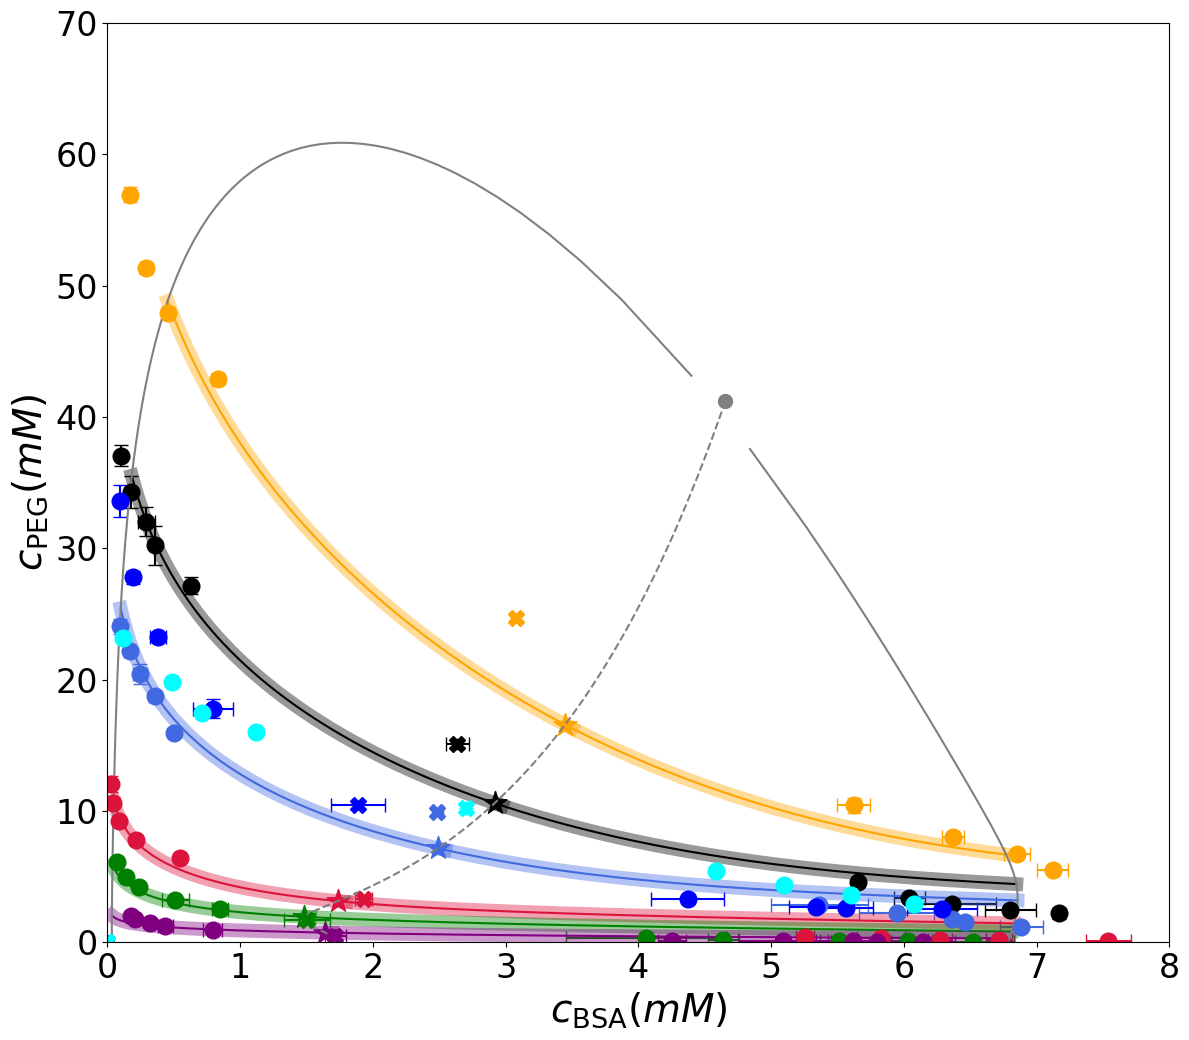

In [8]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

N_steps = 2000 # number of points between PhiP_max and PhiP_min 

solvent = 'good'

guess_c = [0.24, 0.7];

# BSA_PEG_4K = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_6K = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_8K = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_20K = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_35K = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_100K = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# BSA_PEG_Q8 = PD(3.0e-9, 24e-9, mbsa, mpegQ8, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_Q10 = PD(3.0e-9, 32e-9, mbsa, mpegQ10, solvent, N_steps, guess_c).GFVT()

BSA_PEG_6p7K = PD(3.0e-9, 2.68e-9, mbsa, 6.7, solvent, N_steps, guess_c).GFVT()
BSA_PEG_7p3K = PD(3.0e-9, 2.83e-9, mbsa, 7.3, solvent, N_steps, guess_c).GFVT()
BSA_PEG_25K = PD(3.0e-9, 6.2e-9, mbsa, 25, solvent, N_steps, guess_c).GFVT()

BSA_PEG_4K_full = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_6K_full = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_8K_full = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c).GFVT_full(PhiP_max=4)
BSA_PEG_20K_full = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c).GFVT_full(PhiP_max=6)
BSA_PEG_35K_full = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c).GFVT_full(PhiP_max=10)
BSA_PEG_100K_full = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c).GFVT_full(PhiP_max=30)
BSA_PEG_Q8_full = PD(3.0e-9, 24e-9, mbsa, mpegQ8, solvent, N_steps, guess_c).GFVT_full(PhiP_max=50)
BSA_PEG_Q10_full = PD(3.0e-9, 32e-9, mbsa, mpegQ10, solvent, N_steps, guess_c).GFVT_full(PhiP_max=60)

BSA_PEG_7p3K_full = PD(3.0e-9, 2.83e-9, mbsa, 7.3, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_25K_full = PD(3.0e-9, 6.2e-9, mbsa, 25, solvent, N_steps, guess_c).GFVT_full(PhiP_max=6)

guess_c = [0.1, 50]
# BSA_PEG_Q16 = PD(3.0e-9, 48e-9, mbsa, mpegQ16, solvent, N_steps, guess_c).GFVT()
BSA_PEG_Q16_full = PD(3.0e-9, 48e-9, mbsa, mpegQ16, solvent, N_steps, guess_c).GFVT_full(PhiP_max=120)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'blue', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW,'2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa,  8.57, False)


BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'orange')
BSA_PEG_6K.molplot('6K, pH 7, 200 mM KCl, ', 'black')
BSA_PEG_8K.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot('20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot('35K, pH 7, 200 mM KCl, ', 'green')
BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='gray')
BSA_PEG_Q8.molplot('Q8, ', 'red')
BSA_PEG_Q10.molplot('Q10, ', 'magenta')
BSA_PEG_Q16.molplot('Q16, ', 'cyan')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

## molplot_phi

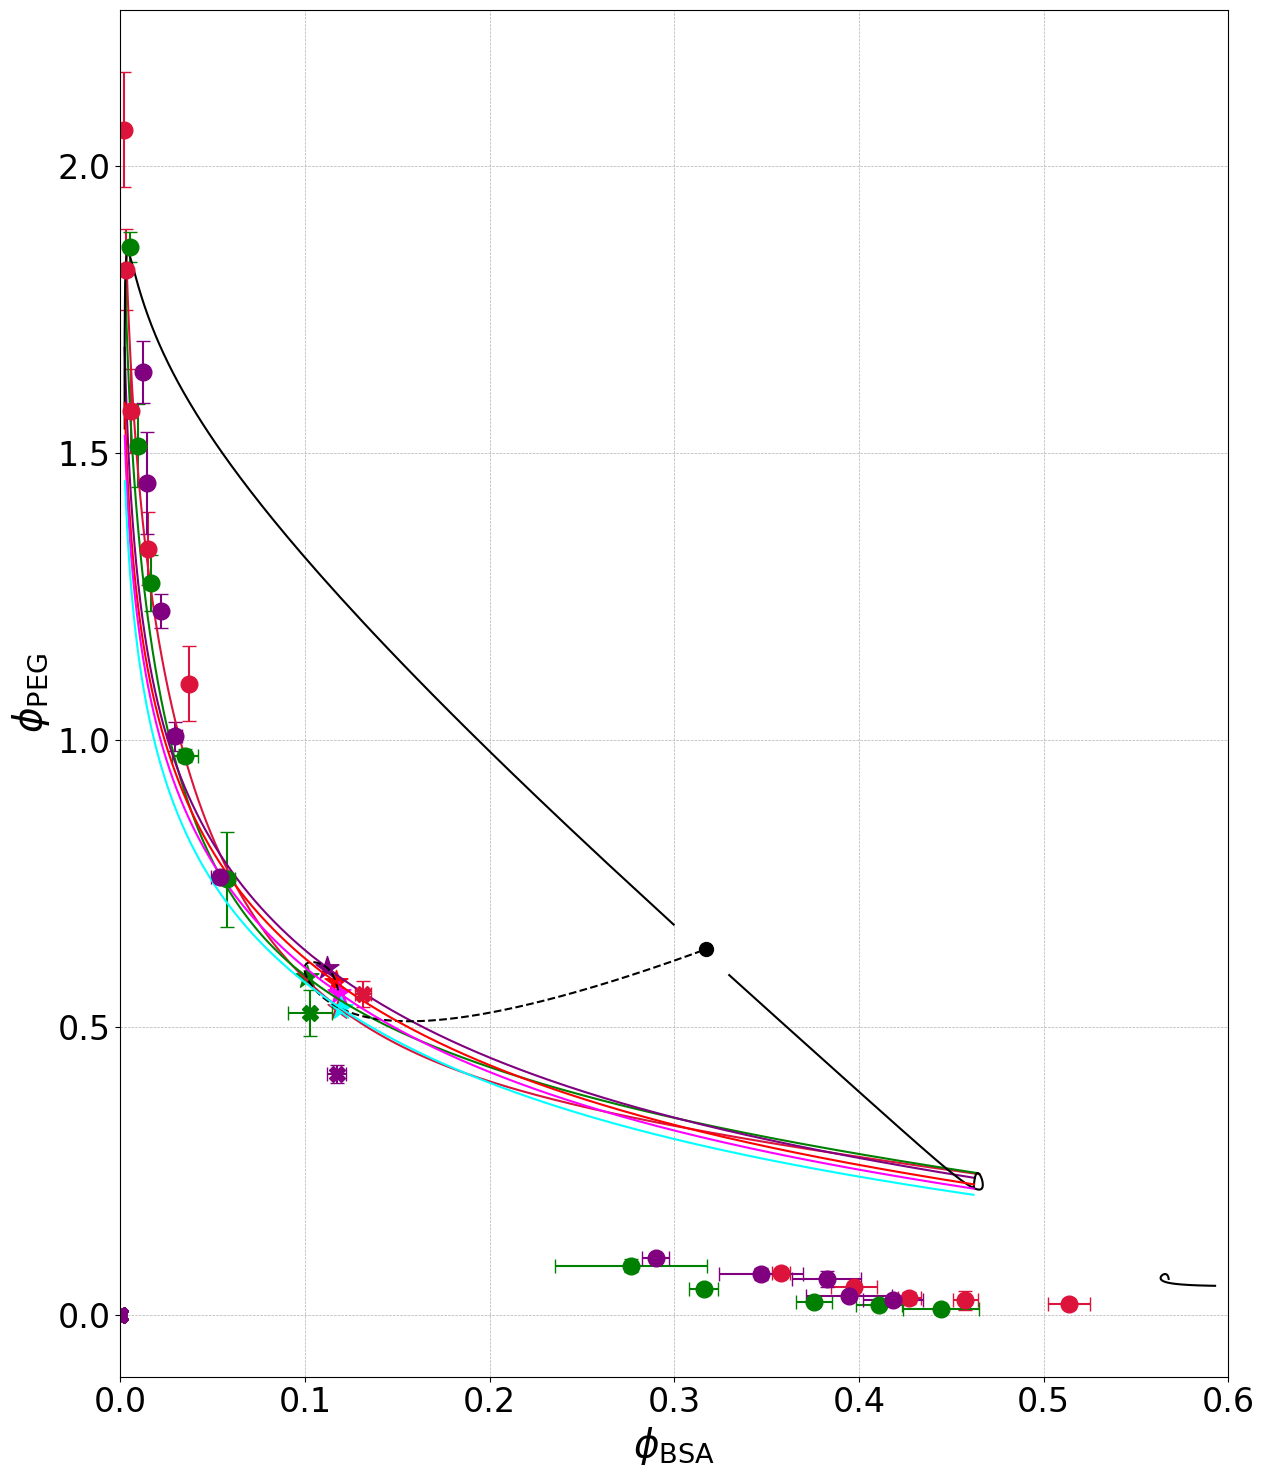

In [4]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.6)
# plt.ylim(0,2.5)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

# molplot_phi(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange')
# molplot_phi(gfvt6K_200mM_Z0, f'6K, pH 7, 200 mM KCl, ', 'black')
# molplot_phi(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot_phi(f'20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot_phi(f'35K, pH 7, 200 mM KCl, ', 'green')
BSA_PEG_100K.molplot_phi(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')

BSA_PEG_Q8.molplot_phi(f'Q=8, pH 7, 200 mM KCl, ', 'red')
BSA_PEG_Q10.molplot_phi(f'Q=10, pH 7, 200 mM KCl, ', 'magenta')
BSA_PEG_Q16.molplot_phi(f'Q=16, pH 7, 200 mM KCl, ', 'cyan')
plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_phiR

<Axes: xlabel='$\\phi_\\mathrm{BSA}$', ylabel='$q_R^{-1/\\gamma}\\phi^R_\\mathrm{PEG}$'>

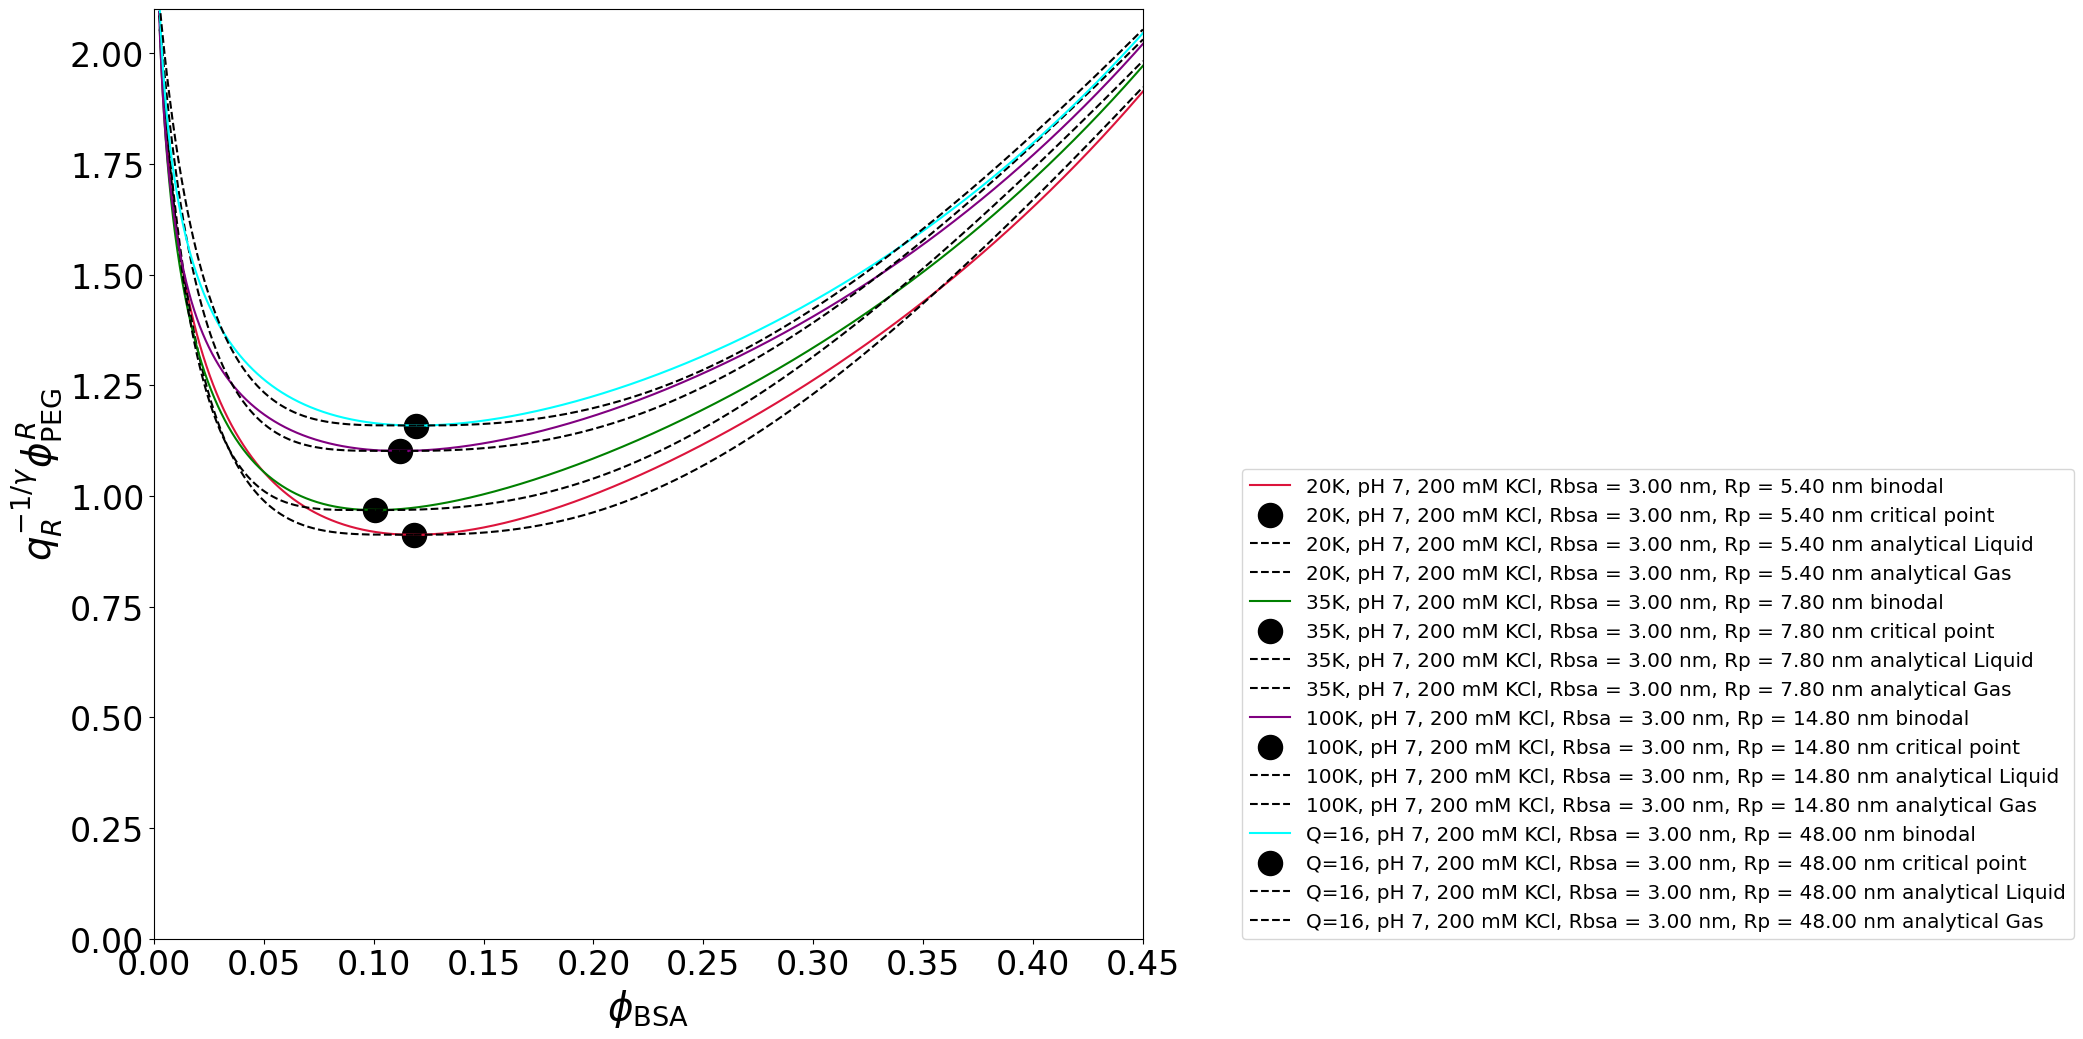

In [5]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.45)
plt.ylim(0,2.1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# molplot_phiR(gfvt4K_200mM_Z0_full, '4K, pH 7, 200 mM KCl, ', 'orange', crit_color='red')
# molplot_phiR(gfvt6K_200mM_Z0_full, '6K, pH 7, 200 mM KCl, ', 'black', crit_color='red')
# molplot_phiR(gfvt8K_200mM_Z0_full, '8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='red')
BSA_PEG_20K.molplot_phiR('20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='black')
BSA_PEG_35K.molplot_phiR('35K, pH 7, 200 mM KCl, ', 'green', crit_color='black')
BSA_PEG_100K.molplot_phiR('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')
# BSA_PEG_Q8_full.molplot_phiR('Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
# BSA_PEG_Q10_full.molplot_phiR('Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phiR('Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black', show_legend=True)

# plt.grid(True, which='both', ls='--', lw=0.5)


# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_phi_analytical

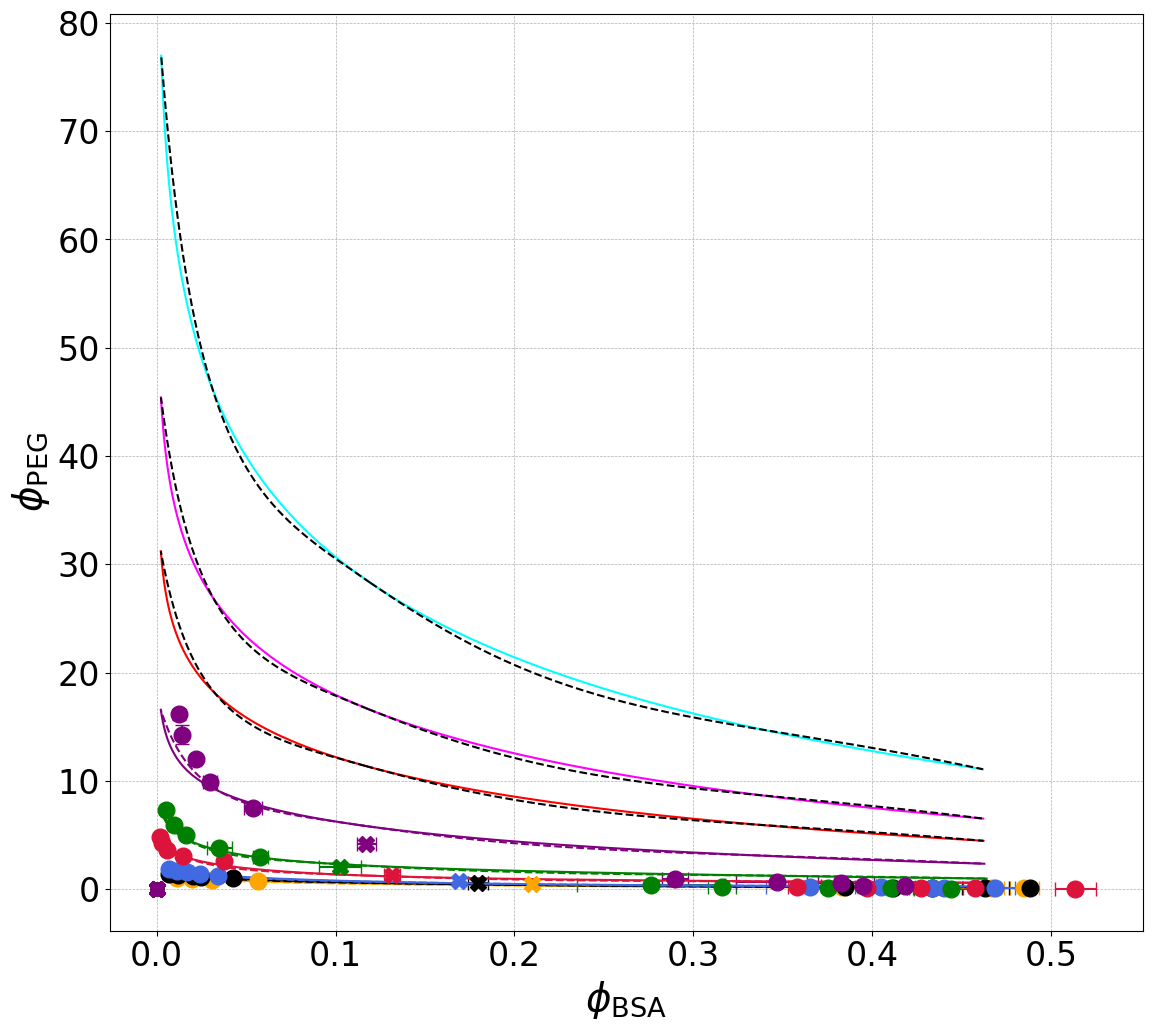

In [6]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,0.5)
# plt.ylim(0,2.5)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4, gamma=0)
BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, gamma=0)
BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, gamma=0)
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20, gamma=0)
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, gamma=0)
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100, gamma=0)

BSA_PEG_4K.molplot_phi_analytical(f'4K, pH 7, 200 mM KCl, ', 'orange', crit_color='orange')
BSA_PEG_6K.molplot_phi_analytical(f'6K, pH 7, 200 mM KCl, ', 'black', crit_color='black')
BSA_PEG_8K.molplot_phi_analytical(f'8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='royalblue')
BSA_PEG_20K.molplot_phi_analytical(f'20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='crimson')
BSA_PEG_35K.molplot_phi_analytical(f'35K, pH 7, 200 mM KCl, ', 'green', crit_color='green')
BSA_PEG_100K.molplot_phi_analytical(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='purple')
BSA_PEG_Q8.molplot_phi_analytical(f'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
BSA_PEG_Q10.molplot_phi_analytical(f'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phi_analytical(f'Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_analytical

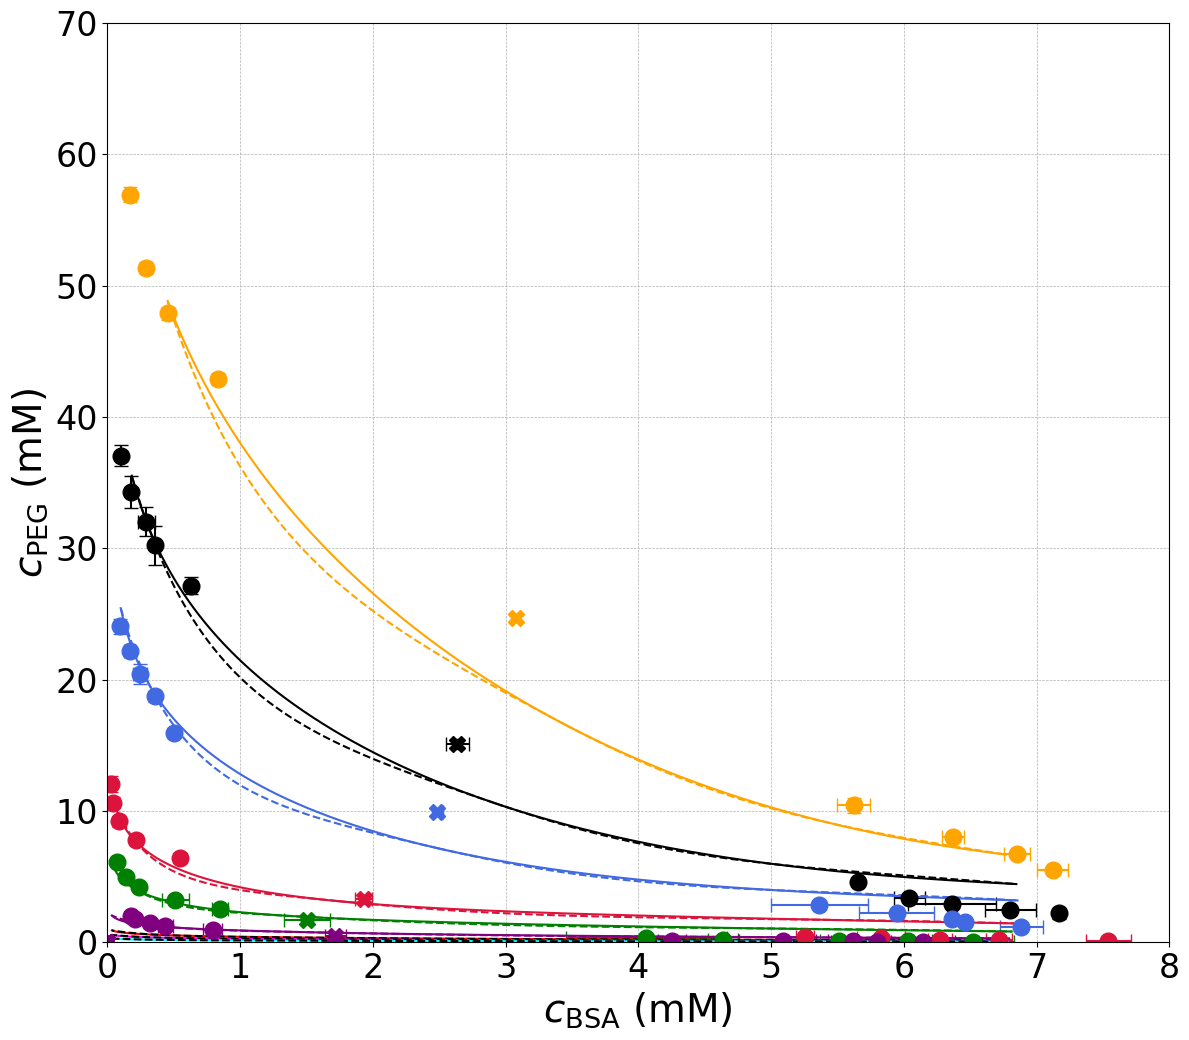

In [7]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA}$ (mM)',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG}$ (mM)',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K.molplot_analytical(f'4K, pH 7, 200 mM KCl, ', 'orange', crit_color='orange')
BSA_PEG_6K.molplot_analytical(f'6K, pH 7, 200 mM KCl, ', 'black', crit_color='black')
BSA_PEG_8K.molplot_analytical(f'8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='royalblue')
BSA_PEG_20K.molplot_analytical(f'20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='crimson')
BSA_PEG_35K.molplot_analytical(f'35K, pH 7, 200 mM KCl, ', 'green', crit_color='green')
BSA_PEG_100K.molplot_analytical(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='purple')
BSA_PEG_Q8.molplot_analytical(f'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
BSA_PEG_Q10.molplot_analytical(f'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_analytical(f'Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## theta solvent

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 500 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 

guess_b = [g1, g2];
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_theta = PD(3.0e-9, 1.52e-9, mbsa, mpeg4, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 1# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt6K_200mM_Z0_theta[-1][7]
guess_b = gfvt6K_200mM_Z0_theta[-1][8]

# gfvt6K_200mM_Z0_theta = PD(3.0e-9, 1.95e-9, mbsa, mpeg6, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt8K_200mM_Z0_theta = PD(3.0e-9, 2.35e-9, mbsa, mpeg8, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 2.0# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt20K_200mM_Z0_theta[-1][7]
guess_b = gfvt20K_200mM_Z0_theta[-1][8]

# gfvt20K_200mM_Z0_theta = PD(3.0e-9, 3.7e-9, mbsa, mpeg20, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 2.4# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt100K_200mM_Z0_theta[-1][7]
guess_b = gfvt100K_200mM_Z0_theta[-1][8]

# gfvt35K_200mM_Z0_theta = PD(3.0e-9, 4.8e-9, mbsa, mpeg35, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt100K_200mM_Z0_theta = PD(3.0e-9, 7.0e-9, mbsa, mpeg100, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
guess_b = [1e-4, 0.5];
guess_c = [0.24, 0.7];
PhiP_max = 24# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
# gfvt100K_200mM_Z0_rg = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, 'RG', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)


PD.molplot_dat_err_csv(data_4K_pH7_200mM, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA, '4K, pH 7, 200 mM KCl', 'magenta', mbsa, mpeg4,False)
PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA2, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'magenta', mbsa, mpeg4,False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

PD.from_legacy_list(gfvt4K_200mM_Z0_theta).molplot(f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
gfvt4K_200mM_Z0.molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0_theta).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0_theta).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0_theta).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0_theta).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0_theta).molplot(f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0_rg).molplot(f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
# plt.savefig('phase_diagram.png')

# plt.yscale('log')

#%%

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

## FVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
solvent = 'theta'

guess_b = [g1, g2];
guess_c = 0;

PhiP_max = 1.4 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt4K_200mM_Z0_FVT = PD(3.0e-9, 1.52e-9, mbsa, mpeg4, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 2.0 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
# gfvt6K_200mM_Z0_FVT = PD(3.0e-9, 1.95e-9, mbsa, mpeg6, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt8K_200mM_Z0_FVT = PD(3.0e-9, 2.35e-9, mbsa, mpeg8, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt20K_200mM_Z0_theta = PD(3.0e-9, 3.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt35K_200mM_Z0_FVT = PD(3.0e-9, 4.8-9, mbsa, mpeg35, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PD.molplot_dat_err_csv(data_4K_pH7_200mM, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)


molplot_FVT(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
gfvt4K_200mM_Z0.molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
molplot_FVT(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
molplot_FVT(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt20K_200mM_Z0_theta, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
# plt.savefig('phase_diagram.png')

# plt.yscale('log')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

# Fig. 1

<Axes: xlabel='$c_\\mathrm{BSA} (mM)$', ylabel='$c_\\mathrm{PEG} (mM)$'>

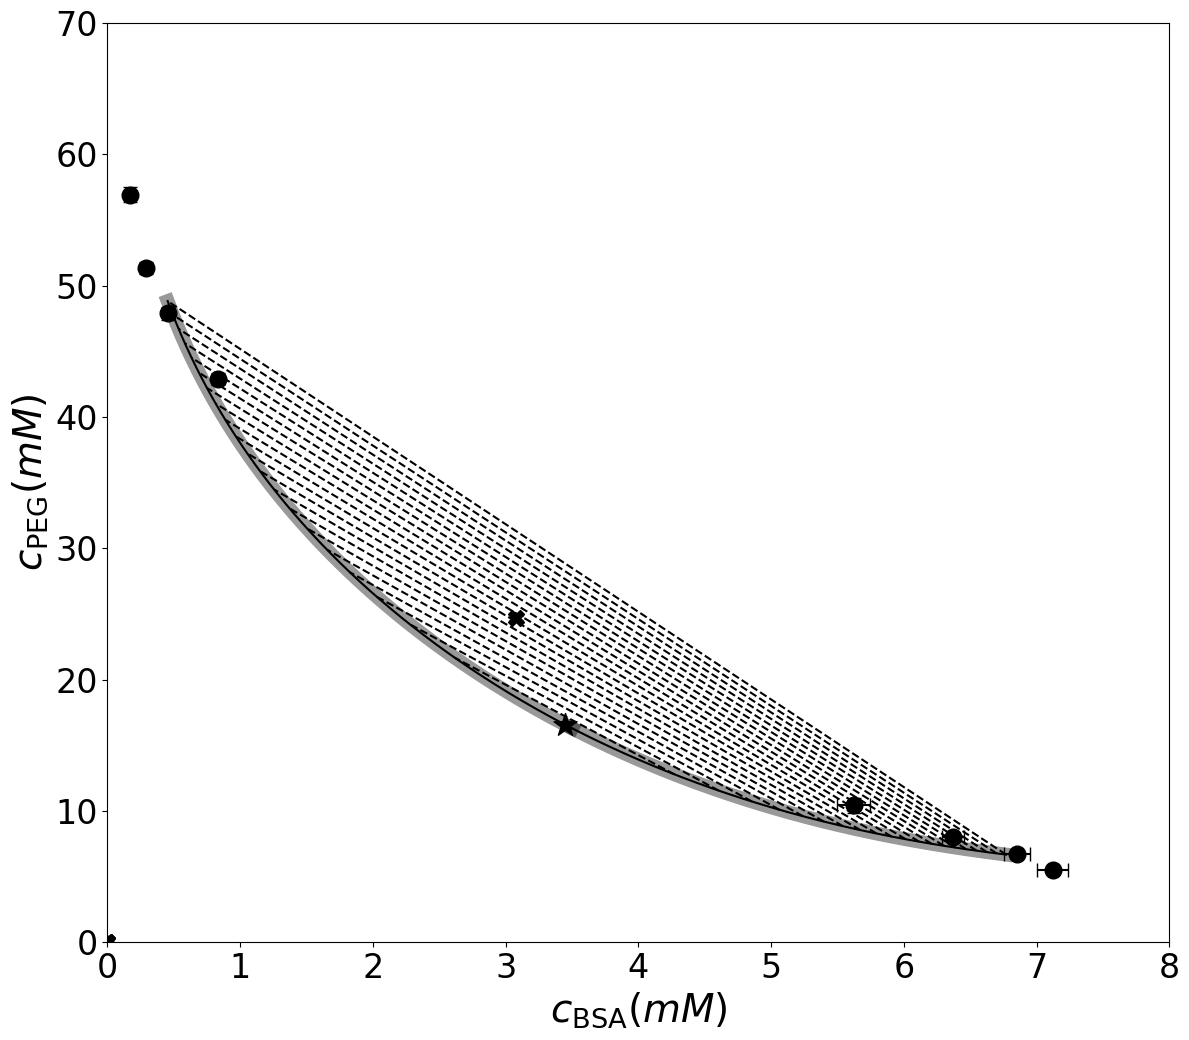

In [8]:
# figh = plt.figure(2, figsize = (20,9)) # aspect ratio for slide?
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

N_steps = 2000
guess_c = [0.24, 0.7]
# gfvt4K_200mM_Z0_full = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)

BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'black', n_tie=100)
# molplot_dat_err_csv(data_4K_pH7_200mM, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA2, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg4)

# plt.savefig('../output/'+date_string+'_phase_diagram_all_tie_Z0_good_molar_Fig01.png')
# plt.savefig(date_string+'_phase_diagram_all_tie_Z0_good_molar_Fig01.eps')

# Fig. 2

## Fig. 2A - PEG MW

### Between Triple Points

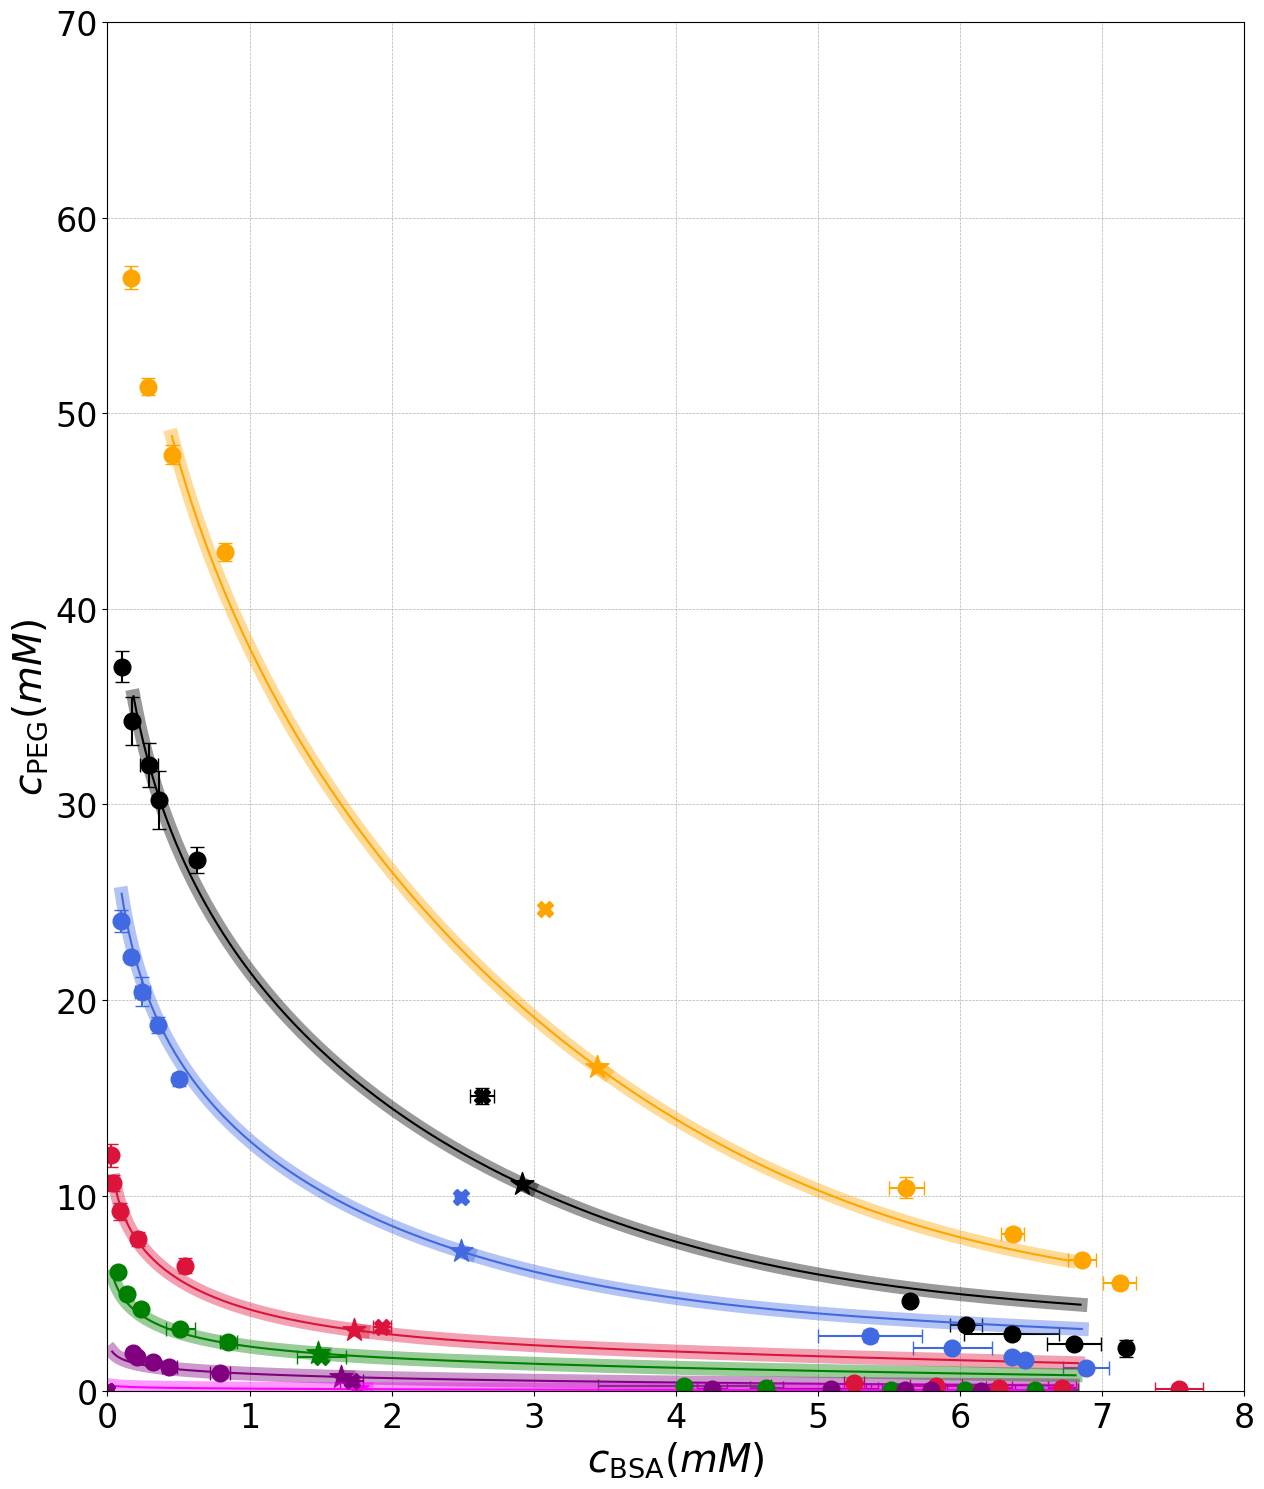

In [12]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'orange')
BSA_PEG_6K.molplot('6K, pH 7, 200 mM KCl, ', 'black')
BSA_PEG_8K.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot('20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot('35K, pH 7, 200 mM KCl, ', 'green')
# BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='gray')
BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple')
BSA_PEG_Q16.molplot('Q=16, pH 7, 200 mM KCl, ', 'magenta')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.eps')

### Full range

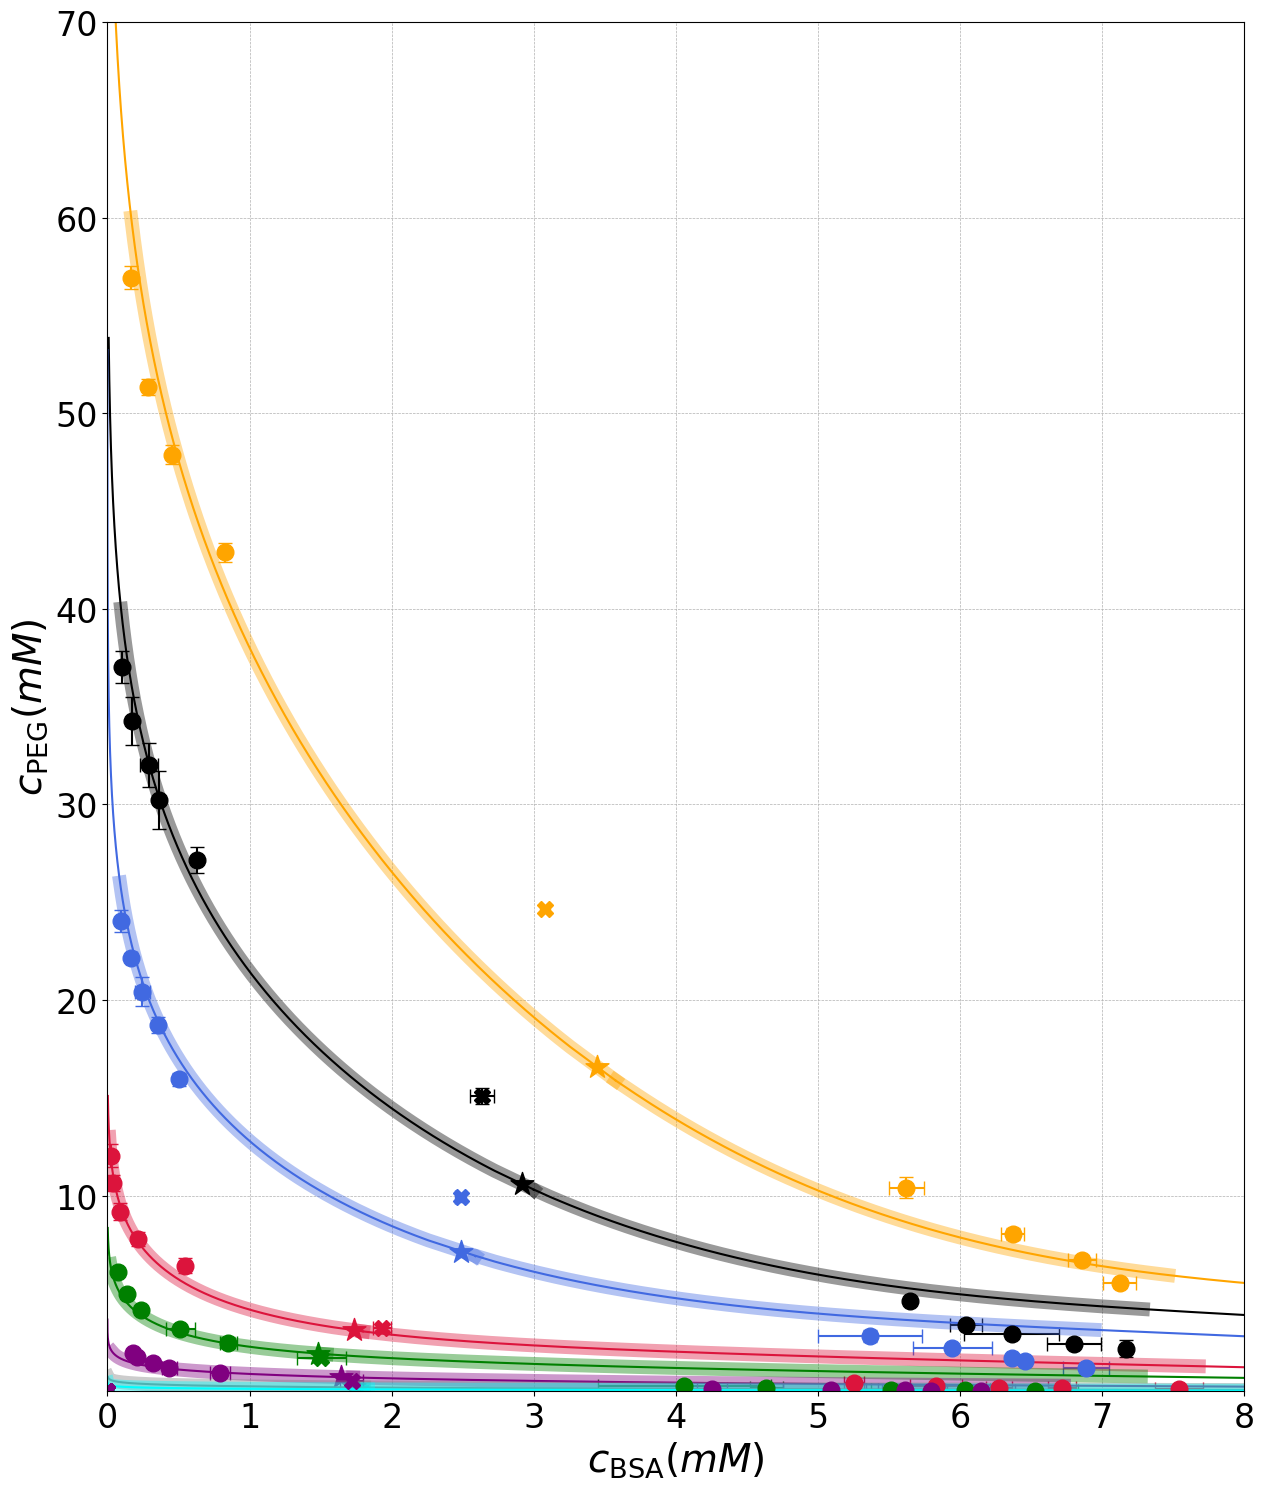

In [13]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0.01,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K_full.molplot('4K, pH 7, 200 mM KCl, ', 'orange', plim=60)
BSA_PEG_6K_full.molplot('6K, pH 7, 200 mM KCl, ', 'black', plim=40)
BSA_PEG_8K_full.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', plim=26)
BSA_PEG_20K_full.molplot('20K, pH 7, 200 mM KCl, ', 'crimson', plim=13)
BSA_PEG_35K_full.molplot('35K, pH 7, 200 mM KCl, ', 'green', plim=6.5)
BSA_PEG_100K_full.molplot('100K, pH 7, 200 mM KCl, ', 'purple', plim=2)
BSA_PEG_Q10_full.molplot('Q=10, pH 7, 200 mM KCl, ', 'gray')
BSA_PEG_Q16_full.molplot('Q=16, pH 7, 200 mM KCl, ', 'cyan')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.eps')

### Mass (g/L)

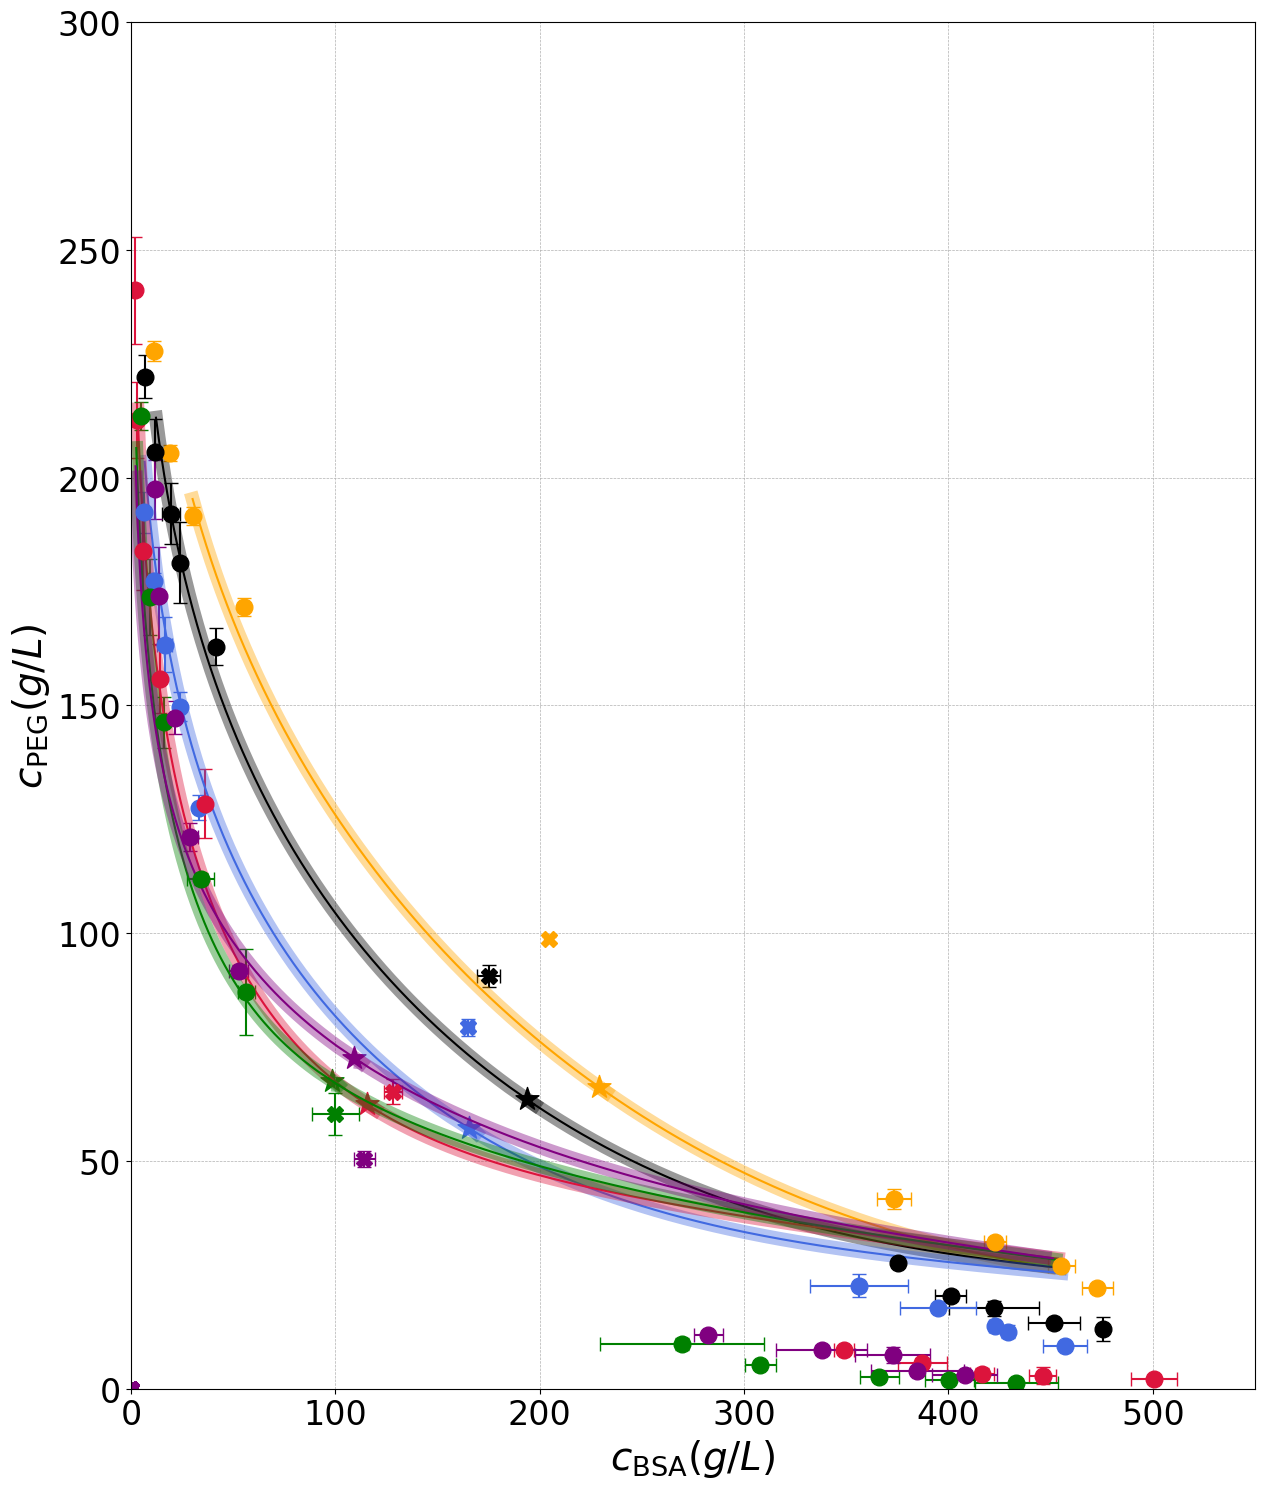

In [35]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,550)
plt.ylim(0,300)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', False)

BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'orange', mass=True, plim=60)
BSA_PEG_6K.molplot('6K, pH 7, 200 mM KCl, ', 'black', mass=True, plim=40)
BSA_PEG_8K.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True, plim=26)
BSA_PEG_20K.molplot('20K, pH 7, 200 mM KCl, ', 'crimson', mass=True, plim=12.4)
BSA_PEG_35K.molplot('35K, pH 7, 200 mM KCl, ', 'green', mass=True, plim=6.5)
BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple', mass=True, plim=2)
# molplot(gfvtQ8_200mM_Z0, f'Q=8, pH 7, 200 mM KCl, ', 'red', mass=True)
# molplot(gfvtQ16_200mM_Z0, f'Q=16, pH 7, 200 mM KCl, ', 'magenta', mass=True)
plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

<Axes: xlabel='$c_\\mathrm{BSA} (g/L)$', ylabel='$c_\\mathrm{PEG} (g/L)$'>

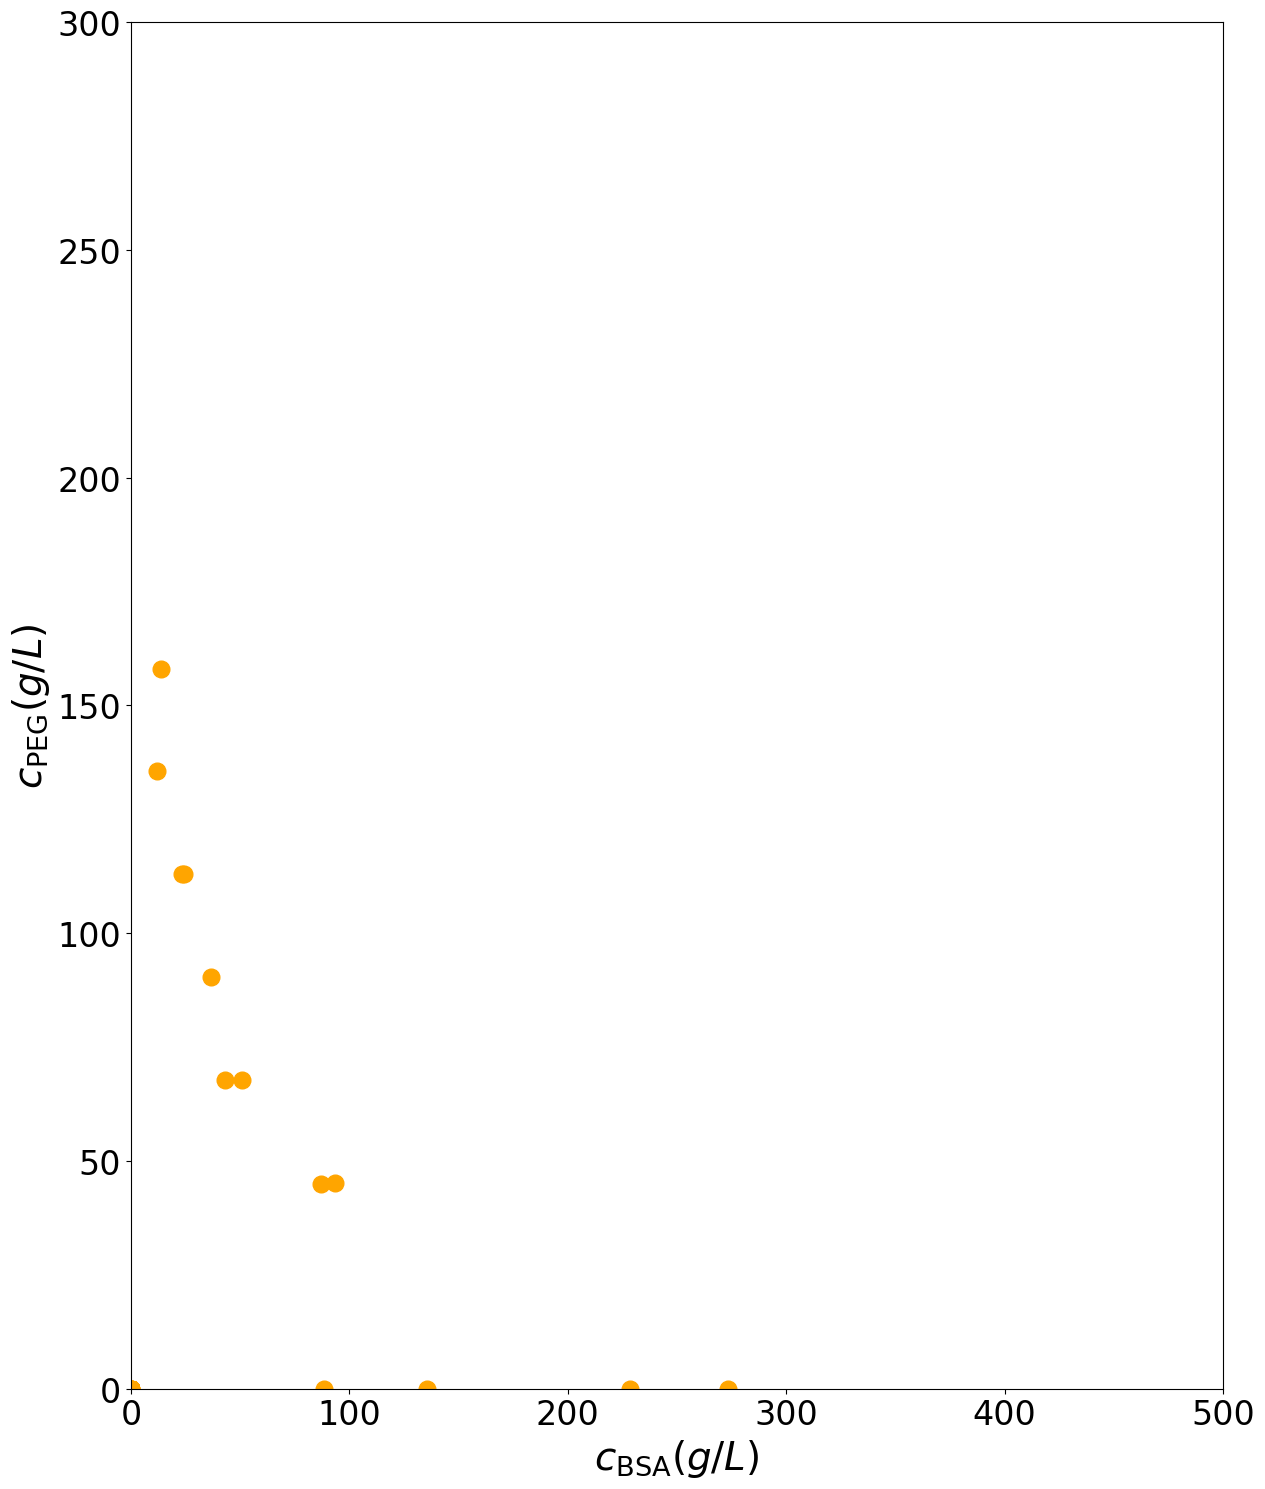

In [9]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,300)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'orange', False)


## Fig. 2B

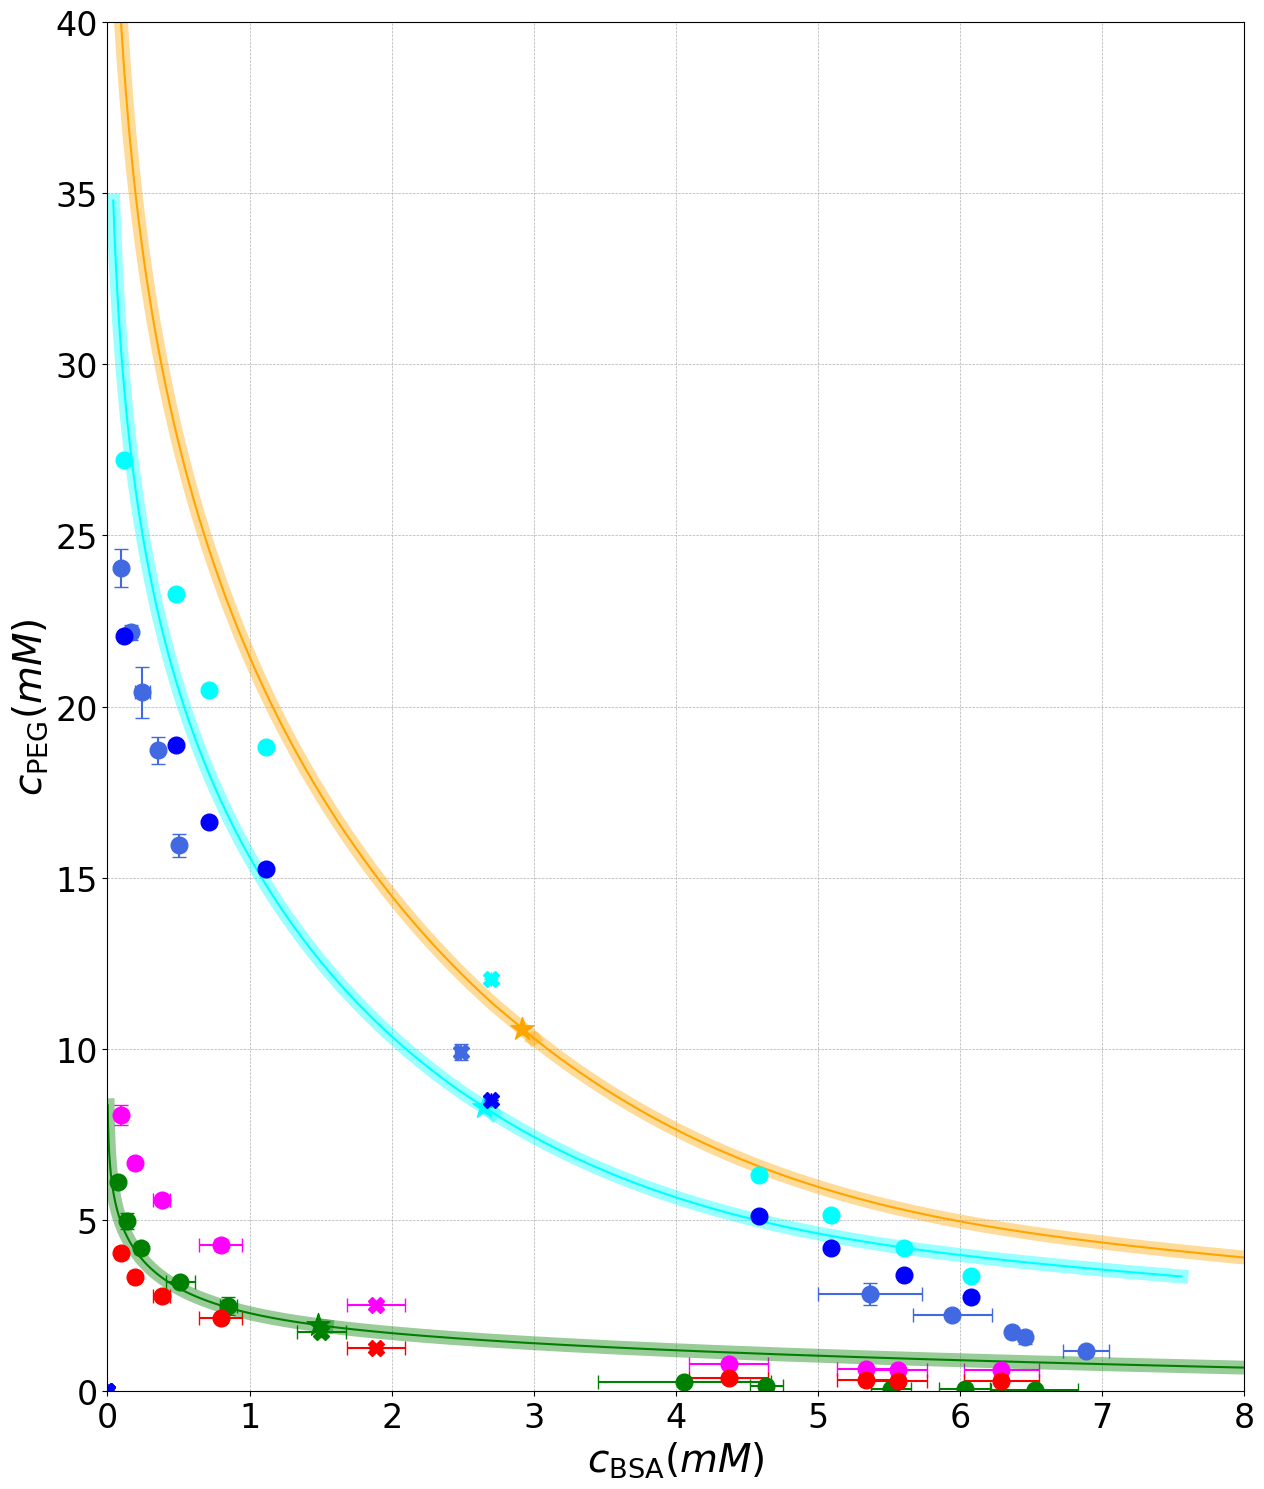

In [10]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,40)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mw=25K, pH 7, 200 mM KCl', 'magenta', mbsa=mbsa, mpeg=25)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red', mbsa=mbsa, mpeg=mpeg35)

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa, mpeg=mpeg6, False)
# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mw=6.7K, pH 7, 200 mM KCl', 'red', mbsa=mbsa, mpeg=6.7, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'blue', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', mbsa=mbsa, mpeg=7.3)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue', mbsa=mbsa, mpeg=8)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mn=5K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa,  mpeg=5, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mw=6.8K, pH 7, 200 mM KCl', 'yellowgreen', mbsa=mbsa,  mpeg=6.8, False)

# data_2K8K_pH7_200mM_n = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/New format_PEG 2K+8K-200 mM-pH Binodal.csv', delimiter=',')
# data_2K8K_pH7_200mM_n_MW = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/PEG-2K8KK pH-7, 200 mM Salt.csv', delimiter=',')
# data_2K8K_pH7_200mM_n_MW8K = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/PEG-2K8KK pH-7, 200 mM Salt_8Kmass.csv', delimiter=',')



# molplot(gfvt4K_200mM_Z0, '4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
BSA_PEG_6K_full.molplot('6K, pH 7, 200 mM KCl, ', 'orange', 'red')
# molplot(gfvt6p7K_200mM_Z0, '6.7K, pH 7, 200 mM KCl, ', 'red', 'red')
BSA_PEG_7p3K_full.molplot('7.3K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt8K_200mM_Z0, '8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, '20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
BSA_PEG_35K_full.molplot('35K, pH 7, 200 mM KCl, ', 'green', 'red')
# molplot(gfvt25K_200mM_Z0, '25K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# If you have 251.3 mM final osmolarity, it should be 221.1 mM PEG 2K and 30.15 mM PEG 35K.
# I get you need 350 uL of 580 g/L 2K PEG for every 1 mL of 490 g/L 35K PEG.

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_good_molar_Fig02B.png')
# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_molar_Fig02B.eps')

<Axes: xlabel='$c_\\mathrm{BSA} (g/L)$', ylabel='$c_\\mathrm{PEG} (g/L)$'>

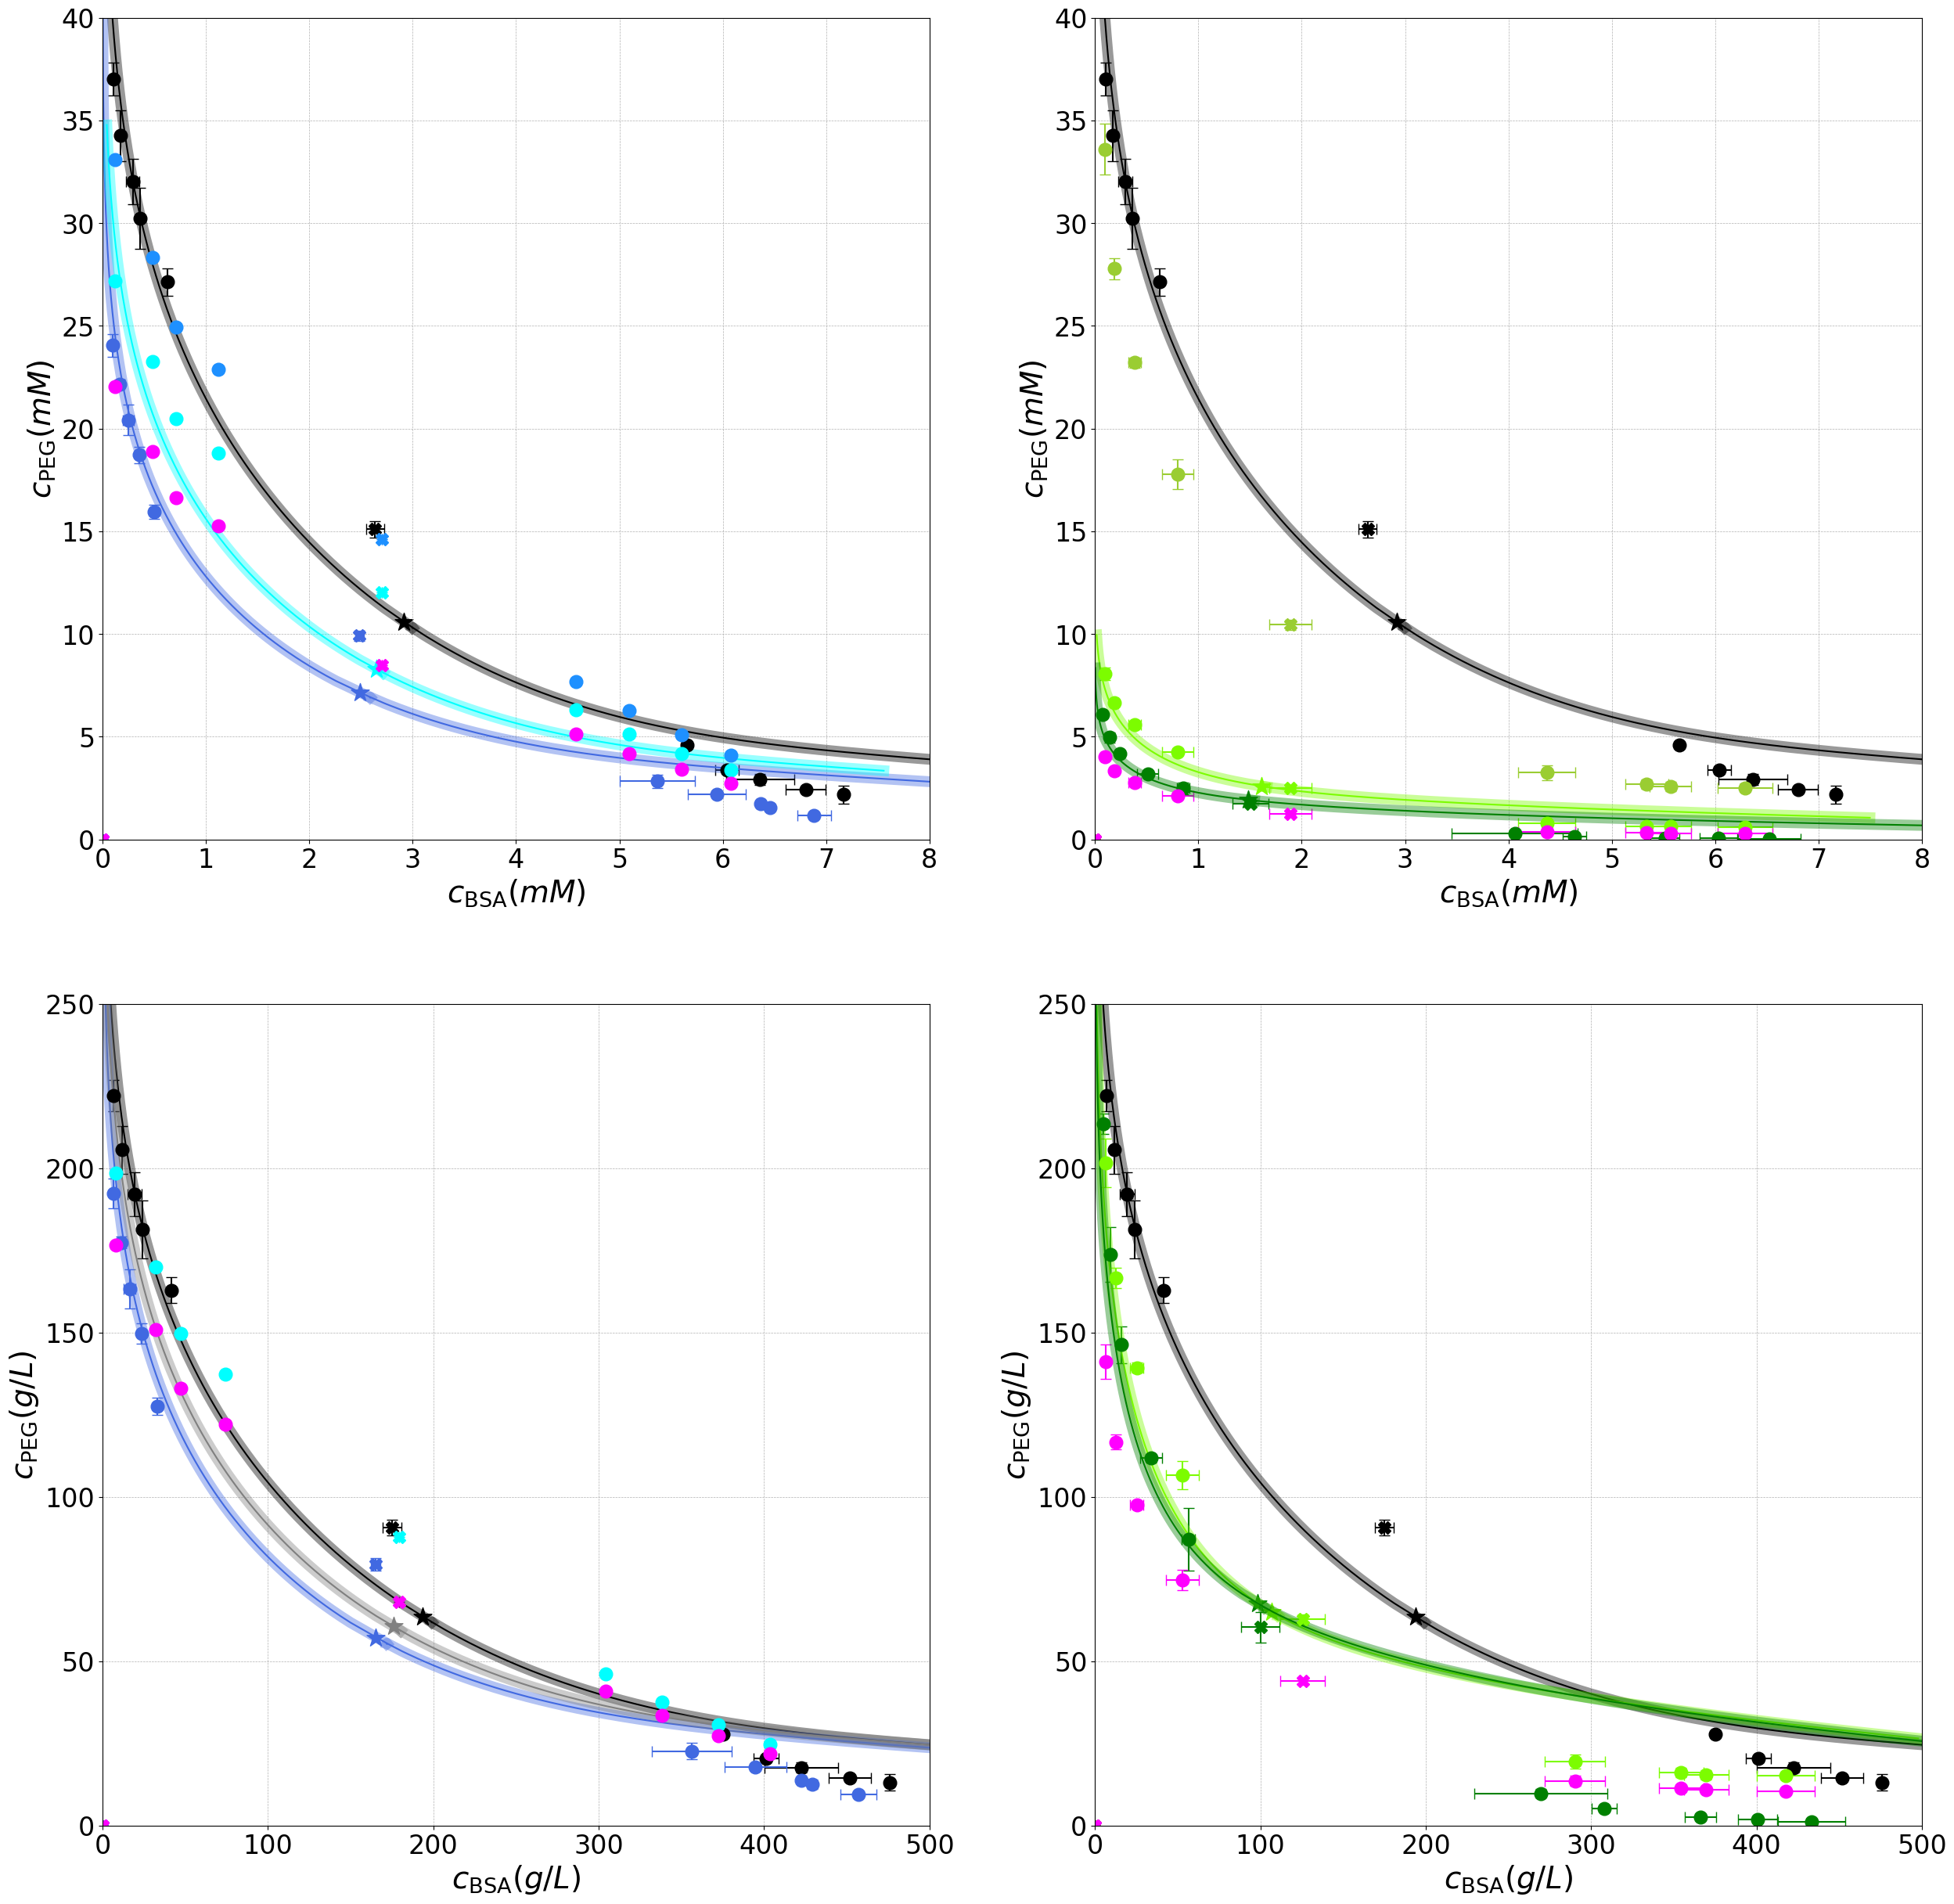

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(30, 30))

# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

axes[0][0].set_xlim(0,8)
axes[0][0].set_ylim(0,40)
axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0][0].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][0].grid(True, which='both', ls='--', lw=0.5)

axes[0][1].set_xlim(0,8)
axes[0][1].set_ylim(0,40)
axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
axes[0][1].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0][1].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][1].grid(True, which='both', ls='--', lw=0.5)


axes[1][0].set_xlim(0,500)
axes[1][0].set_ylim(0,250)
axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][0].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][0].grid(True, which='both', ls='--', lw=0.5)

axes[1][1].set_xlim(0,500)
axes[1][1].set_ylim(0,250)
axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][1].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][1].grid(True, which='both', ls='--', lw=0.5)

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[0][0])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'dodgerblue', mbsa=mbsa, mpeg=6, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', mbsa=mbsa, mpeg=7.3, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'magenta', mbsa=mbsa, mpeg=mpeg8, ax=axes[0][0])

BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', ax=axes[0][0])
BSA_PEG_8K_full.molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[0][0])
BSA_PEG_7p3K_full.molplot(f'7.3K, pH 7, 200 mM KCl, ', 'cyan', ax=axes[0][0])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[0][1])
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[0][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'yellowgreen', mbsa=mbsa, mpeg=6, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mw=25K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa, mpeg=25, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl ', 'magenta', mbsa=mbsa, mpeg=mpeg35, ax=axes[0][1])

BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', ax=axes[0][1])
BSA_PEG_25K_full.molplot(f'25K, pH 7, 200 mM KCl, ', 'lawngreen', mbsa=mbsa, mpeg=25, ax=axes[0][1])
BSA_PEG_35K_full.molplot(f'35K, pH 7, 200 mM KCl, ', 'green', ax=axes[0][1])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][0])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', ax=axes[1][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', ax=axes[1][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'magenta', ax=axes[1][0])

BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True, ax=axes[1][0])
BSA_PEG_8K_full.molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True, ax=axes[1][0])
BSA_PEG_7p3K_full.molplot(f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3, ax=axes[1][0])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][1])
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[1][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', ax=axes[1][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'lawngreen', ax=axes[1][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl ', 'magenta', ax=axes[1][1])

BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True, ax=axes[1][1])
BSA_PEG_25K_full.molplot(f'25K, pH 7, 200 mM KCl, ', 'lawngreen', mass=True, mbsa=mbsa, mpeg=25, ax=axes[1][1])
# molplot(BSA_PEG_20K_full, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', mass=True, mbsa=mbsa, mpeg=mpeg20, ax=axes[1][1])
BSA_PEG_35K_full.molplot(f'35K, pH 7, 200 mM KCl, ', 'green', mass=True, ax=axes[1][1])

# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_all_FigS1.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_all_FigS1.eps')

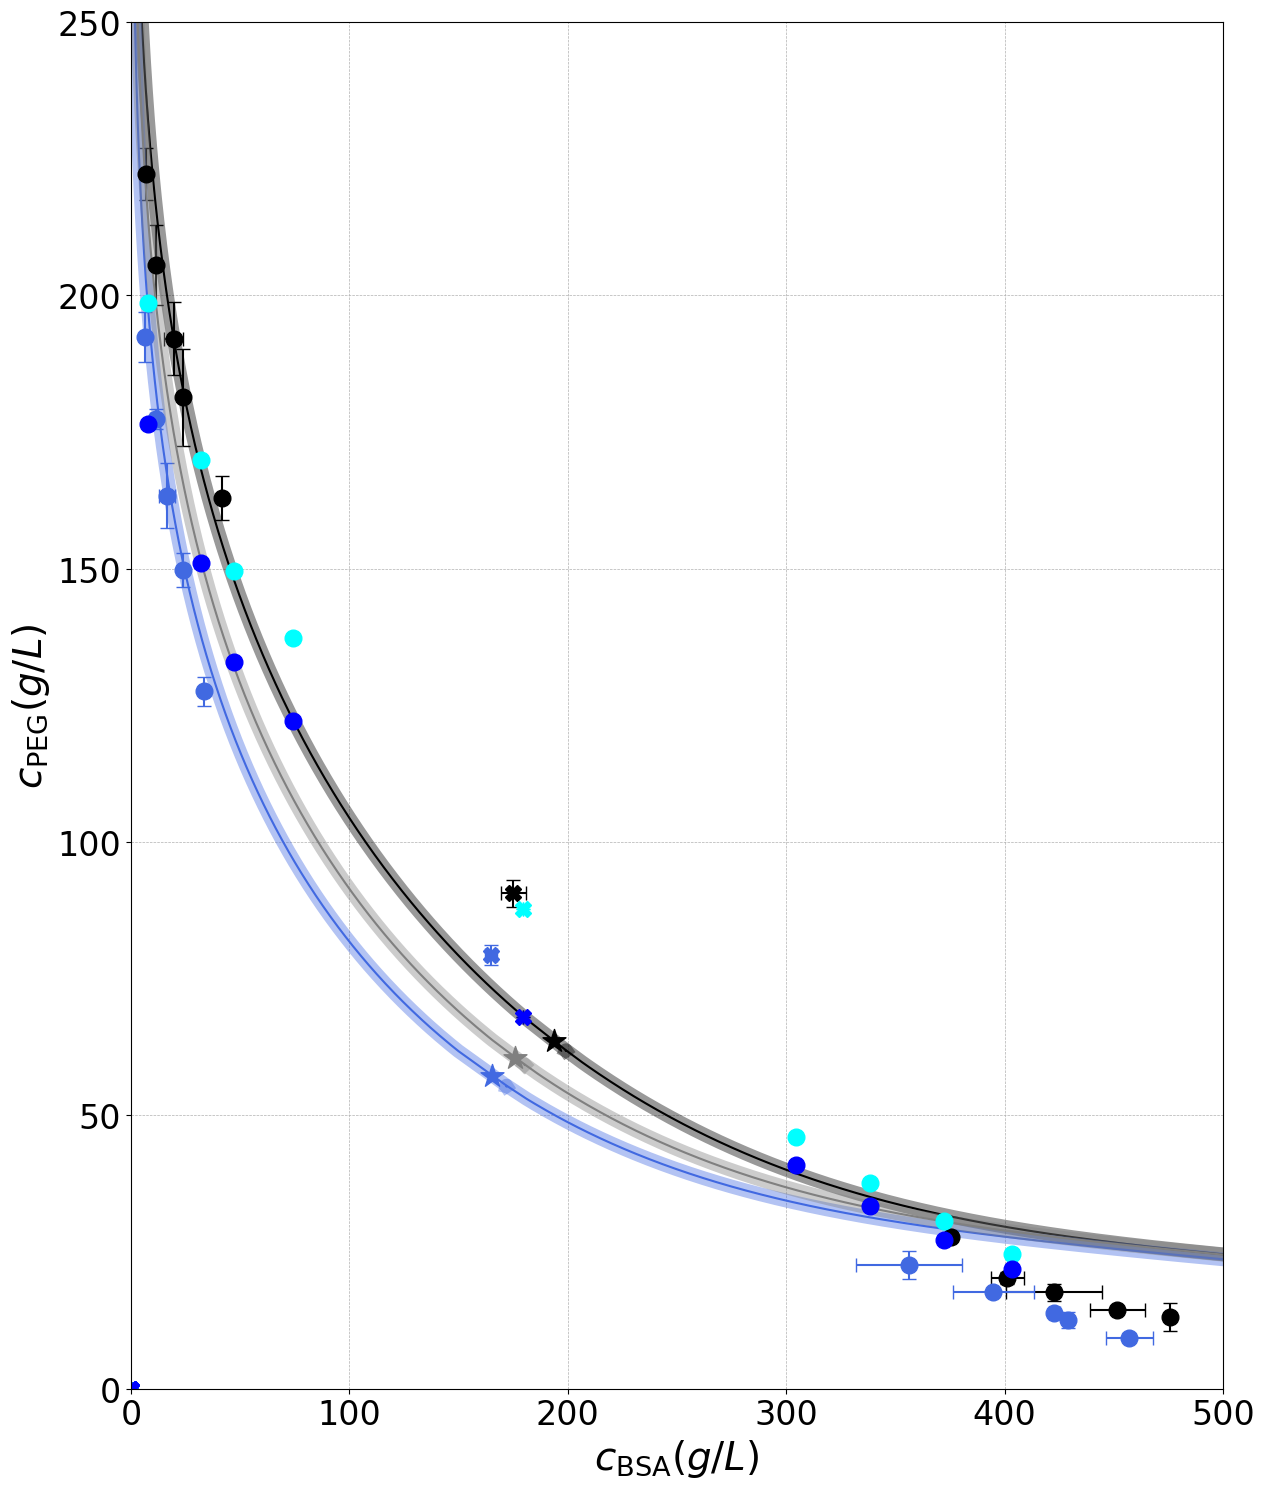

In [20]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black')
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue')

# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson')
# molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green')

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K Mw=6.7K, pH 7, 200 mM KCl', 'magenta')
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K Mw=25, pH 7, 200 mM KCl', 'purple')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K Mw=7, pH 7, 200 mM KCl', 'cyan')
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'cyan')
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue')

# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', False)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True)

BSA_PEG_8K_full.molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'green', 'red', False, mbsa=mbsa, mpeg=mpeg35)
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red', False, mbsa=mbsa, mpeg=mpeg100)


# molplot(gfvt6p7K_200mM_Z0, f'6.7K, pH 7, 200 mM KCl, ', 'red', 'red', False, mbsa=mbsa, mpeg=6.7)
BSA_PEG_7p3K_full.molplot(f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3)

# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'green', mass=True)
# molplot(gfvt25K_200mM_Z0, f'25K, pH 7, 200 mM KCl, ', 'magenta', mass=True)

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.png')
# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.eps')

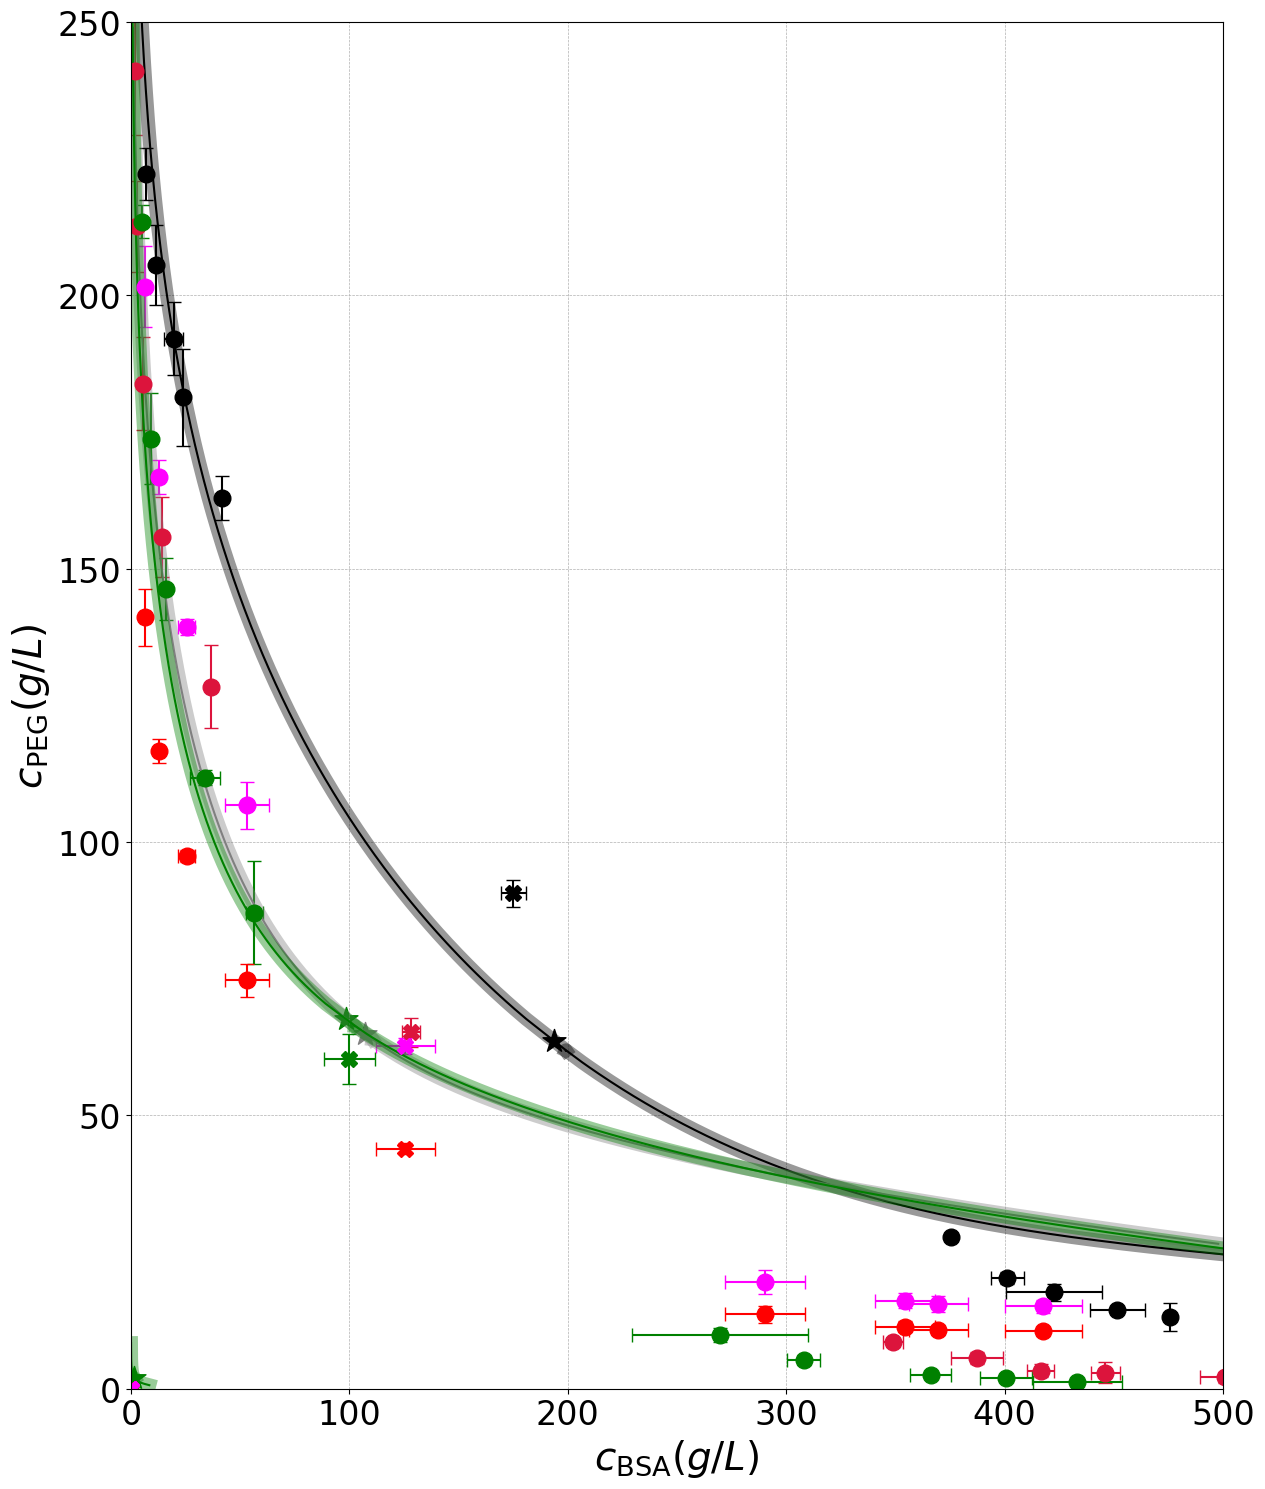

In [22]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black')
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue')

PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson')
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green')

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K Mw=6.7K, pH 7, 200 mM KCl', 'magenta')
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K Mw=25, pH 7, 200 mM KCl', 'purple')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K Mw=7, pH 7, 200 mM KCl', 'cyan')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'cyan')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_8Konly, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue')

# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', False)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red')
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'magenta')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
BSA_PEG_6K_full.molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True)

# molplot(gfvt8K_200mM_Z0_full, f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
BSA_PEG_35K_full.molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red', False, mbsa=mbsa, mpeg=mpeg35)
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red', False, mbsa=mbsa, mpeg=mpeg100)


# molplot(gfvt6p7K_200mM_Z0, f'6.7K, pH 7, 200 mM KCl, ', 'red', 'red', False, mbsa=mbsa, mpeg=6.7)
# molplot(gfvt7p3K_200mM_Z0_full, f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3)
BSA_PEG_25K_full.molplot(f'25K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=25)

# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
BSA_PEG_35K_full.molplot(f'35K, pH 7, 200 mM KCl, ', 'green', mass=True)
# molplot(gfvt25K_200mM_Z0, f'25K, pH 7, 200 mM KCl, ', 'magenta', mass=True)

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.eps')

## Fig. 2C - Rg scaling

Flory Exponent: 0.6379224202053759, Prefactor: 0.009712783237984987
Chi squared (power): 0.0394


[6.2070926920715594, 2.830374908809617, 2.6796779006716087]

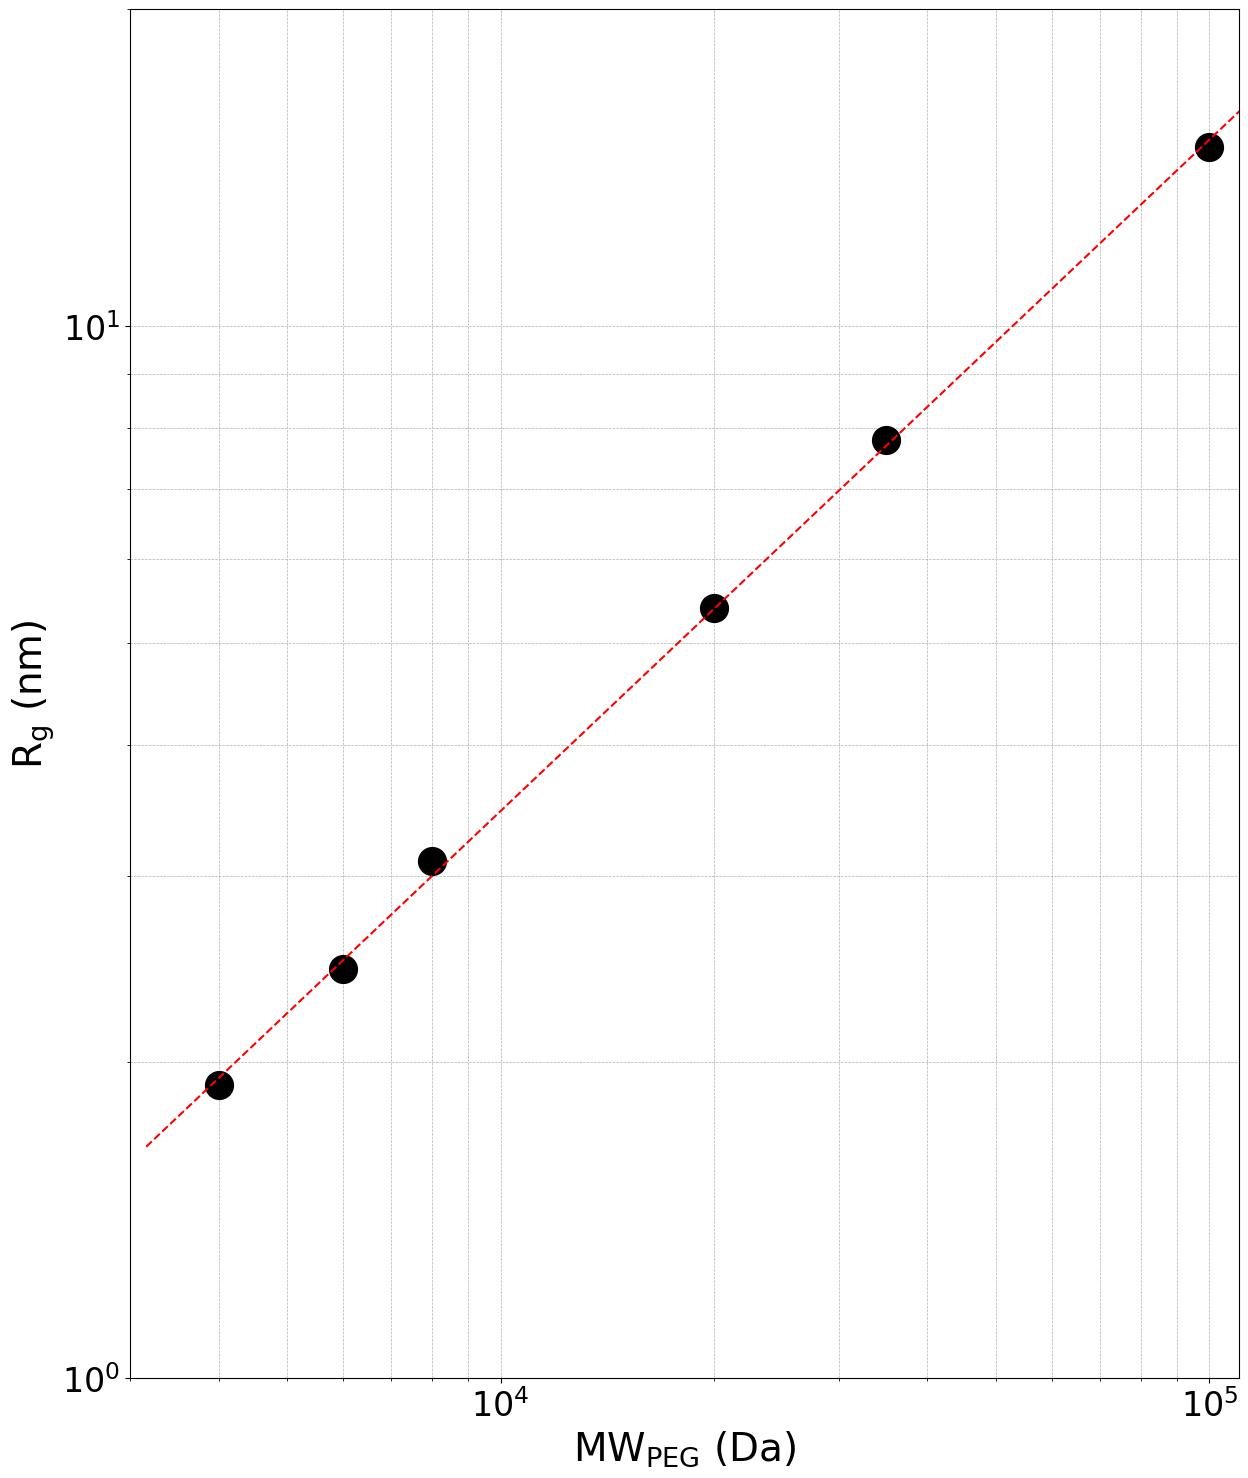

In [23]:
figh, ax = plt.subplots(1, 1, figsize = (12.75,15))   #width x height, aspect ratio 0.85 (0.87)
# plt.xlim(3000,40000)
plt.xlim(3000,110000)
plt.ylim(1,20)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\mathrm{MW_{PEG}}$ (Da)',fontsize = 28)
plt.ylabel(r'$\mathrm{R_{g}}$ (nm)',fontsize = 28)
plt.tight_layout()

mwlist = [4000, 6000, 8000, 20000, 35000, 100000]
# Rplist = [1.9, 2.45,  3.1, 5.6, 8.4]
Rplist = [1.9, 2.45,  3.1, 5.4, 7.8, 14.8]


mwrange = np.logspace(3.5,110,100)

lgmw = np.asarray([np.log10(mw) for mw in mwlist])

lgRp = np.asarray([np.log10(rgpol) for rgpol in Rplist])

# Perform linear fit
logfit_rg,residuals,_,_,_ = np.polyfit(lgmw, lgRp, 1,full=True)  # Degree 1 polynomial (linear fit)
slope_rg, intercept_rg = logfit_rg
chi_squared = residuals[0]/(len(mwlist)-2)/0.05**2
print(f"Flory Exponent: {slope_rg}, Prefactor: {10**intercept_rg}")
print(f'Chi squared (power): {chi_squared:.4f}')

lgrp_fit =  [10**intercept_rg*x**slope_rg for x in mwrange]
# lgrp_PEG =  [intercept_rg_lin + x*slope_rg_lin for x in mwrange]

plt.loglog(mwlist,Rplist,'ok',markersize=20)
plt.loglog(mwrange, lgrp_fit,'--r')

# ax.xaxis.set_major_locator(mticker.LogLocator(numticks=999))
# ax.xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
# ax.yaxis.set_major_locator(mticker.LogLocator(numticks=999))
# ax.yaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
ax.grid(True, which='both', ls='--', lw=0.5)

[10**intercept_rg*x**slope_rg for x in [25000, 7300, 6700]]

# plt.savefig('../output/'+date_string+'_MW_Rg_Z0_good_Fig02C.png')
# plt.savefig('../output/'+date_string+'_MW_Rg_Z0_good_Fig02C.eps')

# Fig. 3

## mM

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(50, 10))

axes[0].set_xlim(0,70)
axes[0].set_ylim(0,2.5)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0].set_ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,70)
axes[1].set_ylim(0,180)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1].set_ylabel("Osmolarity (mOsm)",fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,8)
axes[2].set_ylim(0,1)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[2].set_ylabel(r'$\alpha$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)

# axes[1][0].set_xlim(0,200)
# axes[1][0].set_ylim(0.1,1e5)
# axes[1][0].tick_params(axis='x', labelsize=24)
# axes[1][0].tick_params(axis='y', labelsize=24)
# axes[1][0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
# axes[1][0].set_ylabel(r'$\mathrm{\Pi}$',fontsize = 28)
# axes[1][0].grid(True, which='both', ls='--', lw=0.5)
# axes[1][0].set_yscale('log')

    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Drop], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=5)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Sup], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=5)


    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    
    # ax.plot([phi*phix_bsa for phi in Phi_BSA_range], [1-phi*(1+q)**3 for phi in Phi_BSA_range], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')

    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')


BSA_PEG_4K_full.d_Rg('orange', 'PEG 4K', axes[0], plim=60)
BSA_PEG_6K_full.d_Rg('black', 'PEG 6K', axes[0], plim=40)
BSA_PEG_8K_full.d_Rg('royalblue', 'PEG 8K', axes[0], plim=27)
BSA_PEG_20K_full.d_Rg('crimson', 'PEG 20K', axes[0], plim=13)
BSA_PEG_35K_full.d_Rg('green', 'PEG 35K', axes[0], plim=6.5)
BSA_PEG_100K_full.d_Rg('purple', 'PEG 100K', axes[0], plim=2)
# BSA_PEG_Q10_full.d_Rg('magenta', 'Q10', axes[0])
# BSA_PEG_Q16_full.d_Rg('cyan', 'Q15', axes[0])

BSA_PEG_4K_full.pi_scale('orange', 'PEG 4K', axes[1], plim=60)
BSA_PEG_6K_full.pi_scale('black', 'PEG 6K', axes[1], plim=40)
BSA_PEG_8K_full.pi_scale('royalblue', 'PEG 8K', axes[1], plim=26)
BSA_PEG_20K_full.pi_scale('crimson', 'PEG 20K', axes[1], plim=12.4)
BSA_PEG_35K_full.pi_scale('green', 'PEG 35K', axes[1], plim=6.5)
BSA_PEG_100K_full.pi_scale('purple', 'PEG 100K', axes[1], plim=2)
# BSA_PEG_Q10_full.pi_scale('magenta', 'Q10', axes[1])
# BSA_PEG_Q16_full.pi_scale('cyan', 'Q15', axes[1])

BSA_PEG_4K_full.a_plot('orange', 'PEG 4K', axes[2])
BSA_PEG_6K_full.a_plot('black', 'PEG 6K', axes[2])
BSA_PEG_8K_full.a_plot('royalblue', 'PEG 8K', axes[2])
BSA_PEG_20K_full.a_plot('crimson', 'PEG 20K', axes[2])
BSA_PEG_35K_full.a_plot('green', 'PEG 35K', axes[2])
BSA_PEG_100K_full.a_plot('purple', 'PEG 100K', axes[2])
# BSA_PEG_Q10_full.a_plot('magenta', 'Q10', axes[2])
# BSA_PEG_Q16_full.a_plot('cyan', 'Q15', axes[2])

# BSA_PEG_4K_full.a_plot_peg('orange', 'PEG 4K', axes[0][2])
# BSA_PEG_6K_full.a_plot_peg('black', 'PEG 6K', axes[0][2])
# BSA_PEG_8K_full.a_plot_peg('royalblue', 'PEG 8K', axes[0][2])
# BSA_PEG_20K_full.a_plot_peg('crimson', 'PEG 20K', axes[0][2])
# BSA_PEG_35K_full.a_plot_peg('green', 'PEG 35K', axes[0][2])
# BSA_PEG_100K_full.a_plot_peg('purple', 'PEG 100K', axes[0][2])
# BSA_PEG_Q10_full.a_plot_peg('magenta', 'Q10', axes[0][2])
# BSA_PEG_Q16_full.a_plot_peg('cyan', 'Q15', axes[0][2])

plt.savefig('../output/'+date_string+'_d_Pi_a.png')
plt.savefig('../output/'+date_string+'_d_Pi_a.eps')

## g/L

<Axes: xlabel='$c_\\mathrm{BSA} (g/L)$', ylabel='$\\alpha$'>

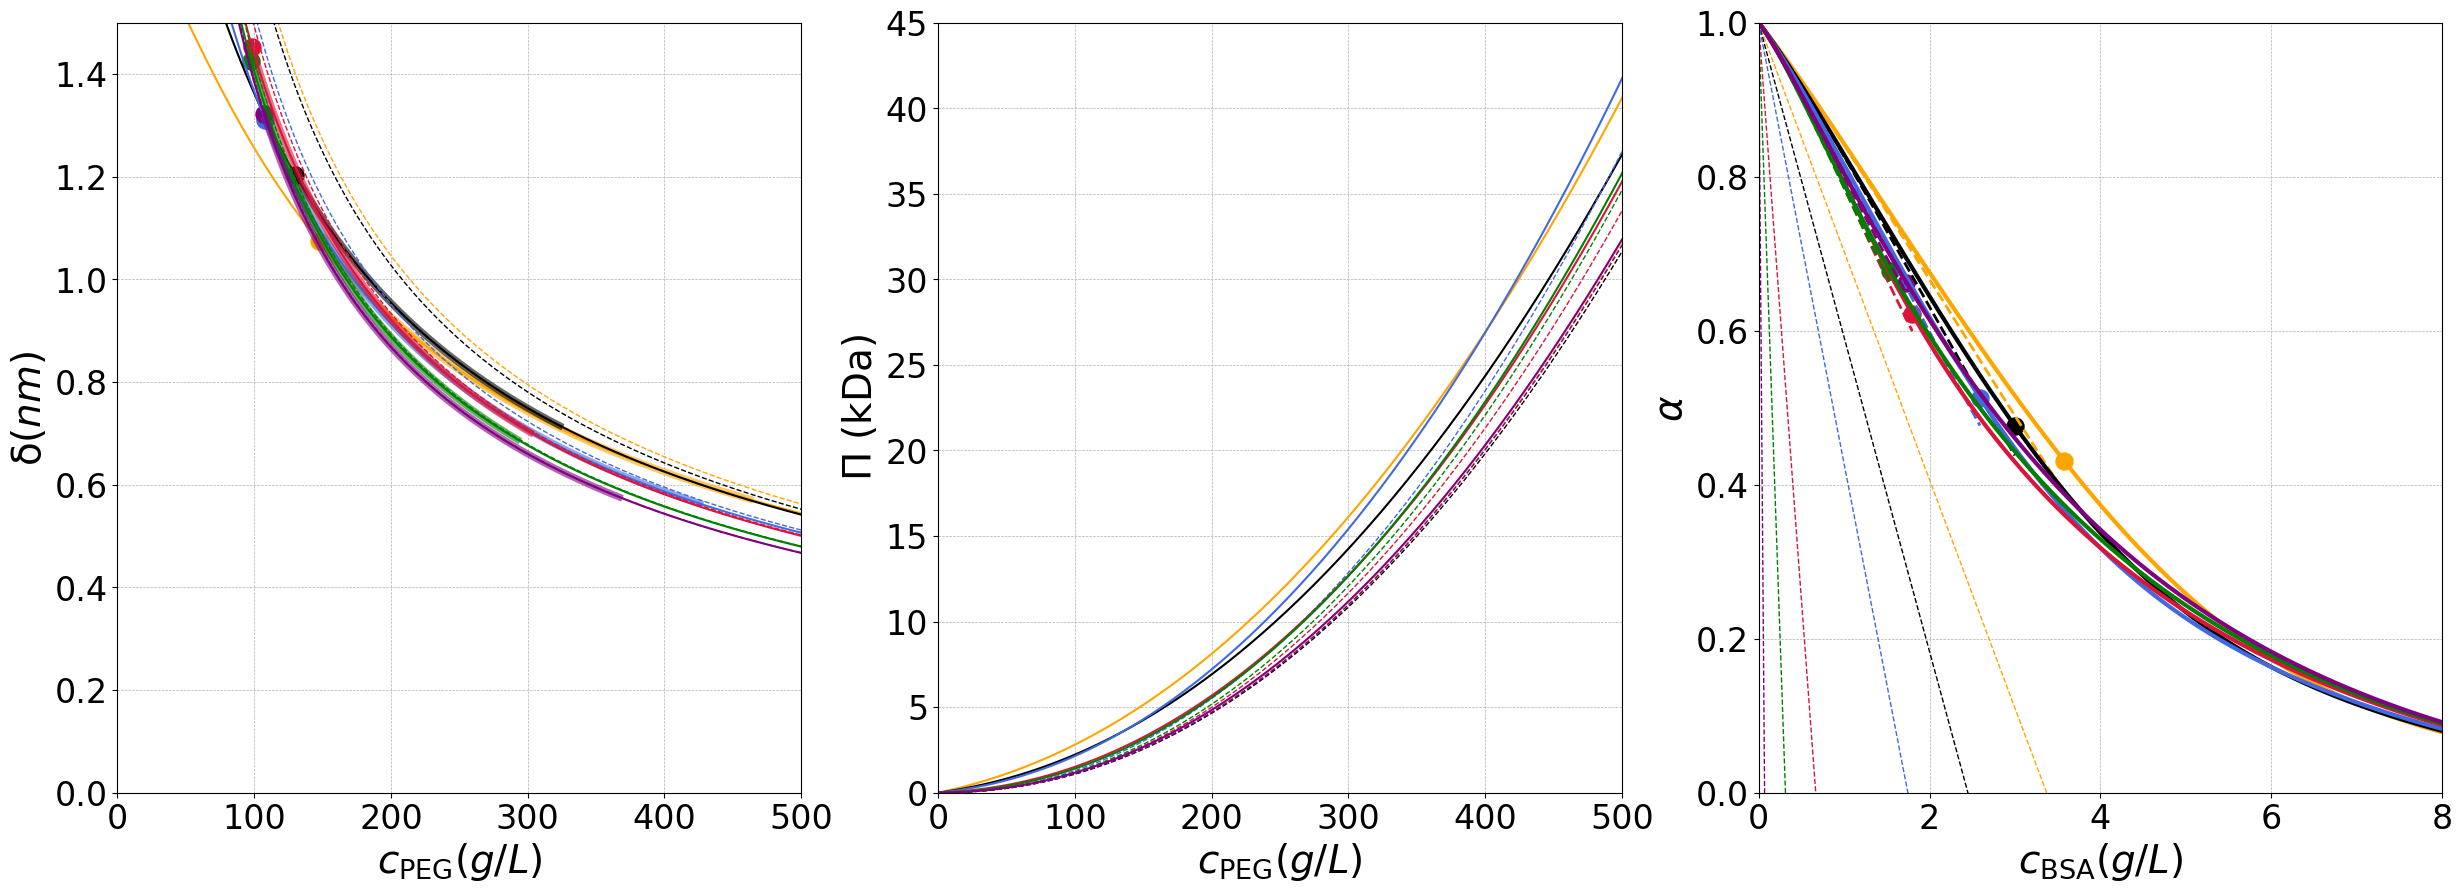

In [24]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].set_xlim(0,500)
axes[0].set_ylim(0,1.5)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[0].set_ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,500)
axes[1].set_ylim(0,45)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1].set_ylabel(r'$\Pi$ (kDa)',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,8)
axes[2].set_ylim(0,1)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[2].set_ylabel(r'$\alpha$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)

BSA_PEG_4K_full.d_Rg('orange', 'PEG 4K', axes[0], mass=True, highlight=False)
BSA_PEG_6K_full.d_Rg('black', 'PEG 6K', axes[0], mass=True, highlight=False)
BSA_PEG_8K_full.d_Rg('royalblue', 'PEG 8K', axes[0], mass=True, highlight=False)
BSA_PEG_20K_full.d_Rg('crimson', 'PEG 20K', axes[0], mass=True, highlight=False)
BSA_PEG_35K_full.d_Rg('green', 'PEG 35K', axes[0], mass=True, highlight=False)
BSA_PEG_100K_full.d_Rg('purple', 'PEG 100K', axes[0], mass=True, highlight=False)

BSA_PEG_4K_full.pi_scale('orange', 'PEG 4K', axes[1], mass=True, gamma=0.698, highlight=False)
BSA_PEG_6K_full.pi_scale('black', 'PEG 6K', axes[1], mass=True, gamma=0.698, highlight=False)
BSA_PEG_8K_full.pi_scale('royalblue', 'PEG 8K', axes[1], mass=True, gamma=0.698, highlight=False)
BSA_PEG_20K_full.pi_scale('crimson', 'PEG 20K', axes[1], mass=True, gamma=0.698, highlight=False)
BSA_PEG_35K_full.pi_scale('green', 'PEG 35K', axes[1], mass=True, gamma=0.698, highlight=False)
BSA_PEG_100K_full.pi_scale('purple', 'PEG 100K', axes[1], mass=True, gamma=0.698, highlight=False)

BSA_PEG_4K_full.a_plot('orange', 'PEG 4K', axes[2])
BSA_PEG_6K_full.a_plot('black', 'PEG 6K', axes[2])
BSA_PEG_8K_full.a_plot('royalblue', 'PEG 8K', axes[2])
BSA_PEG_20K_full.a_plot('crimson', 'PEG 20K', axes[2])
BSA_PEG_35K_full.a_plot('green', 'PEG 35K', axes[2])
BSA_PEG_100K_full.a_plot('purple', 'PEG 100K', axes[2])

# plt.savefig('../output/'+date_string+'_d_Pi_a_mass.png')
# plt.savefig('../output/'+date_string+'_d_Pi_a_mass.eps')

<Axes: xlabel='$c_\\mathrm{BSA} (mM)$', ylabel='$\\mu$'>

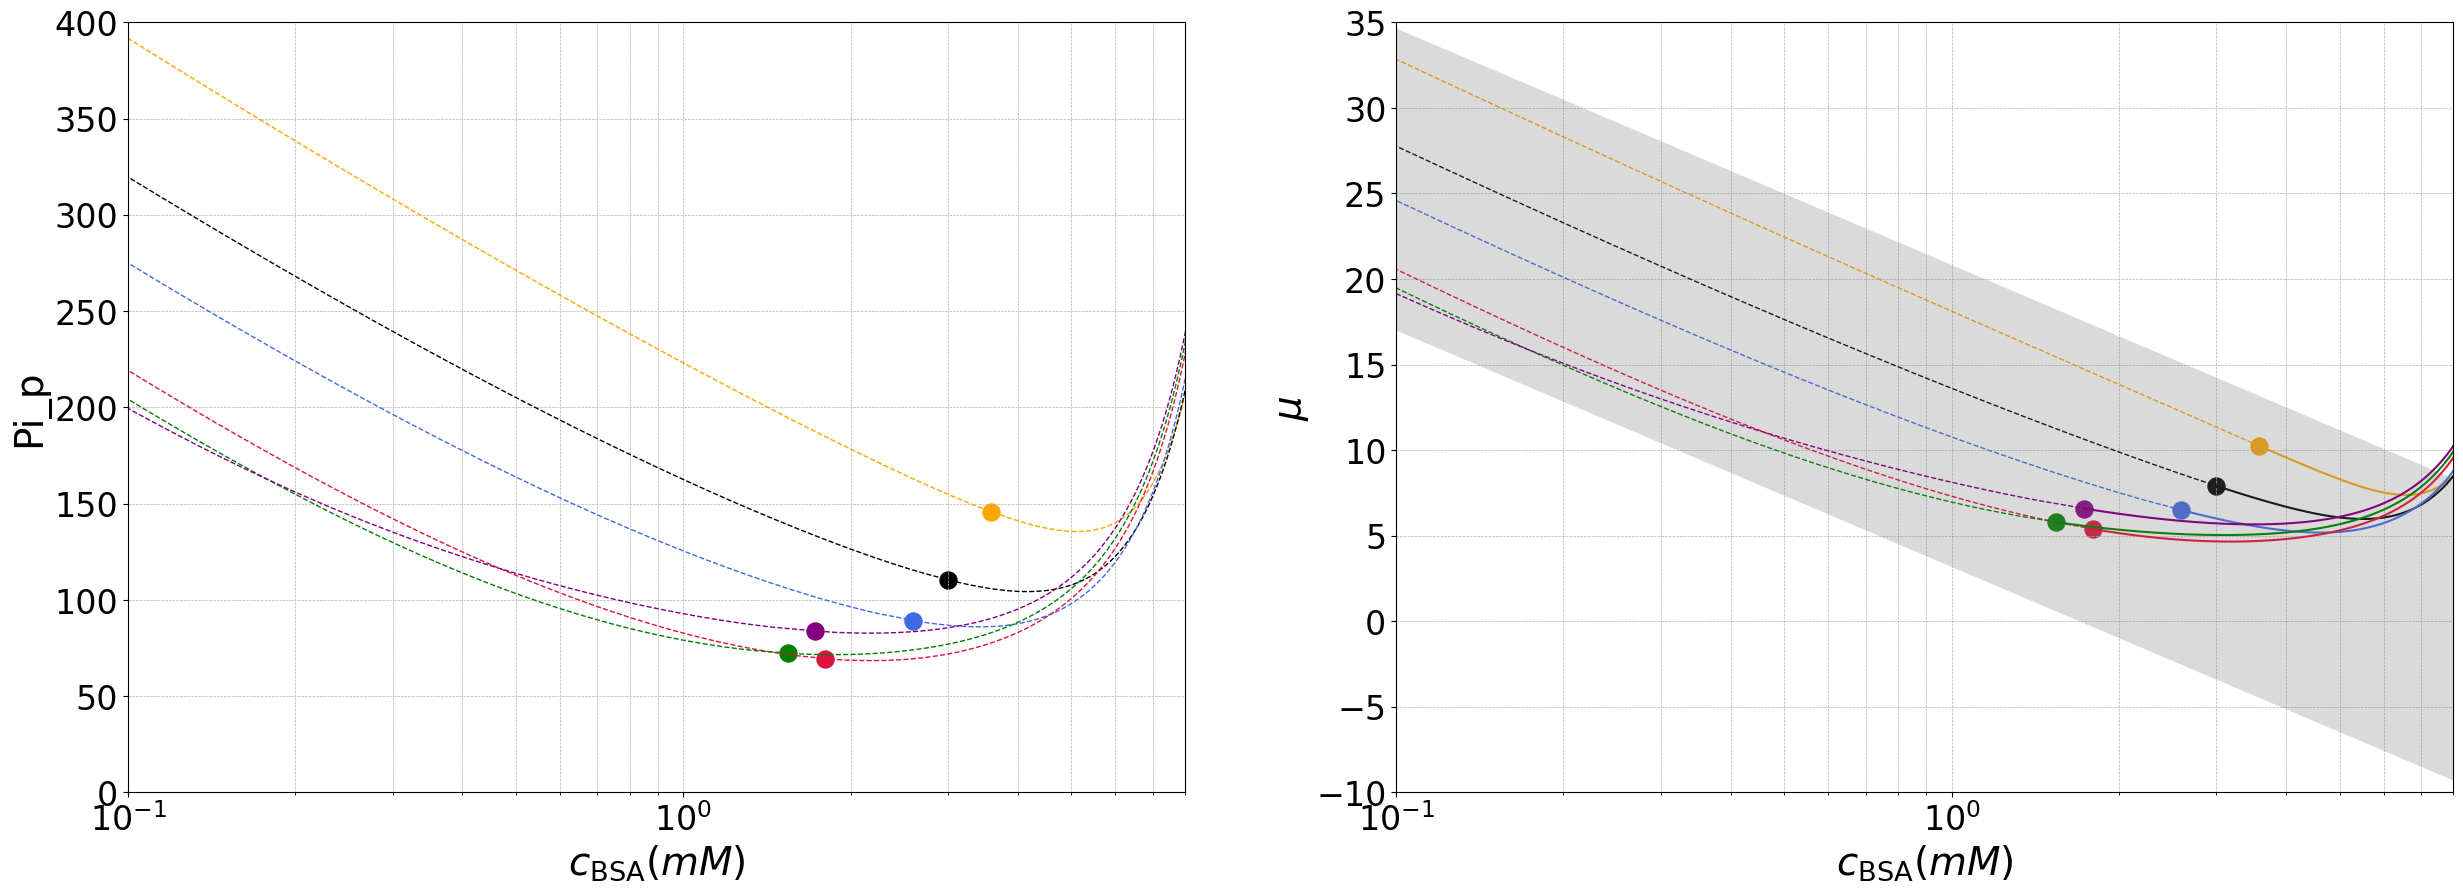

In [ ]:
# ax.semilogx(BSA_Sup, [phix_peg*(1.62*y**(3*gamma)) for y in phi_R], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)

# ax.scatter(BSA_Drop[-1], Pp_Drop[-1], color=pcolor, s=150, marker='o')

# ax.semilogx(BSA_Drop, [p for g,p in zip(g_Drop, Pp_Drop)], label='Droplet Total', color=pcolor, linewidth=2)
# ax.semilogx(BSA_Sup, [p for g,p in zip(g_Sup, Pp_Sup)], label='Droplet Total', color=pcolor, linewidth=2)

# ax.semilogx(BSA_Drop, [g*p for g,p in zip(g_Drop, Pp_Drop)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
# ax.semilogx(BSA_Sup, [g*p for g,p in zip(g_Sup, Pp_Sup)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')

# ax.plot(BSA_Sup, [1-phi*(1+qx)**3 for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(30, 10))

axes[0].set_xlim(0.1,8)
axes[0].set_ylim(0,400)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0].set_ylabel(r'Pi_p',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0.1,8)
axes[1].set_ylim(-10,35)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[1].set_ylabel(r'$\mu$',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

# BSA_PEG_4K_full.h_plot('orange', 'PEG 4K', axes[0])
# BSA_PEG_6K_full.h_plot('black', 'PEG 6K', axes[0])
# BSA_PEG_8K_full.h_plot('royalblue', 'PEG 8K', axes[0])
# BSA_PEG_20K_full.h_plot('crimson', 'PEG 20K', axes[0])
# BSA_PEG_35K_full.h_plot('green', 'PEG 35K', axes[0])
# BSA_PEG_100K_full.h_plot('purple', 'PEG 100K', axes[0])

BSA_PEG_4K_full.g_plot('orange', 'PEG 4K', axes[0])
BSA_PEG_6K_full.g_plot('black', 'PEG 6K', axes[0])
BSA_PEG_8K_full.g_plot('royalblue', 'PEG 8K', axes[0])
BSA_PEG_20K_full.g_plot('crimson', 'PEG 20K', axes[0])
BSA_PEG_35K_full.g_plot('green', 'PEG 35K', axes[0])
BSA_PEG_100K_full.g_plot('purple', 'PEG 100K', axes[0])

BSA_PEG_4K_full.mu_plot('orange', 'PEG 4K', axes[1], depletion=True, reference_band=True)
BSA_PEG_6K_full.mu_plot('black', 'PEG 6K', axes[1], depletion=True, reference_band=True)
BSA_PEG_8K_full.mu_plot('royalblue', 'PEG 8K', axes[1], depletion=True, reference_band=True)
BSA_PEG_20K_full.mu_plot('crimson', 'PEG 20K', axes[1], depletion=True, reference_band=True)
BSA_PEG_35K_full.mu_plot('green', 'PEG 35K', axes[1], depletion=True, reference_band=True)
BSA_PEG_100K_full.mu_plot('purple', 'PEG 100K', axes[1], depletion=True, reference_band=True)

# Fig. 4

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
/var/folders/jl/hhm7fywx471fm4g9gf4wkgy80000gq/T/ipykernel_6999/2034590785.py:3: SyntaxWarning: invalid escape sequence '\P'
  axes[0][0].set_title("$\Pi$ (mOsm/L)")
/var/folders/jl/hhm7fywx471fm4g9gf4wkgy80000gq/T/ipykernel_6999/2034590785.py:3: SyntaxWarning: invalid escape sequence '\P'
  axes[0][0].set_title("$\Pi$ (mOsm/L)")


AttributeError: 'PD' object has no attribute 'Pitot_plot'

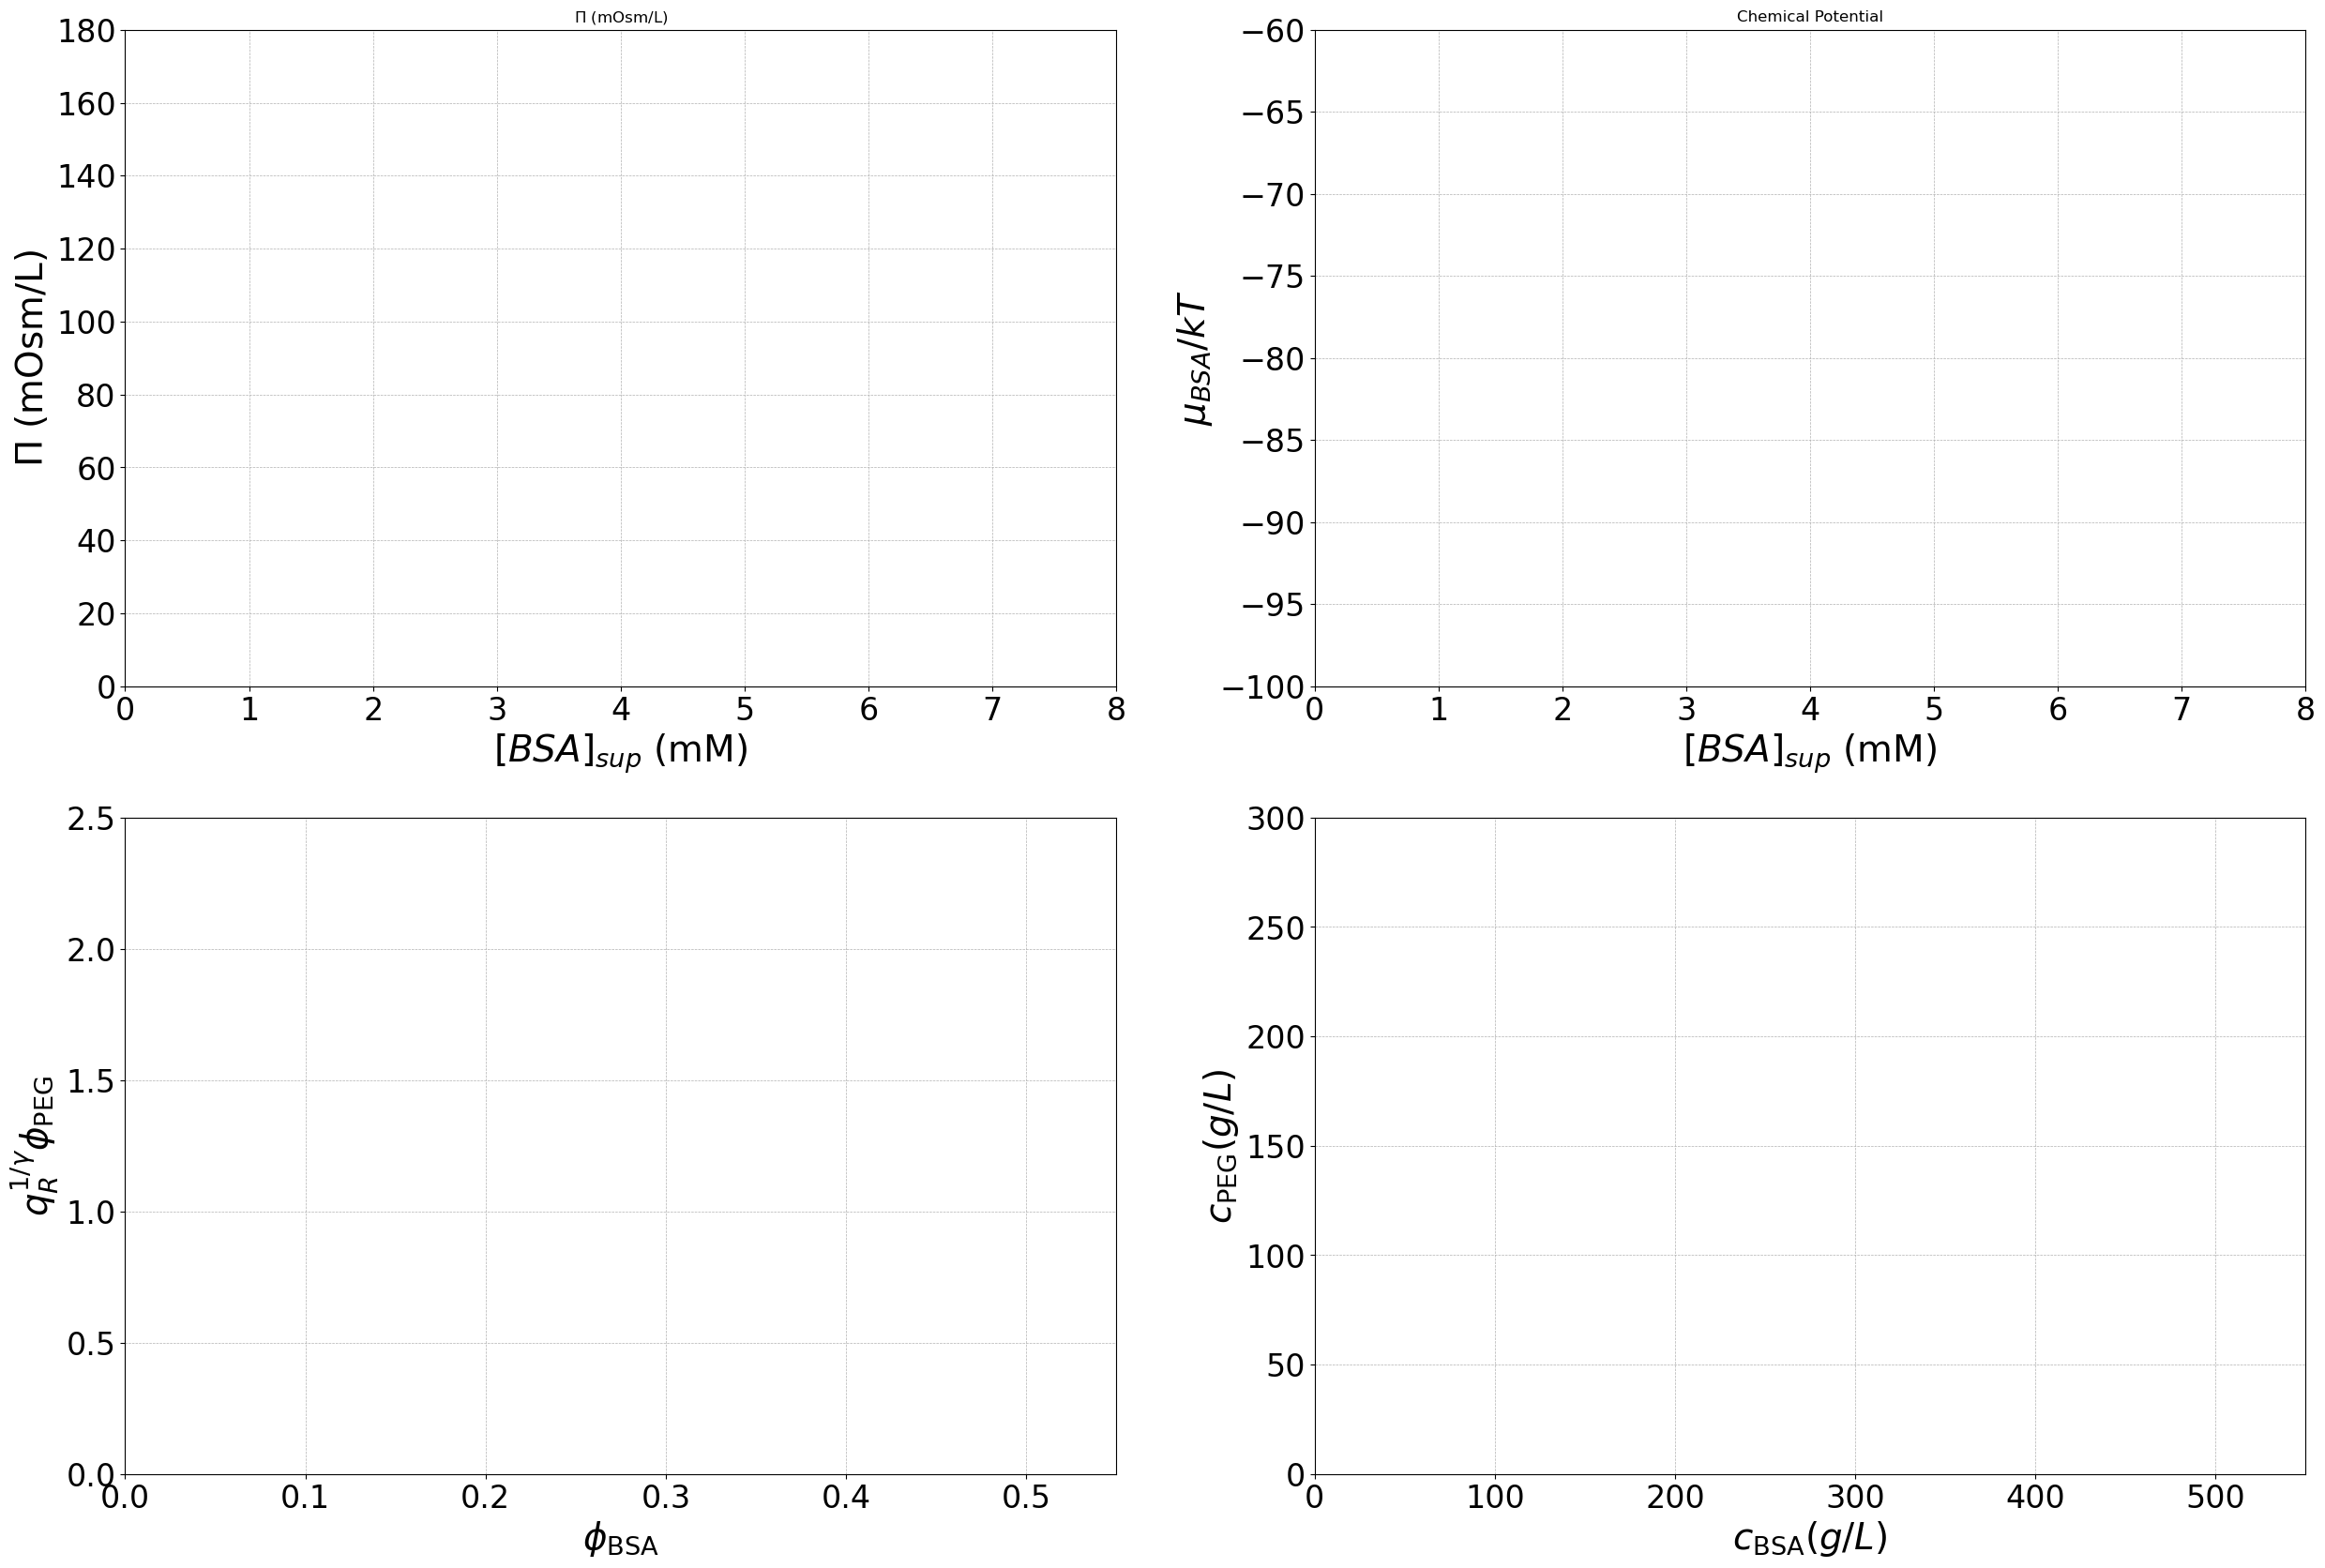

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(30, 20))

axes[0][0].set_title("$\Pi$ (mOsm/L)")
axes[0][0].set_xlim(0,8)
axes[0][0].set_ylim(0,180)
axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_xlabel(r'$[BSA]_{sup}$ (mM)',fontsize = 28)
axes[0][0].set_ylabel(r'$\Pi$ (mOsm/L)',fontsize = 28)
axes[0][0].grid(True, which='both', ls='--', lw=0.5)

axes[0][1].set_title("Chemical Potential")
axes[0][1].set_xlabel(r'$[BSA]_{sup}$ (mM)',fontsize = 28)
axes[0][1].set_ylabel(r'$\mu_{BSA}/kT$',fontsize = 28)
axes[0][1].set_xlim(0,8)
axes[0][1].set_ylim(-100,-60)
axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
# axes[0][1].axhline(0, color='black', linestyle='--', linewidth=1)
# axes[0][1].set_xscale('log')
# axes[0][1].legend(fontsize = 14)
axes[0][1].grid(True, which='both', ls='--', lw=0.5)

axes[1][0].set_xlim(0,0.55)
axes[1][0].set_ylim(0,2.5)
axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
axes[1][0].set_ylabel(r'$q_R^{1/\gamma}\phi_\mathrm{PEG}$',fontsize = 28)
axes[1][0].grid(True, which='both', ls='--', lw=0.5)

# axes[1][0].set_xlim(0,0.45)
# axes[1][0].set_ylim(0,2.1)
# axes[1][0].tick_params(axis='x', labelsize=24)
# axes[1][0].tick_params(axis='y', labelsize=24)
# axes[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
# axes[1][0].set_ylabel(r'$q_R^{1/\gamma}\phi_\mathrm{PEG}$',fontsize = 28)
# axes[1][0].grid(True, which='both', ls='--', lw=0.5)


plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
# plt.tight_layout()

axes[1][1].set_xlim(0,550)
axes[1][1].set_ylim(0,300)
axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][1].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][1].grid(True, which='both', ls='--', lw=0.5)

def Pitot_plot(gfvt_out, pcolor, plabel, ax=None, plim=500):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    Rpr_in, Rpol_in, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm'

    idx = np.abs(np.array(PEG_Sup) - plim).argmin()

    Rb = 8.314
    T = 273.15 + TC # temperature
    RT = Rb*T

    def inverse(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return 1000*x/Rb/T
    
    def forward(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return x*Rb*T/1000

    gamma = 0

    q=Rpol_in/Rpr_in
    # qq=q**-1/gamma
    qq=1

    ax.plot(BSA_Drop, Pi_Drop/RT, label='Droplet Total', color=pcolor)
    ax.plot(BSA_Drop[idx:], Pi_Drop[idx:]/RT, label='Droplet Total', color=pcolor, linewidth=10, alpha=0.6)
    ax.scatter(BSA_Drop[-1], Pi_Drop[-1]/RT, color=pcolor, marker='*', s=200)
    # ax.plot(BSA_Drop, (Pi_Drop-P0_Drop)/RT, label='Polymer', linestyle='--', color=pcolor)
    ax.plot(BSA_Drop, P0_Drop/RT, label='Droplet HS', linestyle='--', color=pcolor)

    ax.plot(BSA_Sup, Pi_Sup/RT, label='Supernatant Total', color=pcolor)
    # ax.plot(BSA_Sup, (Pi_Sup-P0_Sup)/RT, label='Polymer', linestyle='--', color=pcolor)
    ax.plot(BSA_Sup, P0_Sup/RT, label='Sup HS', linestyle='--', color=pcolor)
    ax.plot(BSA_Sup[idx:], Pi_Sup[idx:]/RT, label='Supernatant Total', color=pcolor, linewidth=10, alpha=0.6)

    secay = ax.secondary_yaxis('right', functions=(forward, inverse))
    secay.set_ylabel(r'$\Pi$ (kPa)', fontsize=28)
    secay.tick_params(axis='y', labelsize=24)

Pitot_plot('orange', 'PEG 4K', ax=axes[0][0], plim=60)
Pitot_plot(BSA_PEG_6K_full, 'black', 'PEG 6K', ax=axes[0][0], plim=40)
Pitot_plot(BSA_PEG_8K_full, 'royalblue', 'PEG 8K', ax=axes[0][0], plim=27)
Pitot_plot(BSA_PEG_20K_full, 'crimson', 'PEG 20K', ax=axes[0][0], plim=13)
Pitot_plot(BSA_PEG_35K_full, 'green', 'PEG 35K', ax=axes[0][0], plim=6.5)
Pitot_plot(BSA_PEG_100K_full, 'purple', 'PEG 100K', ax=axes[0][0], plim=2)
# Pitot_plot(gfvtQ10_200mM_Z0_full, 'gray', 'Q10', ax=axes[0][0])
# Pitot_plot(gfvtQ16_200mM_Z0_full, 'black', 'Q16', ax=axes[0][0])

BSA_PEG_4K_full.mu_plot('orange', 'PEG 4K', ax=axes[0][1], plim=60)
BSA_PEG_6K_full.mu_plot('black', 'PEG 6K', ax=axes[0][1], plim=40)
BSA_PEG_8K_full.mu_plot('royalblue', 'PEG 8K', ax=axes[0][1], plim=27)
BSA_PEG_20K_full.mu_plot('crimson', 'PEG 20K', ax=axes[0][1], plim=13)
BSA_PEG_35K_full.mu_plot('green', 'PEG 35K', ax=axes[0][1], plim=6.5)
BSA_PEG_100K_full.mu_plot('purple', 'PEG 100K', ax=axes[0][1], plim=2)
# BSA_PEG_Q10_full.mu_plot('gray', 'Q10', ax=axes[0][1])
# BSA_PEG_Q16_full.mu_plot('black', 'Q16', ax=axes[0][1])

BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4, ax=axes[1][0])
BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[1][0])
BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[1][0])
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20, ax=axes[1][0])
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[1][0])
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100, ax=axes[1][0])
BSA_PEG_4K_full.molplot_phi('4K, pH 7, 200 mM KCl, ', 'orange', ax=axes[1][0])
BSA_PEG_6K_full.molplot_phi('6K, pH 7, 200 mM KCl, ', 'black', ax=axes[1][0])
BSA_PEG_8K_full.molplot_phi('8K, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[1][0])
BSA_PEG_20K_full.molplot_phi('20K, pH 7, 200 mM KCl, ', 'crimson', ax=axes[1][0])
BSA_PEG_35K_full.molplot_phi('35K, pH 7, 200 mM KCl, ', 'green', ax=axes[1][0])
BSA_PEG_100K_full.molplot_phi('100K, pH 7, 200 mM KCl, ', 'purple', ax=axes[1][0])
BSA_PEG_8K_full.molplot_phi('Q=8, pH 7, 200 mM KCl, ', 'orange', ax=axes[1][0])
# BSA_PEG_Q10_full.molplot_phi('Q=10, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[1][0])
# BSA_PEG_Q16_full.molplot_phi('Q=16, pH 7, 200 mM KCl, ', 'magenta', ax=axes[1][0])
# BSA_PEG_Q16_GFP.molplot_phi('GFP, ', 'cyan', crit_color='black')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', ax=axes[1][1])
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][1])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', ax=axes[1][1])
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[1][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', ax=axes[1][1])
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', ax=axes[1][1])

BSA_PEG_4K_full.molplot('4K, pH 7, 200 mM KCl, ', 'orange', mbsa=mbsa, mpeg=mpeg4, ax=axes[1][1], mass=True, plim=60)
BSA_PEG_6K_full.molplot('6K, pH 7, 200 mM KCl, ', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[1][1], mass=True, plim=40)
BSA_PEG_8K_full.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[1][1], mass=True, plim=27)
BSA_PEG_20K_full.molplot('20K, pH 7, 200 mM KCl, ', 'crimson', mbsa=mbsa, mpeg=mpeg20, ax=axes[1][1], mass=True, plim=13)
BSA_PEG_35K_full.molplot('35K, pH 7, 200 mM KCl, ', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[1][1], mass=True, plim=6.5)
BSA_PEG_100K_full.molplot('100K, pH 7, 200 mM KCl, ', 'purple', mbsa=mbsa, mpeg=mpeg100, ax=axes[1][1], mass=True, plim=2)
# BSA_PEG_Q8_full.molplot('Q=8, pH 7, 200 mM KCl, ', 'orange', mbsa=mbsa, mpeg=mpegQ8, ax=axes[1][1], mass=True)
# BSA_PEG_Q10_full.molplot('Q=10, pH 7, 200 mM KCl, ', 'royalblue', mbsa=mbsa, mpeg=mpegQ10, ax=axes[1][1], mass=True)
# BSA_PEG_Q16_full.molplot('Q=16, pH 7, 200 mM KCl, ', 'magenta', mbsa=mbsa, mpeg=mpegQ16, ax=axes[1][1], mass=True)

# plt.yscale('log')

# plt.savefig('../output/'+date_string+'_Y_good_mOsmM_Fig04.png')
# plt.savefig('../output/'+date_string+'_Y_good_mOsM_Fig04.eps')

# Fig. 5

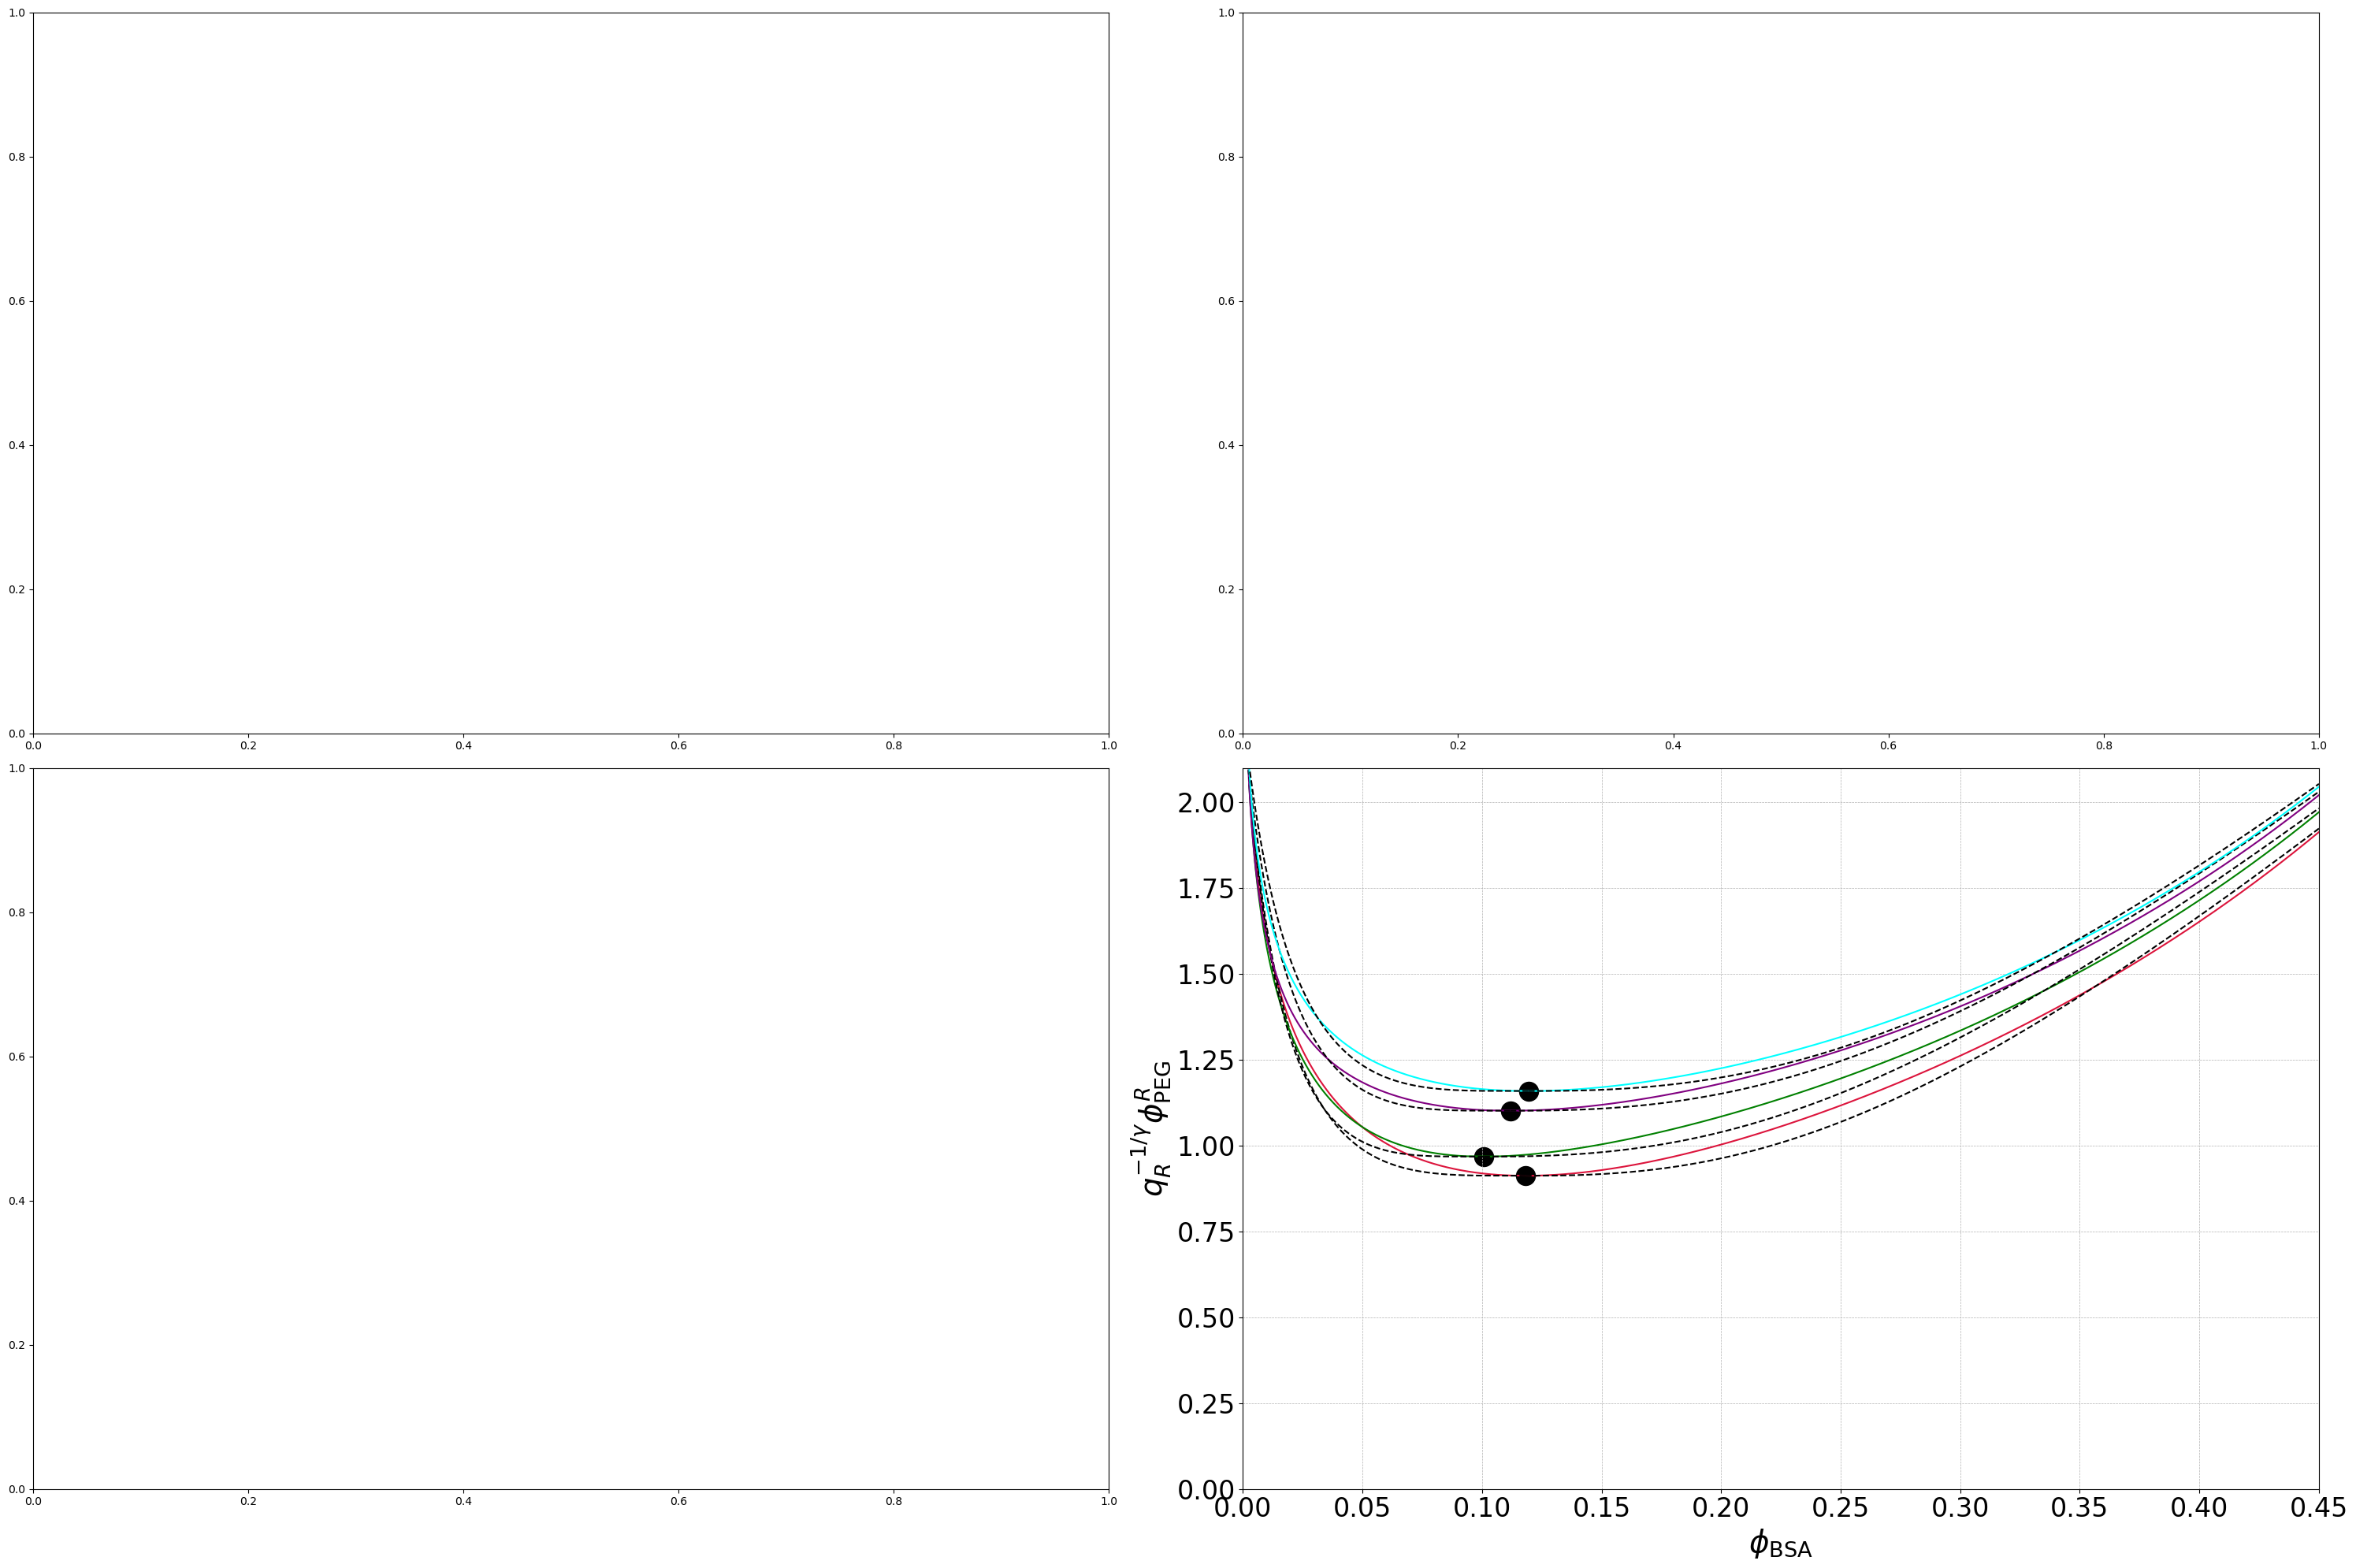

In [29]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
fig, axes = plt.subplots(2,2, figsize=(30, 20))
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.45)
plt.ylim(0,2.1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# molplot_phiR(gfvt4K_200mM_Z0_full, '4K, pH 7, 200 mM KCl, ', 'orange', crit_color='red')
# molplot_phiR(gfvt6K_200mM_Z0_full, '6K, pH 7, 200 mM KCl, ', 'black', crit_color='red')
# molplot_phiR(gfvt8K_200mM_Z0_full, '8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='red')
BSA_PEG_20K.molplot_phiR('20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='black')
BSA_PEG_35K.molplot_phiR('35K, pH 7, 200 mM KCl, ', 'green', crit_color='black')
BSA_PEG_100K.molplot_phiR('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')
# molplot_phiR(gfvtQ8_200mM_Z0_full, 'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
# molplot_phiR(gfvtQ10_200mM_Z0_full, 'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phiR('Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig('../output/'+date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

# GFP

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Axes: xlabel='$c_\\mathrm{protein} (g/L)$', ylabel='$c_\\mathrm{PEG} (g/L)$'>

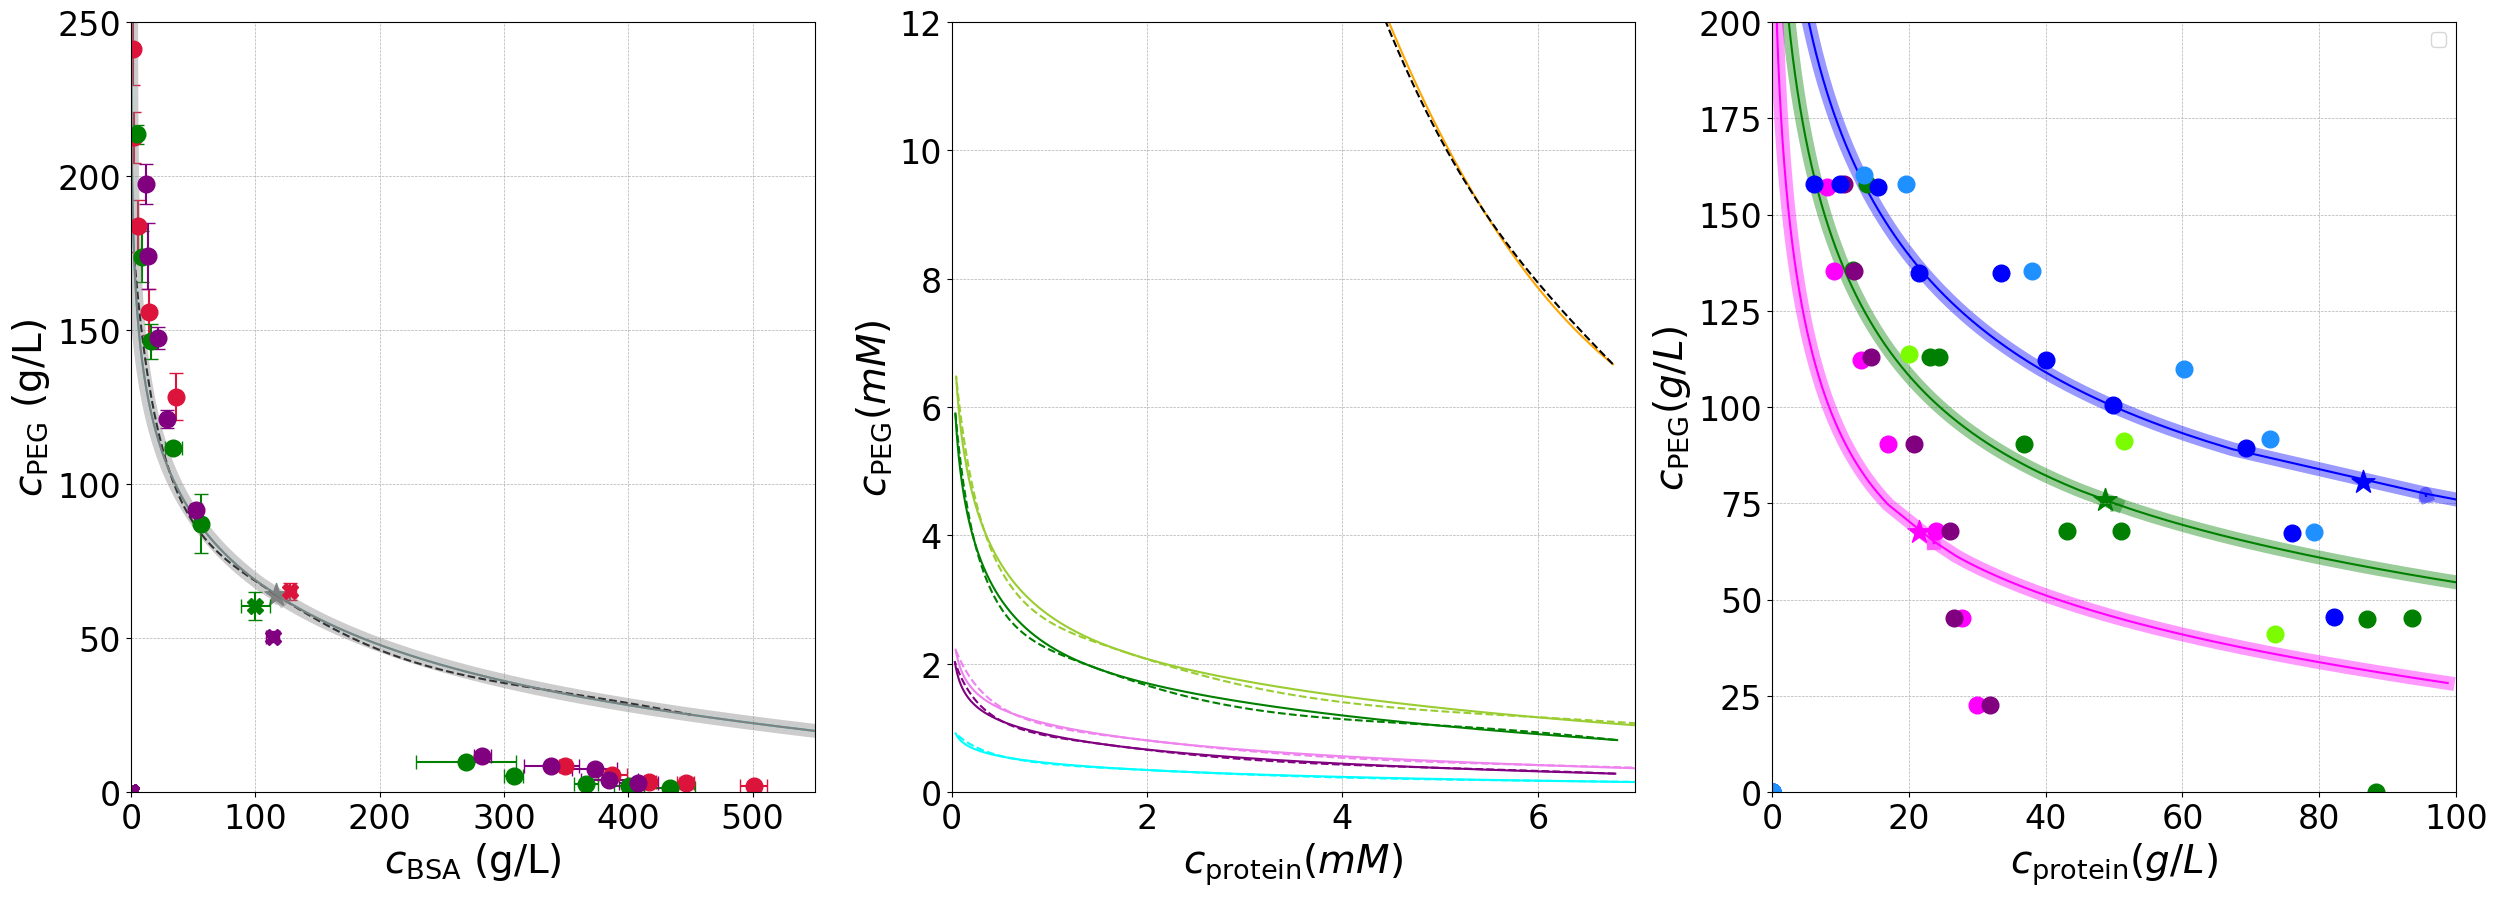

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(30, 10))

axes[0].set_xlim(0,550)
axes[0].set_ylim(0,250)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA}$ (g/L)',fontsize = 28)
axes[0].set_ylabel(r'$c_\mathrm{PEG}$ (g/L)',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,7)
axes[1].set_ylim(0,12)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{protein} (mM)$',fontsize = 28)
axes[1].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,100)
axes[2].set_ylim(0,200)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{protein} (g/L)$',fontsize = 28)
axes[2].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)
axes[2].legend(fontsize=14)

PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K', 'crimson', ax=axes[0])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K', 'green', ax=axes[0])
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K', 'purple', ax=axes[0])
BSA_PEG_Q16_full.molplot_analytical('Q=16, ', 'cyan', ax=axes[0], crit_color='black', mass=True)
BSA_PEG_Q16_full.molplot('Q=16, ', 'gray', ax=axes[0], crit_color='black', mass=True)

N_steps = 200 # number of points between PhiP_max and PhiP_min 
solvent = 'good'
guess_c = [0.24, 0.7];
# rgfp = 1.2e-9
rgfp = 2.8e-9
rsumo = 3e-9
rmbp = 2.7e-9

mgfp=28.9
msumo=14.5
mmbp=43

# guess_c = [0.1, 50]

# MBP_PEG_20K = PD(rmbp, rpeg20K, mmbp, mpeg20, solvent, N_steps, guess_c).GFVT()
# MBP_PEG_35K = PD(rmbp, rpeg35K, mmbp, mpeg35, solvent, N_steps, guess_c).GFVT()

# SUMO_PEG_20K = PD(rsumo, rpeg20K, msumo, mpeg20, solvent, N_steps, guess_c).GFVT()
# SUMO_PEG_35K = PD(rsumo, rpeg35K, msumo, mpeg35, solvent, N_steps, guess_c).GFVT()

# GFP_PEG_20K = PD(rgfp, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()
# GFP_PEG_35K = PD(rgfp, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()
# GFP_PEG_100K = PD(rgfp, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# GFP_PEG_Q16 = PD(rgfp, 25e-9, rpegQ16, mpegQ16, solvent, N_steps, guess_c).GFVT()

BSA_PEG_4K.molplot_analytical('BSA, 4K, ', 'orange', crit_color='black', ax=axes[1])
BSA_PEG_35K.molplot_analytical('BSA, 35K, ', 'green', crit_color='green', ax=axes[1])
BSA_PEG_100K.molplot_analytical('BSA, 100K, ', 'purple', crit_color='purple', ax=axes[1])
GFP_PEG_Q16.molplot_analytical('GFP, Q16, ', 'cyan', crit_color='cyan', ax=axes[1])

GFP_PEG_35K.molplot_analytical('GFP, 35K real, 2.8 nm', 'yellowgreen', crit_color='yellowgreen', ax=axes[1])
GFP_PEG_100K.molplot_analytical('GFP, 100K real, 2.8 nm ', 'violet', crit_color='violet', ax=axes[1])

GFP_PEG_35K.molplot('GFP, 35K, ', 'green', crit_color='green', ax=axes[2], mass=True)
SUMO_PEG_35K.molplot('SUMO, 35K, ', 'magenta', crit_color='lawngreen', ax=axes[2], mass=True)
MBP_PEG_35K.molplot('MBP, 35K, ', 'blue', crit_color='blue', ax=axes[2], mass=True)
# MBP_PEG_20K.molplot('MBP, 20K, ', 'dodgerblue', crit_color='dodgerblue', ax=axes[2], mass=True)
# SUMO_PEG_20K.molplot('SUMO, 20K, ', 'magenta', crit_color='magenta', ax=axes[2], mass=True)
# GFP_PEG_Q16.molplot_analytical('GFP, ', 'cyan', ax=axes[2], crit_color='cyan', mass=True)

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'green', ax=axes[2])
PD.molplot_dat_err_csv(data_20K_GFP, '20K GFP', 'lawngreen', ax=axes[2])

PD.molplot_dat_err_csv(data_35K_SUMO, '35K SUMO', 'magenta', ax=axes[2])
PD.molplot_dat_err_csv(data_20K_SUMO, '20K SUMO', 'purple', ax=axes[2])

PD.molplot_dat_err_csv(data_35K_MBP, '35K MBP', 'blue', ax=axes[2])
PD.molplot_dat_err_csv(data_20K_MBP, '20K MBP', 'dodgerblue', ax=axes[2], show_legend=True)

# plt.savefig('../output/'+date_string+'_analytical_good_Fig05_mass.png')
# plt.savefig('../output/'+date_string+'_analytical_good_Fig05_mass.eps')

/var/folders/jl/hhm7fywx471fm4g9gf4wkgy80000gq/T/ipykernel_90705/1615758524.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout(rect=(0, 0, 0.72, 1))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


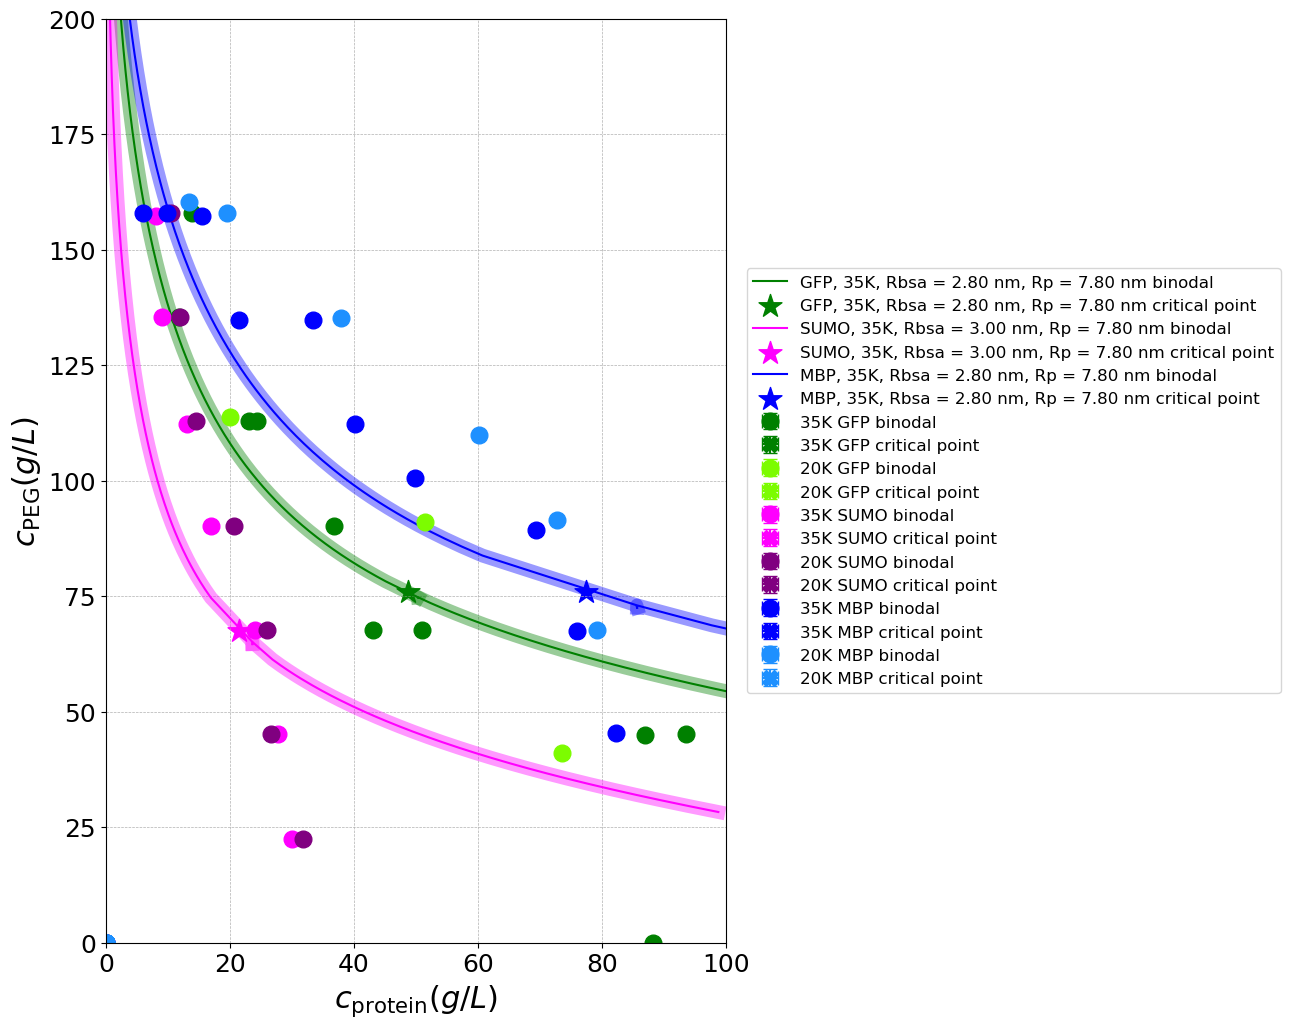

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(8, 12))

ax.set_xlim(0, 100)
ax.set_ylim(0, 200)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel(r'$c_\mathrm{protein} (g/L)$', fontsize=22)
ax.set_ylabel(r'$c_\mathrm{PEG} (g/L)$', fontsize=22)
ax.grid(True, which='both', ls='--', lw=0.5)

GFP_PEG_35K.molplot('GFP, 35K, ', 'green', crit_color='green', ax=ax, mass=True)
SUMO_PEG_35K.molplot('SUMO, 35K, ', 'magenta', crit_color='lawngreen', ax=ax, mass=True)
MBP_PEG_35K.molplot('MBP, 35K, ', 'blue', crit_color='blue', ax=ax, mass=True)

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'green', ax=ax)
PD.molplot_dat_err_csv(data_20K_GFP, '20K GFP', 'lawngreen', ax=ax)

PD.molplot_dat_err_csv(data_35K_SUMO, '35K SUMO', 'magenta', ax=ax)
PD.molplot_dat_err_csv(data_20K_SUMO, '20K SUMO', 'purple', ax=ax)

PD.molplot_dat_err_csv(data_35K_MBP, '35K MBP', 'blue', ax=ax)
PD.molplot_dat_err_csv(data_20K_MBP, '20K MBP', 'dodgerblue', ax=ax)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=12, frameon=True)
fig.tight_layout(rect=(0, 0, 0.72, 1))

plt.savefig('../output/'+date_string+'_proteins_mass.png')
plt.savefig('../output/'+date_string+'_proteins_mass.eps')

## Free Volume Fraction

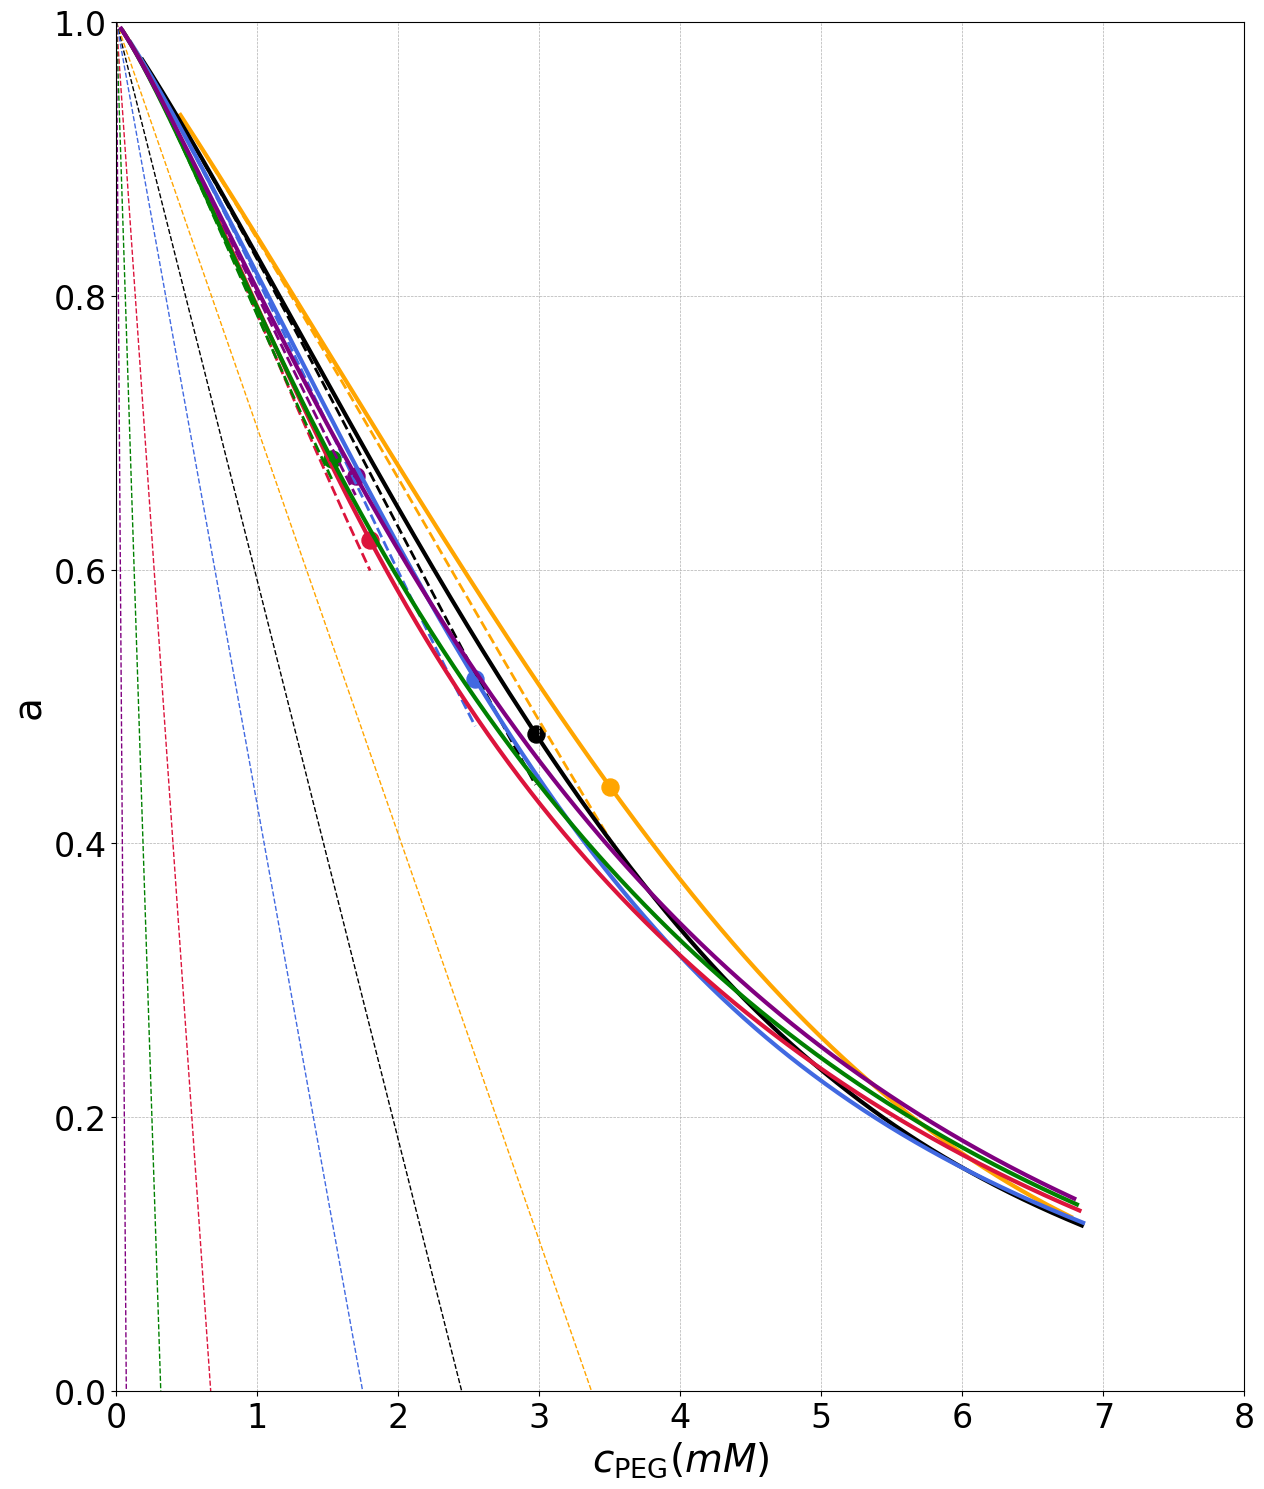

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

plt.xlim(0,8)
plt.ylim(0,1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.ylabel(r'a',fontsize = 28)
plt.tight_layout()

BSA_PEG_4K.a_plot('orange', 'PEG 4K')
BSA_PEG_6K.a_plot('black', 'PEG 6K')
BSA_PEG_8K.a_plot('royalblue', 'PEG 8K')
BSA_PEG_20K.a_plot('crimson', 'PEG 20K')
BSA_PEG_35K.a_plot('green', 'PEG 35K')
BSA_PEG_100K.a_plot('purple', 'PEG 100K')
# BSA_PEG_Q10.a_plot('magenta', 'Q10')
# BSA_PEG_Q16.a_plot('cyan', 'Q15')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')

# FVT, exclusion limit, Ingham Atha

## molplot_FVT()

In [ ]:
def molplot_FVT(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa_, mpeg_, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params

    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'
    
    if mbsa == 0 or mpeg == 0:
    
        b_bsa_A = BSA_Drop
        b_bsa_B = BSA_Sup
        b_PEG_A = PEG_Drop
        b_PEG_B = PEG_Sup
        
    else:
    
        b_bsa_A = BSA_Drop*mbsa
        b_bsa_B = BSA_Sup*mbsa
        b_PEG_A = PEG_Drop*mpeg
        b_PEG_B = PEG_Sup*mpeg
        
    plt.plot(b_bsa_A,b_PEG_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(b_bsa_B,b_PEG_B, '-', color = pcolor, ms = 2)
    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

## molplot_FVT_phi()

In [ ]:
def molplot_FVT_phi(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):

    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa_, mpeg_, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params
    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    a_fix, b_fix, c_fix =  abc(q)
    
    b_bsa_A = BSA_Drop/phix_bsa
    b_bsa_B = BSA_Sup/phix_bsa
    b_PEG_A = PEG_Drop/phix_peg
    b_PEG_B = PEG_Sup/phix_peg

    Q_BSA_A1 = [1/a for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    Q_BSA_B1 = [1/a for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    # Q_BSA_A = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    # Q_BSA_B = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    

    # c_BSA_A = [fBSA*((Rpol_in+Rpr_in))**3 for fPEG, fBSA, a in zip(PEG_Drop, BSA_Drop, a_Drop)]
    # c_BSA_B = [fBSA*((Rpol_in+Rpr_in))**3 for fPEG, fBSA, a in zip(PEG_Sup, BSA_Sup, a_Sup)]
    
    # c_PEG_A1 = [fPEG*Rpol_in**-3*(Rpol_in/Rpr_in)**2.41 for fPEG, fBSA, a, Q in zip(b_PEG_A, b_bsa_A, a_Drop,Q_BSA_A)]
    # c_PEG_B1 = [fPEG*Rpol_in**-3*(Rpol_in/Rpr_in)**2.41 for fPEG, fBSA, a, Q in zip(b_PEG_B, b_bsa_B, a_Sup,Q_BSA_B)]

    c_PEG_A1 = [fPEG*(Rpol_in/Rpr_in)**-0.57 for fPEG, fBSA, a in zip(b_PEG_A, b_bsa_A, a_Drop)]
    c_PEG_B1 = [fPEG*(Rpol_in/Rpr_in)**-0.57 for fPEG, fBSA, a in zip(b_PEG_B, b_bsa_B, a_Sup)]
    
    # c_PEG_A = [fPEG*(Rpol_in/Rpr_in)**2.28 for fPEG, fBSA, a, Q in zip(PEG_Drop, b_bsa_A, a_Drop,Q_BSA_A)]
    # c_PEG_B = [fPEG*(Rpol_in/Rpr_in)**2.28 for fPEG, fBSA, a, Q in zip(PEG_Sup, b_bsa_B, a_Sup,Q_BSA_B)]

    # a_BSA_A = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    # a_BSA_B = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    # plt.plot(BSA_Drop, phi_R*q**-0.33, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(BSA_Sup, phi_R*q**-0.33, '-', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A*((Rpol_in+Rpr_in)/Rpr_in)**3, c_PEG_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B*((Rpol_in+Rpr_in)/Rpr_in)**3, c_PEG_B, '-', color = pcolor, ms = 2)

    plt.plot(Q_BSA_A1, c_PEG_A1, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(Q_BSA_B1, c_PEG_B1, '-', color = pcolor, ms = 2)

    # plt.plot(Q_BSA_A, c_PEG_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(Q_BSA_B, c_PEG_B, '--', color = pcolor, ms = 2)


    # plt.plot(b_bsa_A, q**-0.33*phi_R, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B, q**-0.33*phi_R, '-', color = pcolor, ms = 2)

    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

## aplot_FVT()

NameError: name 'gfvt4K_200mM_Z0_FVT' is not defined

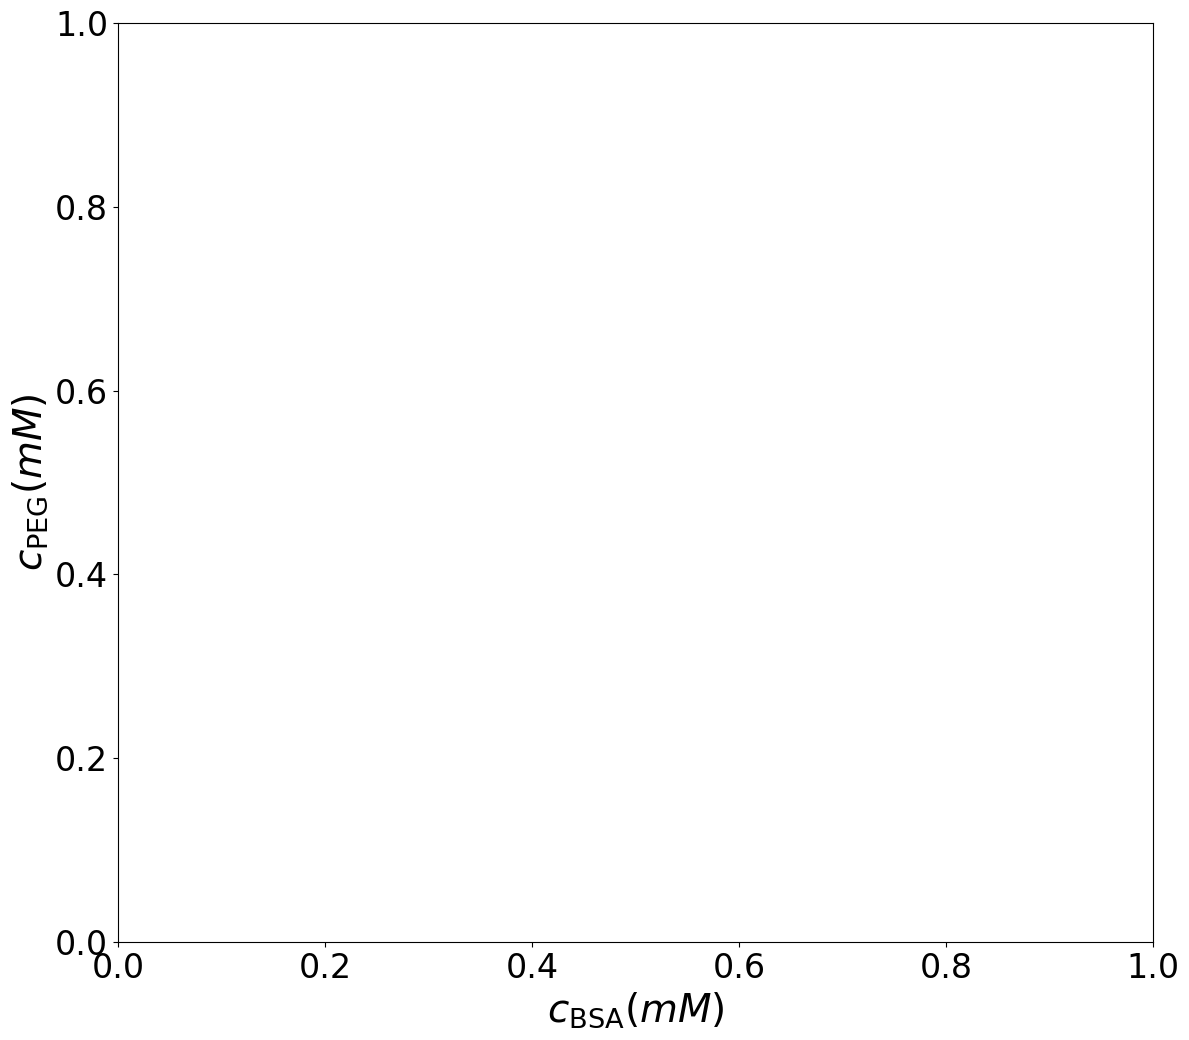

In [ ]:
def aplot_FVT(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):

    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params
    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    a_fix, b_fix, c_fix =  abc(q)
    
    b_bsa_A = BSA_Drop/phix_bsa
    b_bsa_B = BSA_Sup/phix_bsa
    b_PEG_A = PEG_Drop/phix_peg
    b_PEG_B = PEG_Sup/phix_peg

    a_BSA_A = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    a_BSA_B = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    Q_BSA_A = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    Q_BSA_B = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    
    c_BSA_A = [Phi*((Rpol_in+Rpr_in)/Rpr_in)**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    c_BSA_B = [Phi*((Rpol_in+Rpr_in)/Rpr_in)**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    
    c_PEG_A = [fPEG*((Rpol_in+Rpr_in))**6 for fPEG, fBSA, a, Q in zip(PEG_Drop, b_bsa_A, a_Drop,Q_BSA_A)]
    c_PEG_B = [fPEG*((Rpol_in+Rpr_in))**6 for fPEG, fBSA, a, Q in zip(PEG_Sup, b_bsa_B, a_Sup,Q_BSA_B)]
    
        
    # plt.plot(BSA_Drop, phi_R*q**-0.33, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(BSA_Sup, phi_R*q**-0.33, '-', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A*((Rpol_in+Rpr_in))**3, c_PEG_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B*((Rpol_in+Rpr_in))**3, c_PEG_B, '--', color = pcolor, ms = 2)

    plt.plot(BSA_Drop, Q_BSA_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(BSA_Sup, Q_BSA_B, '-', color = pcolor, ms = 2)

    plt.plot(BSA_Drop, c_BSA_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(BSA_Sup, c_BSA_B, '--', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A, q**-0.33*phi_R, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B, q**-0.33*phi_R, '-', color = pcolor, ms = 2)

    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,0.5)
# plt.ylim(0,1.6)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

aplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
aplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
aplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
aplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
aplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
aplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')

## EV_plot()

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def EV_plot(Rpr_in, Rpol_in, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    q = Rpol_in/Rpr_in;
    # q=0.6
    print(f'q={q}')
    ksi = 1 + q

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))*phix_bsa
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')*phix_peg
        # Phip[i] = P*phi_R

    plt.plot(Phig, Phip, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_Atha(Rpr_in, Rpol_in, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    q = Rpol_in/Rpr_in;
    # q=0.6
    print(f'q={q}')
    ksi = 1 + q

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))*phix_bsa
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')*phix_peg
        # Phip[i] = P*phi_R

    plt.semilogy(Phip, Phig, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_q(q, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    print(f'q={q}')
    ksi = 1 + q

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')
        # Phip[i] = P#*phi_R

    plt.plot(Phig, Phip, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_q_noHS(q, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    print(f'q={q}')
    ksi = 1 + q

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3)
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')
        # Phip[i] = P#*phi_R

    plt.plot(Phig, Phip, '-', color = pcolor, ms = 2)                                                           
                                             
    return

figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,0.17)
plt.ylim(0,3)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_{PEG}$',fontsize = 28)
plt.tight_layout()

EV_plot_q_noHS(0.55, 10, 1.5, 7, 'yellow')
EV_plot_q_noHS(0.67, 10, 1, 7, 'gray')
EV_plot_q_noHS(0.8, 10, 0.5, 7, 'cyan')
EV_plot_q_noHS(1.13, 10, 0.3, 7, 'red')
EV_plot_q_noHS(1.37, 10, 0.16, 7, 'aquamarine')
EV_plot_q_noHS(1.83, 10, 0.07, 7, 'magenta')

EV_plot_q(0.55, 10, 1.5, 7, 'orange')
EV_plot_q(0.67, 10, 1, 7, 'black')
EV_plot_q(0.8, 10, 0.5, 7, 'royalblue')
EV_plot_q(1.13, 10, 0.3, 7, 'crimson')
EV_plot_q(1.37, 10, 0.16, 7, 'green')
EV_plot_q(1.83, 10, 0.07, 7, 'purple')


## FVT()

## normal

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def FVT(Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b):

    g1, g2 = guess_b
    crit1, crit2 = guess_c

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    # q = Rpol_in/Rpr_in;

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    hp = 6.626e-34 #plank
    kb = 1.38e-23 #boltzmann
    Nav = 6.022e23 # avogadro
    Rb = 8.314
    TC = 22
    T = 273.15 + TC # temperature
    Lam = hp/(2*np.pi*mbsa*1000*kb*T/Nav)**(1/2) #de broglie wavelength

    q = Rpol_in/Rpr_in

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]
        
    # def Qs_fix(Phi, coeffs):

    #     y = Phi/(1 - Phi)
    
    #     a_fix, b_fix, c_fix = coeffs
        
    #     Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
    #     Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
    #     Q2_fix = 2*b_fix+6*c_fix*y
    #     Q3_fix = 6*c_fix

    #     return [Q_fix, Q1_fix, Q2_fix, Q3_fix]

    # def beta_fix(Qs):
    #     Q_fix, Q1_fix, Q2_fix, Q3_fix = Qs
        
    #     beta_fix = exp(-Q_fix)
    #     beta1_fix = -beta_fix*Q1_fix
    #     beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
    #     beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix

    #     return [beta_fix, beta1_fix, beta2_fix, beta3_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    def g_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs
        
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix

        return beta_fix - (1+y)*beta1_fix
        
    def h_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        
        return beta_fix - y*beta1_fix

    def h_fix1(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        
        return - y*beta2_fix

    def h_fix2(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        Q3_fix = 6*c_fix
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix
        
        return - beta2_fix - y*beta3_fix

    # Mu0 = np.log(Lam**3/vbsa)+ log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential
    # P0 = Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure
    
    def Mu0f(Phi, Lam, vc):
        return np.log(Lam**3/vc)+ np.log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential

    def P0f(Phi):
        y = Phi/(1 - Phi)
        return Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure


    def P0_1(Phi):
        y = Phi/(1 - Phi)
        return (1 + y)**-2 + 8*y + 6*y**2
        
    def P0_2(Phi):
        y = Phi/(1 - Phi)
        return -2*(1 + y)**-3 + 8 + 12*y
        

    #%% CHEMICAL POTENTIAL AND OSMOTIC PRESSURE
    # note this implementation is needed to solve numerically the nasty integral, impossible to solve analytically

    def Mu_fix(Phin, q):
        coeffs = abc(q)
        gf1 = g_fix(Phin[0], coeffs)
        gf2 = g_fix(Phin[1], coeffs)
        M01 = Mu0f(Phin[0], Lam, vbsa)
        M02 = Mu0f(Phin[1], Lam, vbsa)
        return (M01-M02)/(gf2-gf1)
    
    def Pi_fix(Phin, q):
        coeffs = abc(q)
        hf1 = h_fix(Phin[0], coeffs)
        hf2 = h_fix(Phin[1], coeffs)
        P01 = P0f(Phin[0])
        P02 = P0f(Phin[1])
        return (P01-P02)/(hf2-hf1)

    def Pi1_fix(Phin, q):
        hf1 = h_fix1(Phin[0], coeffs)
        P01 = P0_1(Phin[0])
        return P01 + hf1*Phin[1]*q**-3

    def Pi2_fix(Phin, q):
        hf2 = h_fix2(Phin[0], coeffs)
        P02 = P0_2(Phin[0])
        return P02 + hf2*Phin[1]*q**-3

    #%%  Phase diagram calculations

    # phix = (v2/6.022e23)/(4/3*np.pi*Rpol**3) #ratio between slvent free and hydrated molecular volumes 
    
    # PhiP = np.linspace(PhiP_min, PhiP_max, N_steps)
    
    Pr_Drop_fix = np.empty(N_steps)
    Pol_Drop_fix = np.empty(N_steps) 
    Pr_Sup_fix = np.empty(N_steps) 
    Pol_Sup_fix = np.empty(N_steps)
    Pr_Crit_fix_list = np.empty(N_steps)
    Pol_Crit_fix_list = np.empty(N_steps)
    Mu_listD_fix = np.empty(N_steps)
    Mu_listS_fix = np.empty(N_steps)
    Pi_listD_fix = np.empty(N_steps)
    Pi_listS_fix = np.empty(N_steps)
    Pp_list_fix = np.empty(N_steps)
    h_listD_fix = np.empty(N_steps)
    g_listD_fix = np.empty(N_steps)
    h_listS_fix = np.empty(N_steps)
    g_listS_fix = np.empty(N_steps)
    PhiR_list_fix = np.empty(N_steps)
    aPhiD_list_fix = np.empty(N_steps)
    aPhiS_list_fix = np.empty(N_steps)
    a_listD_fix = np.empty(N_steps)
    a_listS_fix = np.empty(N_steps)
    Mu0_listD_fix = np.empty(N_steps)
    Mu0_listS_fix = np.empty(N_steps)
    P0_Drop_fix = np.empty(N_steps)
    P0_Sup_fix = np.empty(N_steps)

    phi_R = np.empty(N_steps)

    coeffs = abc(q)

    def ffcrit(variabs, q):
        ffout1 = Pi1_fix(variabs, q)
        ffout2 = Pi2_fix(variabs, q)
        return [ffout1, ffout2]

    sol = root(ffcrit, (crit1, crit2), args=(q), method = 'hybr')

    print(sol.x)
    crit1_fix = float(sol.x[0])
    crit2_fix = float(sol.x[1])

    Pr_Crit_fix = crit1_fix*phix_bsa
    Pol_Crit_fix = float(alpha_fix(crit1_fix,q)*crit2_fix*phix_peg)

    print(f'BSA_crit = {crit1_fix:.4f}, PEG_crit = {crit2_fix:.4f}')
    print(f'[BSA_crit]fix = {Pr_Crit_fix:.2f} mM, [PEG_crit]fix = {Pol_Crit_fix:.2f} mM\n')

    Phic = np.linspace(0.0001,crit1_fix,N_steps)
    
    j=0

    for i in tqdm(np.flip(Phic), desc="Calculating FVT binodal", unit="step"):
        
        def ff(variabs):
            fout = Mu_fix([variabs, i], q)-Pi_fix([variabs, i], q)
            return float(fout)
        
        sol = brentq(ff, 1e-15, 1-1e-15)
        pol = Pi_fix([sol, i],q)*q**3

        Pr_Drop_fix[j] = sol*phix_bsa
        Pr_Sup_fix[j] = i*phix_bsa
        Pol_Drop_fix[j] = float(alpha_fix(sol,q)*pol*phix_peg) # volume fraction of pol in phase A
        Pol_Sup_fix[j] = float(alpha_fix(i,q)*pol*phix_peg) # volume fraction of pol in phase A
        a_listD_fix[j] = float(alpha_fix(sol,q))
        a_listS_fix[j] = float(alpha_fix(i,q))

        P0_Drop_fix[j] = P0f(sol)
        P0_Sup_fix[j] = P0f(i)
        Pi_listD_fix[j] = P0f(sol) + h_fix(sol, coeffs)*Pi_fix([sol, i], q)*phix_bsa*Rb*T
        Pi_listS_fix[j] = P0f(i) + h_fix(i, coeffs)*Pi_fix([sol, i], q)*phix_bsa*Rb*T
        Pp_list_fix[j] = Pi_fix([sol, i], q)*phix_bsa*Rb*T
        h_listD_fix[j] = h_fix(sol, coeffs)
        h_listS_fix[j] = h_fix(i, coeffs)

        Mu_listD_fix[j] = Mu0f(sol, Lam, vbsa) + g_fix(sol, coeffs)*Pi_fix([sol, i], q)    
        Mu_listS_fix[j] = Mu0f(i, Lam, vbsa) + g_fix(i, coeffs)*Pi_fix([sol, i], q)
        g_listD_fix[j] = g_fix(sol, coeffs)
        g_listS_fix[j] = g_fix(i, coeffs)
        PhiR_list_fix[j] = pol
        aPhiD_list_fix[j] = float(alpha_fix(sol,q)*pol)
        aPhiS_list_fix[j] = float(alpha_fix(i,q)*pol)
        Mu0_listD_fix[j] = Mu0f(sol, Lam, vbsa)
        Mu0_listS_fix[j] = Mu0f(i, Lam, vbsa)

        j +=1 
    
    #%%
    #molar concentration in mol/m^3 = mmol/L multiplied by molar volume in m^3/mol
    
    # Vmpr = (4/3*np.pi*Rpr**3*6.022e23)
    # Vmpol = v2

    # params = [Rpr_in, Rpol_in, mbsa, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    params = [Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg] #need mpeg
           
    return [PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params]

## exclusion limit

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def FVT_exclusion(Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b):

    g1, g2 = guess_b
    crit1, crit2 = guess_c

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    # q = Rpol_in/Rpr_in;

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    hp = 6.626e-34 #plank
    kb = 1.38e-23 #boltzmann
    Nav = 6.022e23 # avogadro
    Rb = 8.314
    TC = 22
    T = 273.15 + TC # temperature
    Lam = hp/(2*np.pi*mbsa*1000*kb*T/Nav)**(1/2) #de broglie wavelength

    q = Rpol_in/Rpr_in

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]
        
    # def Qs_fix(Phi, coeffs):

    #     y = Phi/(1 - Phi)
    
    #     a_fix, b_fix, c_fix = coeffs
        
    #     Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
    #     Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
    #     Q2_fix = 2*b_fix+6*c_fix*y
    #     Q3_fix = 6*c_fix

    #     return [Q_fix, Q1_fix, Q2_fix, Q3_fix]

    # def beta_fix(Qs):
    #     Q_fix, Q1_fix, Q2_fix, Q3_fix = Qs
        
    #     beta_fix = exp(-Q_fix)
    #     beta1_fix = -beta_fix*Q1_fix
    #     beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
    #     beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix

    #     return [beta_fix, beta1_fix, beta2_fix, beta3_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    def g_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs
        
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix

        return beta_fix - (1+y)*beta1_fix
        
    def h_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        
        return beta_fix - y*beta1_fix

    def h_fix1(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        
        return - y*beta2_fix

    def h_fix2(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        Q3_fix = 6*c_fix
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix
        
        return - beta2_fix - y*beta3_fix

    # Mu0 = np.log(Lam**3/vbsa)+ log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential
    # P0 = Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure
    
    def Mu0f(Phi, Lam, vc):
        return np.log(Lam**3/vc)+ np.log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential

    def P0f(Phi):
        y = Phi/(1 - Phi)
        return Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure


    def P0_1(Phi):
        y = Phi/(1 - Phi)
        return (1 + y)**-2 + 8*y + 6*y**2
        
    def P0_2(Phi):
        y = Phi/(1 - Phi)
        return -2*(1 + y)**-3 + 8 + 12*y
        

    #%% CHEMICAL POTENTIAL AND OSMOTIC PRESSURE
    # note this implementation is needed to solve numerically the nasty integral, impossible to solve analytically

    def Mu_fix(Phin, q):
        coeffs = abc(q)
        gf1 = 0
        gf2 = 1
        M01 = Mu0f(Phin[0], Lam, vbsa)
        M02 = Mu0f(Phin[1], Lam, vbsa)
        return (M01-M02)/(gf2-gf1)
    
    def Pi_fix(Phin,q):
        coeffs = abc(q)
        hf1 = 0
        hf2 = 1
        P01 = P0f(Phin[0])
        P02 = P0f(Phin[1])
        return (P01-P02)/(hf2-hf1)

    def Pi1_fix(Phin, q):
        hf1 = h_fix1(Phin[0], coeffs)
        P01 = P0_1(Phin[0])
        return P01 + hf1*Phin[1]*q**-3

    def Pi2_fix(Phin, q):
        hf2 = h_fix2(Phin[0], coeffs)
        P02 = P0_2(Phin[0])
        return P02 + hf2*Phin[1]*q**-3

    #%%  Phase diagram calculations

    # phix = (v2/6.022e23)/(4/3*np.pi*Rpol**3) #ratio between slvent free and hydrated molecular volumes 
    
    # PhiP = np.linspace(PhiP_min, PhiP_max, N_steps)
    
    Pr_Drop_fix = np.empty(N_steps)
    Pol_Drop_fix = np.empty(N_steps) 
    Pr_Sup_fix = np.empty(N_steps) 
    Pol_Sup_fix = np.empty(N_steps)
    Pr_Crit_fix_list = np.empty(N_steps)
    Pol_Crit_fix_list = np.empty(N_steps)
    Mu_listD_fix = np.empty(N_steps)
    Mu_listS_fix = np.empty(N_steps)
    Pi_listD_fix = np.empty(N_steps)
    Pi_listS_fix = np.empty(N_steps)
    Pp_list_fix = np.empty(N_steps)
    h_listD_fix = np.empty(N_steps)
    g_listD_fix = np.empty(N_steps)
    h_listS_fix = np.empty(N_steps)
    g_listS_fix = np.empty(N_steps)
    PhiR_list_fix = np.empty(N_steps)
    aPhiD_list_fix = np.empty(N_steps)
    aPhiS_list_fix = np.empty(N_steps)
    a_listD_fix = np.empty(N_steps)
    a_listS_fix = np.empty(N_steps)
    Mu0_listD_fix = np.empty(N_steps)
    Mu0_listS_fix = np.empty(N_steps)

    phi_R = np.empty(N_steps)

    coeffs = abc(q)

    def ffcrit(variabs, q):
        ffout1 = Pi1_fix(variabs, q)
        ffout2 = Pi2_fix(variabs, q)
        return [ffout1, ffout2]

    sol = root(ffcrit, (crit1, crit2), args=(q), method = 'hybr')

    print(sol.x)
    crit1_fix = float(sol.x[0])
    crit2_fix = float(sol.x[1])

    Pr_Crit_fix = crit1_fix*phix_bsa
    Pol_Crit_fix = float(alpha_fix(crit1_fix,q)*crit2_fix*phix_peg)

    print(f'BSA_crit = {crit1_fix:.4f}, PEG_crit = {crit2_fix:.4f}')
    print(f'[BSA_crit]fix = {Pr_Crit_fix:.2f} mM, [PEG_crit]fix = {Pol_Crit_fix:.2f} mM\n')

    Phic = np.linspace(crit1_fix,0.99999, N_steps)
    
    j=0

    for i in tqdm(np.flip(Phic), desc="Calculating FVT binodal", unit="step"):
        
        def ff(variabs):
            fout = Mu0f(i, Lam, vbsa)- Mu0f(variabs, Lam, vbsa)-P0f(i)
            return float(fout)
        
        sol = brentq(ff, 1e-15, 1-1e-15)
        pol = P0f(i)*q**3

        Pr_Drop_fix[j] = sol*phix_bsa
        Pr_Sup_fix[j] = i*phix_bsa
        Pol_Drop_fix[j] = float(alpha_fix(sol,q)*pol*phix_peg) # volume fraction of pol in phase A
        Pol_Sup_fix[j] = float(alpha_fix(i,q)*pol*phix_peg) # volume fraction of pol in phase A
        a_listD_fix[j] = float(alpha_fix(sol,q))
        a_listS_fix[j] = float(alpha_fix(i,q))
       
        Pi_listD_fix[j] = P0f(sol) + 0*phix_bsa*Rb*T
        Pi_listS_fix[j] = P0f(i) + 1*phix_bsa*Rb*T
        Pp_list_fix[j] = Pi_fix([sol, i], q)*phix_bsa*Rb*T
        h_listD_fix[j] = 0
        h_listS_fix[j] = 1

        Mu_listD_fix[j] = Mu0f(sol, Lam, vbsa) + g_fix(sol, coeffs)*Pi_fix([sol, i], q)    
        Mu_listS_fix[j] = Mu0f(i, Lam, vbsa) + g_fix(i, coeffs)*Pi_fix([sol, i], q)
        g_listD_fix[j] = g_fix(sol, coeffs)
        g_listS_fix[j] = g_fix(i, coeffs)
        PhiR_list_fix[j] = pol
        aPhiD_list_fix[j] = float(alpha_fix(sol,q)*pol)
        aPhiS_list_fix[j] = float(alpha_fix(i,q)*pol)
        Mu0_listD_fix[j] = Mu0f(sol, Lam, vbsa)
        Mu0_listS_fix[j] = Mu0f(i, Lam, vbsa)

        j +=1 
    
    #%%
    #molar concentration in mol/m^3 = mmol/L multiplied by molar volume in m^3/mol
    
    # Vmpr = (4/3*np.pi*Rpr**3*6.022e23)
    # Vmpol = v2

    params = [Rpr_in, Rpol_in, mbsa, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    
    return [PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, params]

#### Calculate

## FVT

## compare FVT and GFVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(1e-2,60)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')

molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')

molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')

molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')

molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')

molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# molplot_FVT(gfvt100K_200mM_Z0_FVT_ex, f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# plt.yscale('log')

## molplot_FVT_phi

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,8)
# plt.ylim(0.01,10)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 1000 # number of points between PhiP_max and PhiP_min 
PhiP_max = 200# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.01 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]

# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvtQ10_200mM_Z0_FVT = FVT(3.0e-9, 10e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT_phi(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT_phi(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT_phi(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT_phi(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT_phi(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT_phi(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')
# molplot_FVT_phi(gfvtQ10_200mM_Z0_FVT, f'FVT Q10, pH 7, 200 mM KCl, ', 'red', 'red')

plt.xscale('log')
# plt.yscale('log')

# molplot_FVT(gfvt100K_200mM_Z0_FVT_ex, f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

## Excluded Volume Limit FVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.2)
plt.ylim(1e-2,2)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT_phi(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT_phi(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT_phi(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT_phi(gfvt20K_200mM_Z0_FVT, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT_phi(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT_phi(gfvt100K_200mM_Z0_FVT, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

EV_plot_q(0.55, 10, 1.5, 7, 'orange')
EV_plot_q(0.67, 10, 1, 7, 'black')
EV_plot_q(0.8, 10, 0.5, 7, 'royalblue')
EV_plot_q(1.13, 10, 0.3, 7, 'crimson')
EV_plot_q(1.37, 10, 0.16, 7, 'green')
EV_plot_q(1.83, 10, 0.07, 7, 'purple')

# plt.yscale('log')

## PLOT compare GFVT and FVT (mM)

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(1e-2,60)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT(gfvt35K_200mM_Z0_FVT, f'FVT 35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# EV_plot(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
# EV_plot(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
# EV_plot(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
# EV_plot(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
# EV_plot(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
# EV_plot(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## PLOT compare GFVT and FVT (g/L)

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,550)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

# molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', mbsa, mpeg4)
# molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', mbsa, mpeg6)
# molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', mbsa, mpeg8)
# molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', mbsa, mpeg20)
# molplot_FVT(gfvt35K_200mM_Z0_FVT, f'FVT 35K, pH 7, 200 mM KCl, ', 'green', mbsa, mpeg35)
molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', mbsa, mpeg100)

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red', mass=True)
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red', mass=True)
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red', mass=True)
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red', mass=True)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red', mass=True)
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red', mass=True)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', False)

# EV_plot(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
# EV_plot(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
# EV_plot(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
# EV_plot(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
# EV_plot(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
# EV_plot(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## Ingham Atha

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,60)
plt.ylim(1e-2,1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

# molplot_FVT(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
# molplot_FVT(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
# molplot_FVT(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
# molplot_FVT(gfvt20K_200mM_Z0_FVT, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
# molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
# molplot_FVT(gfvt100K_200mM_Z0_FVT, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
# molplot(gfvt6K_200mM_Z0, f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

EV_plot_Atha(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
EV_plot_Atha(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
EV_plot_Atha(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
EV_plot_Atha(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
EV_plot_Atha(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
EV_plot_Atha(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## FVT_a()

In [ ]:
def FVT_a(fvt, ax, plabel, pcolor):
    PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, params = fvt

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];

    q = rpeg/rbsa;

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + ' FVT binodal'
    print(full_label)
    
    ax[0][0].plot(Pr_Drop_fix, a_listD_fix, color = pcolor, linewidth=3)
    ax[0][0].plot(Pr_Sup_fix, a_listS_fix, color = pcolor, linewidth=3)

    ax[0][0].tick_params(axis='x', labelsize=24)
    ax[0][0].tick_params(axis='y', labelsize=24)
    ax[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
    ax[0][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[0][1].plot(Pol_Drop_fix, a_listD_fix, color = pcolor, linewidth=3)
    ax[0][1].plot(Pol_Sup_fix, a_listS_fix, color = pcolor, linewidth=3)

    ax[0][1].tick_params(axis='x', labelsize=24)
    ax[0][1].tick_params(axis='y', labelsize=24)
    ax[0][1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
    ax[0][1].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][0].plot(Pr_Drop_fix/phixbsa, a_listD_fix, color = pcolor, linewidth=3)
    ax[1][0].plot(Pr_Sup_fix/phixbsa, a_listS_fix, color = pcolor, linewidth=3)

    ax[1][0].tick_params(axis='x', labelsize=24)
    ax[1][0].tick_params(axis='y', labelsize=24)
    ax[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
    ax[1][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][1].plot(Pol_Drop_fix/phixpeg, a_listD_fix, color = pcolor, linewidth=3)
    ax[1][1].plot(Pol_Sup_fix/phixpeg, a_listS_fix, color = pcolor, linewidth=3)

    ax[1][1].tick_params(axis='x', labelsize=24)
    ax[1][1].tick_params(axis='y', labelsize=24)
    ax[1][1].set_xlabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
    ax[1][1].set_ylabel(r'$\alpha$',fontsize = 28)
    
    plt.legend(loc=(1.1,0),fontsize='x-large')

def GFVT_a(gfvt_out, ax, plabel, pcolor):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop, dPidPhiP_Drop_p, qx_Sup, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0]*1e9;
    rpeg = params[1]*1e9;

    q = rpeg/rbsa;

    full_label = plabel + f'Rbsa = {rbsa:.2f} nm, Rpol = {rpeg:.2f} nm, q = {q:.2f}, ' + ' GFVT binodal'
    print(full_label)
    
    # ax[0][0].plot(BSA_Drop, [a*rbsa**3/(rbsa*(1+qx))**3 for cpeg, a, qx in zip(PEG_Drop, a_Drop, qx_Drop)],  '--', color = pcolor, linewidth=3)
    # ax[0][0].plot(BSA_Sup, [a/(rbsa*(1+qx))**3 for cpeg, a, qx in zip(PEG_Sup, a_Sup, qx_Sup)],  '--', color = pcolor, linewidth=3)

    ax[0][0].plot(BSA_Drop, [cpeg/phixpeg*cbsa/phixbsa for cbsa, cpeg, a, qx in zip(BSA_Drop, PEG_Drop, a_Drop, qx_Drop)],  '--', color = pcolor, linewidth=3)
    ax[0][0].plot(BSA_Sup, [cpeg/phixpeg*cbsa/phixbsa for cbsa, cpeg, a, qx in zip(BSA_Sup, PEG_Sup, a_Sup, qx_Sup)],  '--', color = pcolor, linewidth=3)

    ax[0][0].tick_params(axis='x', labelsize=24)
    ax[0][0].tick_params(axis='y', labelsize=24)
    ax[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
    ax[0][0].set_ylabel(r'$\alpha$',fontsize = 28)
    # ax[0][0].set_xlim(1e-3,10)
    # ax[0][0].set_ylim(1e-1,1)

    ax[0][1].plot(PEG_Drop, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[0][1].plot(PEG_Sup, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[0][1].tick_params(axis='x', labelsize=24)
    ax[0][1].tick_params(axis='y', labelsize=24)
    ax[0][1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
    ax[0][1].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][0].plot(BSA_Drop/phixbsa, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[1][0].plot(BSA_Sup/phixbsa, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[1][0].tick_params(axis='x', labelsize=24)
    ax[1][0].tick_params(axis='y', labelsize=24)
    ax[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
    ax[1][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][1].plot(PEG_Drop/phixpeg, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[1][1].plot(PEG_Sup/phixpeg, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[1][1].tick_params(axis='x', labelsize=24)
    ax[1][1].tick_params(axis='y', labelsize=24)
    ax[1][1].set_xlabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
    ax[1][1].set_ylabel(r'$\alpha$',fontsize = 28)
    
    plt.legend(loc=(1.1,0),fontsize='x-large')

fig, axes = plt.subplots(2, 2, figsize=(30, 24))
# FVT_a(gfvt4K_200mM_Z0_FVT, axes, f'4K, pH 7, 200 mM KCl, ', 'orange')
GFVT_a(gfvt4K_200mM_Z0, axes, f'4K, pH 7, 200 mM KCl, ', 'orange')
# FVT_a(gfvt6K_200mM_Z0_FVT, axes, f'6K, pH 7, 200 mM KCl, ', 'black')
GFVT_a(gfvt6K_200mM_Z0, axes, f'6K, pH 7, 200 mM KCl, ', 'black')
# FVT_a(gfvt8K_200mM_Z0_FVT, axes, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
GFVT_a(gfvt8K_200mM_Z0, axes, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
# FVT_a(gfvt20K_200mM_Z0_FVT, axes, f'20K, pH 7, 200 mM KCl, ', 'crimson')
GFVT_a(gfvt20K_200mM_Z0, axes, f'20K, pH 7, 200 mM KCl, ', 'crimson')
# FVT_a(gfvt35K_200mM_Z0_FVT, axes, f'35K, pH 7, 200 mM KCl, ', 'green')
GFVT_a(gfvt35K_200mM_Z0, axes, f'35K, pH 7, 200 mM KCl, ', 'green')
# FVT_a(gfvt100K_200mM_Z0_FVT, axes, f'100K, pH 7, 200 mM KCl, ', 'purple')
GFVT_a(gfvt100K_200mM_Z0, axes, f'100K, pH 7, 200 mM KCl, ', 'purple')

axes[0][0].set_yscale('log')
axes[0][0].set_xscale('log')

## exclusion limit

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.3 # guess protein volume fraction in phase B
N_steps = 500 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.39 # 
solvent = 'good'

guess_b = [g1, g2];
guess_c = [0.24, 0.7];
guess_b = [1e-12, 0.8];
# guess_b = [0.0004, 0.54];
PhiP_max = 1.2#3 Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt4K_200mM_Z0 = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 2 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
guess_b = [1e-4, 0.5];
# gfvt4K_200mM_Z0 = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 3.0 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
guess_b = [1e-4, 0.5];
# gfvt8K_200mM_Z0 = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_b = [1e-4, 0.5];
# gfvt20K_200mM_Z0 = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 10# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_b = [1e-4, 0.6];
# gfvt35K_200mM_Z0 = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 24# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
# g1 = 1e-8 # guess protein volume fraction in phase A
# g2 = 1 # guess protein volume fraction in phase B
# guess_b = [1e-4, 0.5];

# gfvt100K_200mM_Z0 = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'blue', mbsa, mpeg6, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW,'2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa,  8.57, False)

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

# EV_plot(3.0e-9, 7.8e-9, 100, 2, 7, 'green')
# EV_plot(3.0e-9, 7.8e-9, 100, 1e-5, 7, 'green')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')

# plt.yscale('log')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

## SIM Jungbauer

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (10,9))  #width x height, aspect ratio 0.85 (0.87)

plt.xlim(0,30)
plt.ylim(1e0,1e3)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\mathrm{PEG \%(w/v)}$',fontsize = 28)
plt.ylabel(r'$\log c_\mathrm{BSA}$',fontsize = 28)
plt.tight_layout()

def logy(gfvt_out, mbsa, mpeg, fitrange, pcolor, plabel):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    params = gfvt_out[-1];
    rbsa = params[0]*1e9;
    rpeg = params[1]*1e9;
    q = rpeg/rbsa;

    # print(rpeg)
    
    k1 = 24*np.pi/np.log(10)
    beta = k1*rpeg**2/(mpeg*1000)*rbsa

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];
    solvent = params[3];

    PEGrange = np.linspace(0,50,100)
    PEGrange_lim = np.linspace(fitrange[0],fitrange[1],100)

    cPEG = np.asarray([c_PEG*mpeg/10 for c_PEG in PEG_Sup])
    S = np.asarray([c_BSA*mbsa for c_BSA in BSA_Sup])
    lgS = np.asarray([np.log(s) for s in S])
    
    cPEG_lim = [c for c, s in zip(cPEG, lgS) if fitrange[0] < c < fitrange[1]]
    lgS_lim = [s for c, s in zip(cPEG, lgS) if fitrange[0] < c < fitrange[1]]
        
    # Perform linear fit
    logfit_S,residuals,_,_,_ = np.polyfit(cPEG_lim, lgS_lim, 1,full=True)  # Degree 1 polynomial (linear fit)
    slope_S, intercept_S = logfit_S
    print(f"Beta: {slope_S:.2f}, Intercept: {intercept_S:.2f}")
    print(f"Beta Theory: {beta:.2f}")

    lgS_fit =  [np.exp(intercept_S+x*slope_S) for x in PEGrange]
    lgS_fit_lim =  [np.exp(intercept_S+x*slope_S) for x in PEGrange_lim]
    # lgrp_PEG =  [intercept_rg_lin + x*slope_rg_lin for x in mwrange]
    
    plt.semilogy(cPEG, S, label='Sup', color=pcolor)
    # plt.semilogy(cPEG, [10**(-beta*c_PEG*mpeg/10+2) for c_PEG in PEG_Sup], linestyle='--', label='Sup', color=pcolor)
    plt.semilogy(PEGrange, lgS_fit, linestyle='--', label='Sup', color=pcolor)
    plt.semilogy(PEGrange_lim, lgS_fit_lim, linestyle='--', label='Sup', color='red')


def logS_plot_dat(data, plabel, pcolor):
    
    BN_BSA_sup = data[:,2]
    BN_BSA_sup_err = data[:,3]

    BN_PEG_sup = data[:,8]/10
    BN_PEG_sup_err = data[:,9]/10
    
    # Plot with adjusted cap thickness
    # plt.errorbar(BN_PEG_sup, BN_BSA_sup, yerr=BN_PEG_sup_err, xerr=BN_BSA_sup_err, markersize=12,fmt='o', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' binodal')
    plt.scatter(BN_PEG_sup, BN_BSA_sup, s=250, c=pcolor, label=plabel + ' binodal')
    plt.yscale('log')
    # plt.semilogy(BN_PEG_sup, BN_BSA_sup, markersize=12,fmt='o', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' binodal')

logy(gfvt4K_200mM_Z0.to_legacy_list(), mbsa, mpeg4, [15, 25], 'orange', 'PEG 4K')
logy(gfvt6K_200mM_Z0, mbsa, mpeg6, [15, 25], 'black', 'PEG 6K')
logy(gfvt8K_200mM_Z0, mbsa, mpeg8, [12, 22], 'royalblue', 'PEG 8K')
logy(gfvt20K_200mM_Z0, mbsa, mpeg20, [8, 25], 'crimson', 'PEG 20K')
logy(gfvt35K_200mM_Z0, mbsa, mpeg35, [8, 25], 'green', 'PEG 35K')
logy(gfvt100K_200mM_Z0, mbsa, mpeg100, [8, 25], 'purple', 'PEG 100K')

logS_plot_dat(data_4K_pH7_200mM_MA3, f'4K, pH 7, 200 mM KCl, ', 'orange')
logS_plot_dat(data_6K_pH7_200mM_SD, f'6K, pH 7, 200 mM KCl, ', 'black')
logS_plot_dat(data_8K_pH7_200mM_SD, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
logS_plot_dat(data_20K_pH7_200mM, f'20K, pH 7, 200 mM KCl, ', 'crimson')
logS_plot_dat(data_35K_pH7_200mM, f'35K, pH 7, 200 mM KCl, ', 'green')
logS_plot_dat(data_100K_pH7_200mM, f'100K, pH 7, 200 mM KCl, ', 'purple')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')